In [1]:
%matplotlib inline
!pip install seaborn shap dice-ml fairlearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')
 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
# DATA LOADING
# ============================================================================
print("=" * 70)
print("LOADING UCI ADULT DATASET")
print("=" * 70)
 
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income'
]
 
try:
    train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
    test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"
    df_train = pd.read_csv(train_url, names=column_names, skipinitialspace=True, na_values='?')
    df_test = pd.read_csv(test_url, names=column_names, skipinitialspace=True, skiprows=1, na_values='?')
    df = pd.concat([df_train, df_test], ignore_index=True)
    print("Loaded from UCI repository")
except:
    df = pd.read_csv("adult.csv", na_values='?')
    print("Loaded from local file")
 
df = df.dropna().reset_index(drop=True)

# Save protected attributes BEFORE encoding
protected_race = df['race'].copy()
protected_sex = df['sex'].copy()
 
# Encode target
df['income'] = df['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)
 
# Encode categorical features
categorical_cols = df.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
 
# Split
feature_cols = [c for c in df.columns if c != 'income']
X = df[feature_cols]
y = df['income']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
 
# Align protected attributes with test set
race_test = protected_race.iloc[X_test.index].reset_index(drop=True)
sex_test = protected_sex.iloc[X_test.index].reset_index(drop=True)
 
print(f"Training: {X_train.shape[0]} | Test: {X_test.shape[0]}")
 
# Train the model
print("\nTraining Random Forest classifier...")
model = RandomForestClassifier(
    n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
)
model.fit(X_train, y_train)
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]
 
print(f"Overall accuracy: {accuracy_score(y_test, preds):.4f}")
print(f"Overall AUC-ROC: {roc_auc_score(y_test, probs):.4f}")

LOADING UCI ADULT DATASET
Loaded from UCI repository
Training: 31655 | Test: 13567

Training Random Forest classifier...
Overall accuracy: 0.8579
Overall AUC-ROC: 0.9165



PHASE 1: IS SOMETHING WRONG OVERALL?

Question: Are certain groups being approved/denied at different rates?

--- RACE ---
             Group     N  Base Rate  Selection Rate  Accuracy    TPR    FPR
Amer-Indian-Eskimo   146     0.0959          0.0890    0.9247 0.5714 0.0379
Asian-Pac-Islander   389     0.2725          0.2237    0.8329 0.6038 0.0813
             Black  1253     0.1221          0.0710    0.9218 0.4706 0.0155
             Other    99     0.1515          0.0808    0.9091 0.4667 0.0119
             White 11680     0.2632          0.1999    0.8506 0.5960 0.0584

  Disparate Impact Ratio: 0.3174  ← BELOW 0.8 THRESHOLD (potential discrimination)
  TPR gap: 0.1371 (0 = perfectly equal)
  FPR gap: 0.0694 (0 = perfectly equal)

--- SEX ---
 Group    N  Base Rate  Selection Rate  Accuracy    TPR    FPR
Female 4390     0.1162          0.0761    0.9280 0.5176 0.0180
  Male 9177     0.3108          0.2395    0.8243 0.6027 0.0757

  Disparate Impact Ratio: 0.3177  ← BELOW 0.8 THRESHO

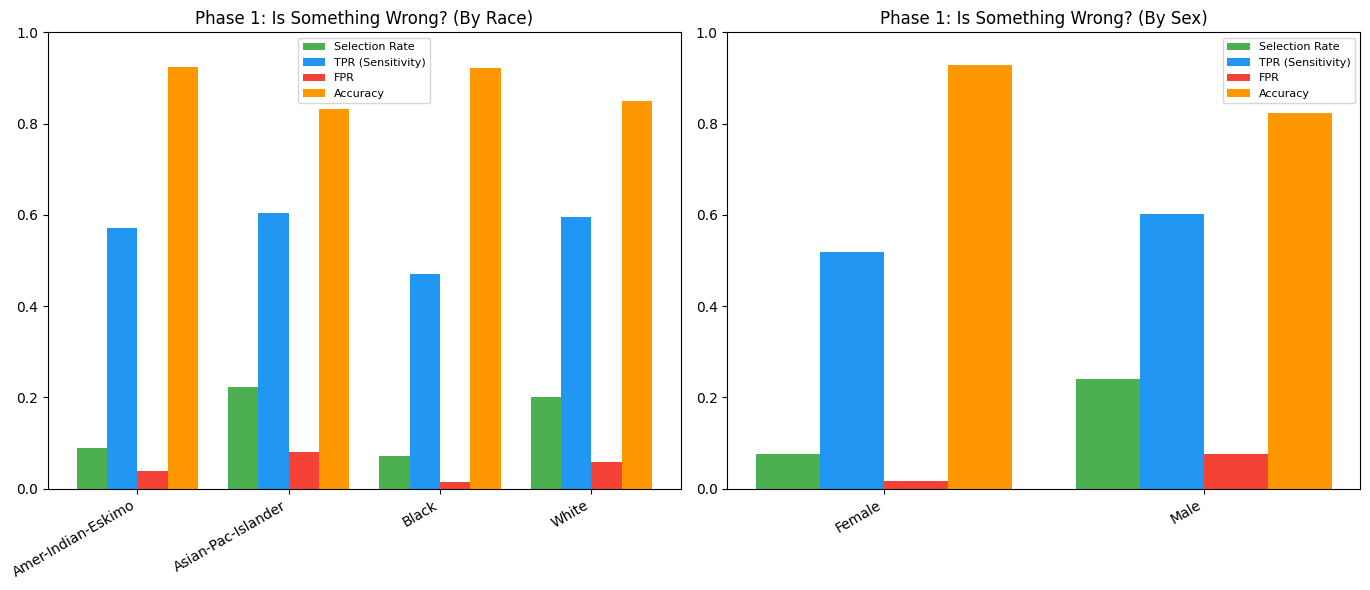

Saved: phase1_fairness_audit.png


In [3]:
#phase1


print("\n" + "=" * 70)
print("PHASE 1: IS SOMETHING WRONG OVERALL?")
print("=" * 70)
 
def phase1_fairness_audit(y_true, y_pred, group_labels, group_name):
    """
    For each demographic group, compute:
    - Selection rate: what % of this group does the model predict as >$50K?
    - TPR (True Positive Rate): of people who truly earn >$50K, how many
      does the model correctly identify?
    - FPR (False Positive Rate): of people who truly earn ≤$50K, how many
      does the model incorrectly flag as >$50K?
    - Accuracy: overall correctness for this group
 
    If these numbers differ across groups, the model is treating
    people differently based on group membership.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    results = []
    for group in sorted(group_labels.unique()):
        mask = (group_labels == group).values
        if mask.sum() < 50:
            continue
 
        yt = y_true[mask]
        yp = y_pred[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
 
        results.append({
            'Group': group,
            'N': int(mask.sum()),
            'Base Rate': round(yt.mean(), 4),
            'Selection Rate': round(yp.mean(), 4),
            'Accuracy': round((tp + tn) / (tp + tn + fp + fn), 4),
            'TPR': round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
            'FPR': round(fp / (fp + tn), 4) if (fp + tn) > 0 else 0,
        })
 
    results_df = pd.DataFrame(results)
    print(f"\n--- {group_name} ---")
    print(results_df.to_string(index=False))
 
    # Disparate Impact: ratio of lowest to highest selection rate
    # Below 0.8 = legally suspect (80% rule)
    sel_rates = [r['Selection Rate'] for r in results if r['Selection Rate'] > 0]
    if len(sel_rates) >= 2:
        di = min(sel_rates) / max(sel_rates)
        print(f"\n  Disparate Impact Ratio: {di:.4f}", end="")
        if di < 0.8:
            print("  ← BELOW 0.8 THRESHOLD (potential discrimination)")
        else:
            print("  ← Above 0.8 threshold")
 
    # Equalized Odds gap
    tprs = [r['TPR'] for r in results]
    fprs = [r['FPR'] for r in results]
    print(f"  TPR gap: {max(tprs) - min(tprs):.4f} (0 = perfectly equal)")
    print(f"  FPR gap: {max(fprs) - min(fprs):.4f} (0 = perfectly equal)")
 
    return results_df
 
y_test_arr = y_test.reset_index(drop=True)
 
print("\nQuestion: Are certain groups being approved/denied at different rates?")
race_results = phase1_fairness_audit(y_test_arr, preds, race_test, "RACE")
sex_results = phase1_fairness_audit(y_test_arr, preds, sex_test, "SEX")
 
print("\n" + "-" * 50)
print("PHASE 1 VERDICT:")
print("-" * 50)
print("""
Look at the numbers above. If you see:
  - Women have a LOWER selection rate than men → the model approves
    women less often
  - Black applicants have a LOWER TPR than White applicants → the model
    misses qualified Black applicants more often
  - Any Disparate Impact below 0.8 → legally suspect discrimination
 
This tells us: YES, something is wrong. The model treats groups unequally.
Now we need to ask WHY.
""")
 
# --- PHASE 1 FIGURE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
for ax, results_df, title in [
    (axes[0], race_results[race_results['N'] > 100], "By Race"),
    (axes[1], sex_results, "By Sex")
]:
    x = np.arange(len(results_df))
    w = 0.2
    ax.bar(x - w*1.5, results_df['Selection Rate'], w, label='Selection Rate', color='#4CAF50')
    ax.bar(x - w*0.5, results_df['TPR'], w, label='TPR (Sensitivity)', color='#2196F3')
    ax.bar(x + w*0.5, results_df['FPR'], w, label='FPR', color='#F44336')
    ax.bar(x + w*1.5, results_df['Accuracy'], w, label='Accuracy', color='#FF9800')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Group'], rotation=30, ha='right')
    ax.set_title(f'Phase 1: Is Something Wrong? ({title})')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
 
plt.tight_layout()
plt.savefig('phase1_fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase1_fairness_audit.png")



PHASE 2: WHY DID THIS SPECIFIC DECISION HAPPEN?

--- Step 2A: SHAP Explanations ---
Computing SHAP values (this may take a minute)...
SHAP values shape: (500, 14, 2)
Expected: (500, 14)

Global feature importance (what the model relies on most):
       Feature  Mean |SHAP|
  relationship     0.083009
 education_num     0.067960
marital_status     0.056297
  capital_gain     0.046226
           age     0.045926
hours_per_week     0.030171
    occupation     0.019047
  capital_loss     0.017092
           sex     0.015536
     education     0.015348
        fnlwgt     0.006283
     workclass     0.005790
          race     0.002194
native_country     0.001886

--------------------------------------------------
KEY QUESTION: Does SHAP reveal the bias or hide it?
--------------------------------------------------

Ranking of protected & proxy features in SHAP importance:
  #13  race                  SHAP=0.0022  ← PROTECTED (directly protected attribute)
  # 9  sex                   SHAP=

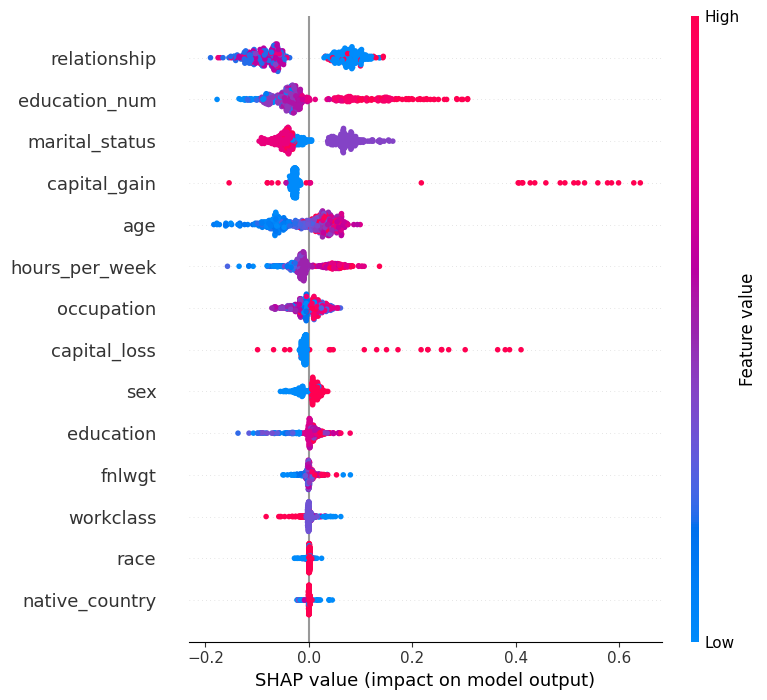

Saved: phase2_shap_summary.png

--- Step 2B: Do explanations differ by demographic group? ---

Average SHAP contribution of top features, split by SEX:
(Positive SHAP = pushes toward >$50K approval)
(Negative SHAP = pushes toward ≤$50K denial)
  relationship         | Male     | avg SHAP = +0.0037
  relationship         | Female   | avg SHAP = -0.0571

  education_num        | Male     | avg SHAP = +0.0016
  education_num        | Female   | avg SHAP = +0.0000

  marital_status       | Male     | avg SHAP = +0.0184
  marital_status       | Female   | avg SHAP = -0.0124

  capital_gain         | Male     | avg SHAP = -0.0022
  capital_gain         | Female   | avg SHAP = -0.0230

  age                  | Male     | avg SHAP = -0.0019
  age                  | Female   | avg SHAP = -0.0121

  hours_per_week       | Male     | avg SHAP = +0.0030
  hours_per_week       | Female   | avg SHAP = -0.0095


INTERPRETATION:
  If a feature like 'relationship' has a POSITIVE average SHAP for men
  

100%|██████████| 1/1 [00:00<00:00,  5.06it/s]


Person (White, Female) — currently DENIED:
  Original: age=24, education_num=9, hours/wk=37
  To get approved, change: hours_per_week: 37 → 78, capital_gain: 0 → 80794
  To get approved, change: hours_per_week: 37 → 39, capital_gain: 0 → 71524



100%|██████████| 1/1 [00:00<00:00,  5.05it/s]


Person (White, Male) — currently DENIED:
  Original: age=41, education_num=10, hours/wk=35
  To get approved, change: age: 41 → 89, capital_gain: 0 → 78154
  To get approved, change: education_num: 10 → 11, capital_gain: 0 → 73699



100%|██████████| 1/1 [00:00<00:00,  5.31it/s]


Person (White, Male) — currently DENIED:
  Original: age=37, education_num=12, hours/wk=46
  To get approved, change: capital_gain: 0 → 91771
  To get approved, change: age: 37 → 43



100%|██████████| 1/1 [00:00<00:00,  5.34it/s]


Person (White, Male) — currently DENIED:
  Original: age=36, education_num=9, hours/wk=40
  To get approved, change: hours_per_week: 40 → 18, capital_gain: 0 → 45819
  To get approved, change: hours_per_week: 40 → 18, capital_gain: 0 → 35619

--------------------------------------------------
COUNTERFACTUAL ANALYSIS:
--------------------------------------------------

KEY QUESTIONS TO ANSWER:
 
1. Do men and women get DIFFERENT counterfactual paths?
   If a man needs +2 years education but a woman needs +5 years
   education AND a career change — the model demands more from
   women to reach the same outcome.
 
2. Are the changes REALISTIC?
   "Increase capital gains by $50,000" is not actionable advice.
   It's the model telling you to be wealthier — which is circular.
 
3. Do counterfactuals implicitly suggest CHANGING IDENTITY?
   We excluded race and sex from allowed changes. But if the model
   suggests changing 'occupation' from a female-dominated field to
   a male-dominated one

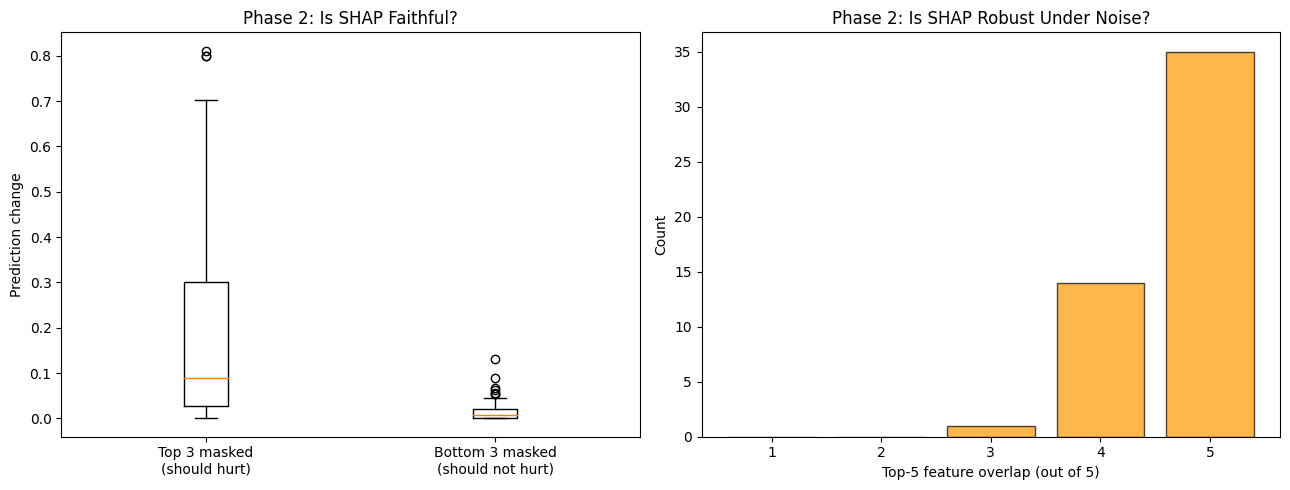


Saved: phase2_faithfulness_robustness.png


In [8]:
#phase 2

print("\n" + "=" * 70)
print("PHASE 2: WHY DID THIS SPECIFIC DECISION HAPPEN?")
print("=" * 70)
 
import shap
 
# --- STEP 2A: SHAP EXPLANATIONS ---
print("\n--- Step 2A: SHAP Explanations ---")
print("Computing SHAP values (this may take a minute)...")
 
explainer = shap.TreeExplainer(model)
sample_size = min(500, X_test.shape[0])
X_sample = X_test.iloc[:sample_size]
shap_values = explainer.shap_values(X_sample)
 
# For binary classification, index [1] = class "approved" (>50K)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# Fix shape if needed
print(f"SHAP values shape: {shap_vals.shape}")
print(f"Expected: ({sample_size}, {len(feature_cols)})")

if shap_vals.ndim == 3:
    # Some SHAP versions return (n_samples, n_features, n_classes)
    shap_vals = shap_vals[:, :, 1]  # take class 1 (>50K)
 
# Global importance: what features does the model rely on OVERALL?
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)
 
print("\nGlobal feature importance (what the model relies on most):")
print(importance_df.to_string(index=False))
 
# --- THE KEY QUESTION: Where do protected features rank? ---
print("\n" + "-" * 50)
print("KEY QUESTION: Does SHAP reveal the bias or hide it?")
print("-" * 50)
 
protected_and_proxy = {
    'race': 'PROTECTED (directly protected attribute)',
    'sex': 'PROTECTED (directly protected attribute)',
    'marital_status': 'PROXY (correlates with sex — married women often coded differently)',
    'relationship': 'PROXY (husband/wife categories encode sex)',
    'native_country': 'PROXY (correlates with race)',
}
 
print("\nRanking of protected & proxy features in SHAP importance:")
for feat, description in protected_and_proxy.items():
    if feat in feature_cols:
        idx = feature_cols.index(feat)
        importance = mean_abs_shap[idx]
        rank = int((mean_abs_shap > importance).sum() + 1)
        print(f"  #{rank:2d}  {feat:20s}  SHAP={importance:.4f}  ← {description}")
 
print("""
INTERPRETATION:
  If 'race' and 'sex' rank LOW but 'marital_status' and 'relationship'
  rank HIGH — SHAP is technically correct but practically MISLEADING.
 
  Why? Because 'relationship' contains categories like 'Husband' and
  'Wife' which are DIRECT encodings of sex. 'Marital_status' correlates
  heavily with sex due to historical patterns. So the model IS using
  sex — just through proxies that SHAP dutifully reports without
  flagging them as proxies.
 
  A user seeing "relationship was the #1 factor" would NOT realize
  the model is discriminating by sex. The explanation is FAITHFUL
  to the model but FAILS at accountability.
""")
 
# Save SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_sample, feature_names=feature_cols, show=True)
plt.title("Phase 2: What Features Drive Decisions? (SHAP)")
plt.tight_layout()
plt.savefig('phase2_shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: phase2_shap_summary.png")
 
 
# --- STEP 2B: SHAP BY DEMOGRAPHIC GROUP ---
print("\n--- Step 2B: Do explanations differ by demographic group? ---")
 
sample_sex = sex_test.iloc[:sample_size]
sample_race = race_test.iloc[:sample_size]
 
print("\nAverage SHAP contribution of top features, split by SEX:")
print("(Positive SHAP = pushes toward >$50K approval)")
print("(Negative SHAP = pushes toward ≤$50K denial)")
 
top_features = importance_df['Feature'].head(6).tolist()
for feat in top_features:
    fidx = feature_cols.index(feat)
    for sex_group in ['Male', 'Female']:
        mask = (sample_sex == sex_group).values
        if mask.sum() > 0:
            mean_shap = shap_vals[mask, fidx].mean()
            print(f"  {feat:20s} | {sex_group:8s} | avg SHAP = {mean_shap:+.4f}")
    print()
 
print("""
INTERPRETATION:
  If a feature like 'relationship' has a POSITIVE average SHAP for men
  but NEGATIVE for women — the model is systematically using this
  feature to approve men and deny women. The explanation reveals the
  mechanism IF you know to look for it, but a regular user would just
  see "relationship was important" without understanding the gendered
  direction.
""")
 
 
# --- STEP 2C: INDIVIDUAL DENIED CASES ---
print("\n--- Step 2C: Explaining Individual Denials ---")
 
denied_mask = preds[:sample_size] == 0
denied_indices = np.where(denied_mask)[0]
 
# Show SHAP for a few denied individuals from different groups
print("\nSample denied individuals — why was each person denied?")
n_shown = 0
for i in denied_indices:
    if n_shown >= 6:
        break
    person_sex = sample_sex.iloc[i]
    person_race = sample_race.iloc[i]
    person_shap = shap_vals[i]
 
    # Top 3 features pushing toward denial (most negative SHAP)
    denial_drivers = np.argsort(person_shap)[:3]
    drivers = [(feature_cols[j], round(person_shap[j], 4)) for j in denial_drivers]
 
    print(f"\n  Person {i} ({person_race}, {person_sex}):")
    print(f"    Top denial drivers: {drivers}")
    n_shown += 1
 
 
# --- STEP 2D: COUNTERFACTUAL EXPLANATIONS ---
print("\n\n--- Step 2D: Counterfactual Explanations ---")
print("Question: What would need to CHANGE for a denied person to be approved?")
 
import dice_ml
 
d = dice_ml.Data(
    dataframe=df[feature_cols + ['income']],
    continuous_features=['age', 'education_num', 'capital_gain',
                         'capital_loss', 'hours_per_week'],
    outcome_name='income'
)
m = dice_ml.Model(model=model, backend="sklearn")
exp = dice_ml.Dice(d, m, method="random")
 
# Generate counterfactuals for denied individuals of different demographics
print("\nGenerating counterfactuals (what needs to change for approval)...\n")
 
cf_results = []
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
denied_test_indices = X_test_reset[y_test_reset == 0].head(20).index
n_cf = 0
for idx in denied_test_indices:
    if n_cf >= 4:
        break
    try:
        query = X_test_reset.loc[[idx]]
        person_sex_val = sex_test.iloc[idx]
        person_race_val = race_test.iloc[idx]
        
        
 
        cf = exp.generate_counterfactuals(
            query,
            total_CFs=2,
            desired_class="opposite",
            # We EXCLUDE race and sex — we're not asking people to change identity
            features_to_vary=['age', 'education_num', 'capital_gain',
                              'capital_loss', 'hours_per_week',
                              'occupation', 'workclass']
        )
 
        print(f"Person ({person_race_val}, {person_sex_val}) — currently DENIED:")
        print(f"  Original: age={query['age'].values[0]}, "
              f"education_num={query['education_num'].values[0]}, "
              f"hours/wk={query['hours_per_week'].values[0]}")
 
        cf_df = cf.cf_examples_list[0].final_cfs_df
        for _, row in cf_df.iterrows():
            changes = []
            for col in ['age', 'education_num', 'hours_per_week',
                        'capital_gain', 'occupation', 'workclass']:
                orig_val = query[col].values[0]
                new_val = row[col]
                if orig_val != new_val:
                    changes.append(f"{col}: {orig_val} → {new_val}")
            print(f"  To get approved, change: {', '.join(changes)}")
        print()
 
        cf_results.append({
            'sex': person_sex_val,
            'race': person_race_val,
            'changes': changes
        })
        n_cf += 1
 
    except Exception as e:
        continue
 
print("-" * 50)
print("COUNTERFACTUAL ANALYSIS:")
print("-" * 50)
print("""
KEY QUESTIONS TO ANSWER:
 
1. Do men and women get DIFFERENT counterfactual paths?
   If a man needs +2 years education but a woman needs +5 years
   education AND a career change — the model demands more from
   women to reach the same outcome.
 
2. Are the changes REALISTIC?
   "Increase capital gains by $50,000" is not actionable advice.
   It's the model telling you to be wealthier — which is circular.
 
3. Do counterfactuals implicitly suggest CHANGING IDENTITY?
   We excluded race and sex from allowed changes. But if the model
   suggests changing 'occupation' from a female-dominated field to
   a male-dominated one, it's effectively saying "be more like a man."
   The proxy problem from SHAP appears here too.
""")
 
 
# --- STEP 2E: FAITHFULNESS & ROBUSTNESS TESTS ---
print("\n--- Step 2E: Are These Explanations Trustworthy? ---")
 
print("\nFaithfulness Test: If we mask SHAP's top features, does the prediction change?")
 
def faithfulness_test(model, X_sample, shap_vals, n_mask=3, n_tests=100):
    """If SHAP is faithful, masking top features should hurt predictions MORE
    than masking bottom features."""
    top_drops = []
    bottom_drops = []
 
    for i in range(min(n_tests, X_sample.shape[0])):
        orig_prob = model.predict_proba(X_sample.iloc[[i]])[0][1]
 
        # Mask top features (replace with training mean)
        top_idx = np.argsort(np.abs(shap_vals[i]))[-n_mask:]
        X_masked = X_sample.iloc[[i]].copy()
        for j in top_idx:
            X_masked.iloc[0, j] = X_train.iloc[:, j].mean()
        top_prob = model.predict_proba(X_masked)[0][1]
        top_drops.append(abs(orig_prob - top_prob))
 
        # Mask bottom features (control)
        bottom_idx = np.argsort(np.abs(shap_vals[i]))[:n_mask]
        X_masked2 = X_sample.iloc[[i]].copy()
        for j in bottom_idx:
            X_masked2.iloc[0, j] = X_train.iloc[:, j].mean()
        bottom_prob = model.predict_proba(X_masked2)[0][1]
        bottom_drops.append(abs(orig_prob - bottom_prob))
 
    return top_drops, bottom_drops
 
top_drops, bottom_drops = faithfulness_test(model, X_sample, shap_vals)
 
print(f"  Masking TOP 3 SHAP features → mean prediction change: {np.mean(top_drops):.4f}")
print(f"  Masking BOTTOM 3 SHAP features → mean prediction change: {np.mean(bottom_drops):.4f}")
ratio = np.mean(top_drops) / max(np.mean(bottom_drops), 0.001)
print(f"  Faithfulness ratio: {ratio:.1f}x (higher = SHAP is faithful)")
 
print(f"""
  {'✓ SHAP is FAITHFUL to the model.' if ratio > 1.5 else '⚠ SHAP faithfulness is weak.'}
  But faithful to WHAT? A faithful explanation of a BIASED model
  is NOT the same as accountability. The explanation accurately
  describes HOW the model discriminates — but it doesn't FIX it,
  and it doesn't flag it unless a human knows to look.
""")
 
print("Robustness Test: Do similar people get similar explanations?")
 
def robustness_test(explainer, X_sample, shap_vals, n_tests=50, noise=0.01):
    overlaps = []
    for i in range(n_tests):
        orig_top5 = set(np.argsort(np.abs(shap_vals[i]))[-5:].tolist())

        noisy = X_sample.iloc[[i]].copy()
        for col in ['age', 'fnlwgt', 'education_num', 'capital_gain',
                     'capital_loss', 'hours_per_week']:
            if col in noisy.columns:
                noisy[col] += np.random.normal(0, noise * abs(noisy[col].values[0]) + 1)

        noisy_shap = explainer.shap_values(noisy)
        if isinstance(noisy_shap, list):
            noisy_shap = noisy_shap[1]
        if noisy_shap.ndim == 3:
            noisy_shap = noisy_shap[:, :, 1]
        noisy_top5 = set(np.argsort(np.abs(noisy_shap[0]))[-5:].tolist())

        overlaps.append(len(orig_top5 & noisy_top5))
    return overlaps
 
overlaps = robustness_test(explainer, X_sample, shap_vals)
print(f"  Mean top-5 feature overlap after small noise: {np.mean(overlaps):.2f}/5")
print(f"  Perfect stability (5/5): {(np.array(overlaps) == 5).mean():.0%}")
print(f"  Major instability (<3/5): {(np.array(overlaps) < 3).mean():.0%}")
 
# Phase 2 figures
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
axes[0].boxplot([top_drops, bottom_drops],
                labels=['Top 3 masked\n(should hurt)', 'Bottom 3 masked\n(should not hurt)'])
axes[0].set_ylabel('Prediction change')
axes[0].set_title('Phase 2: Is SHAP Faithful?')
 
axes[1].hist(overlaps, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
             edgecolor='black', color='#FF9800', alpha=0.7, rwidth=0.8)
axes[1].set_xlabel('Top-5 feature overlap (out of 5)')
axes[1].set_ylabel('Count')
axes[1].set_title('Phase 2: Is SHAP Robust Under Noise?')
axes[1].set_xticks([1, 2, 3, 4, 5])
 
plt.tight_layout()
plt.savefig('phase2_faithfulness_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: phase2_faithfulness_robustness.png")
 


PHASE 3: WHERE DID THIS PROBLEM COME FROM?

--- Step 3A: Who Is In The Data? ---

Demographic composition of training data:

Race distribution:
race
White                 0.8603
Black                 0.0935
Asian-Pac-Islander    0.0288
Amer-Indian-Eskimo    0.0096
Other                 0.0078
Name: proportion, dtype: float64

Sex distribution:
sex
Male      0.675
Female    0.325
Name: proportion, dtype: float64

--- Data vs Real World ---
  Dataset is ~86% White
  Dataset is ~68% Male
  US population is ~60% White, ~50% Male
  → The data OVERREPRESENTS White males


--- Step 3B: Historical Bias Encoded In Labels ---

Income >$50K rate by group (base rates):

By Race:
race
Amer-Indian-Eskimo    0.1218
Asian-Pac-Islander    0.2832
Black                 0.1263
Other                 0.1275
White                 0.2624
Name: income, dtype: float64

By Sex:
sex
Female    0.1136
Male      0.3125
Name: income, dtype: float64

INTERPRETATION:
  The BASE RATES themselves reflect historical disc

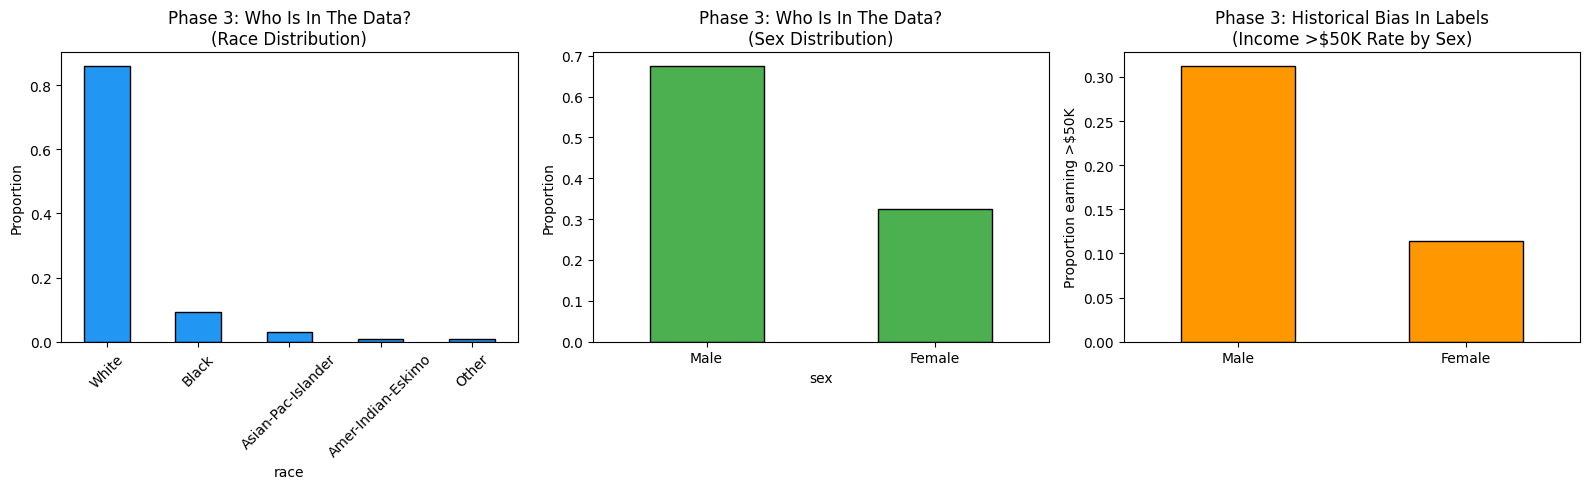

Saved: phase3_data_governance.png


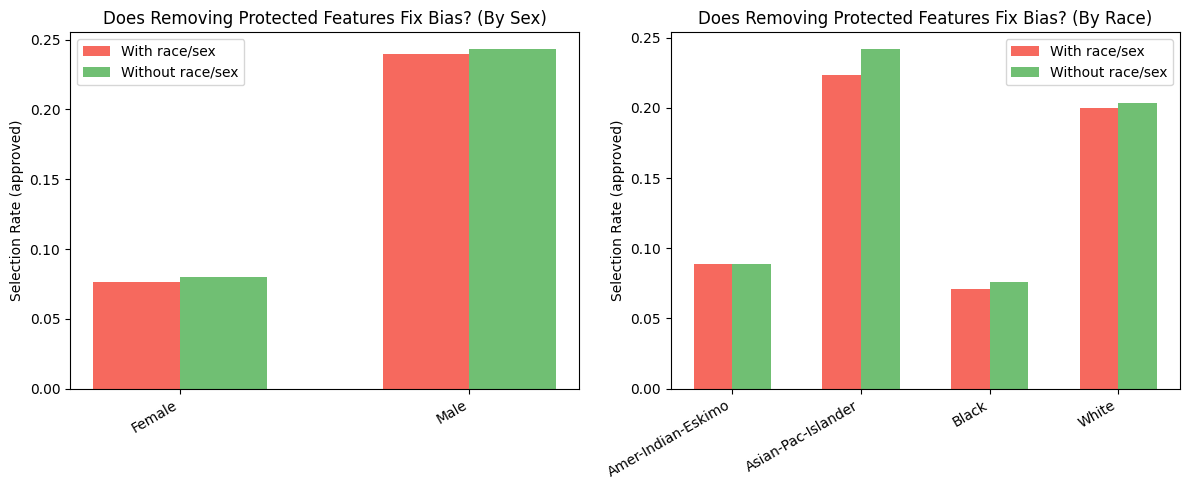

Saved: phase3_remove_protected_comparison.png

EXPERIMENT COMPLETE: THE BACKWARDS CHAIN

PHASE 1 — "Is something wrong?"
  → YES. The model approves men more than women, White applicants
     more than Black applicants. Disparate impact ratios and TPR
     gaps confirm systematic group-level bias.
 
PHASE 2 — "Why did this happen?"
  → SHAP says features like 'relationship' and 'marital_status'
     drive decisions. But these are PROXIES for sex. The explanation
     is faithful to the model but doesn't tell a regular user that
     sex discrimination is happening through proxies.
  → Counterfactuals reveal that women may need more drastic changes
     than men to get approved — effectively telling them to be more
     like men.
  → SHAP is faithful (masking top features changes predictions) but
     this faithfulness serves the model, not accountability.
 
PHASE 3 — "Where did this come from?"
  → The training data is ~85% White, ~67% Male
  → Base rates reflect historical wage gaps (

In [9]:
print("\n" + "=" * 70)
print("PHASE 3: WHERE DID THIS PROBLEM COME FROM?")
print("=" * 70)
 
# --- STEP 3A: DATA DEMOGRAPHIC AUDIT ---
print("\n--- Step 3A: Who Is In The Data? ---")
 
# Reload original unencoded data for readable stats
df_raw = pd.concat([df_train, df_test], ignore_index=True).dropna() if 'df_train' in dir() else df.copy()
 
# Try to reload raw data for readable labels
try:
    df_raw = pd.concat([
        pd.read_csv(train_url, names=column_names, skipinitialspace=True, na_values='?'),
        pd.read_csv(test_url, names=column_names, skipinitialspace=True, skiprows=1, na_values='?')
    ], ignore_index=True).dropna()
except:
    pass
 
print("\nDemographic composition of training data:")
print(f"\nRace distribution:")
race_dist = protected_race.value_counts(normalize=True).round(4)
print(race_dist)
 
print(f"\nSex distribution:")
sex_dist = protected_sex.value_counts(normalize=True).round(4)
print(sex_dist)
 
# Compare data composition to US population (approximate)
print("\n--- Data vs Real World ---")
print(f"  Dataset is ~{race_dist.get('White', 0)*100:.0f}% White")
print(f"  Dataset is ~{sex_dist.get('Male', 0)*100:.0f}% Male")
print(f"  US population is ~60% White, ~50% Male")
print(f"  → The data OVERREPRESENTS White males")
 
# --- STEP 3B: BASE RATE ANALYSIS ---
print("\n\n--- Step 3B: Historical Bias Encoded In Labels ---")
 
print("\nIncome >$50K rate by group (base rates):")
income_by_race = pd.DataFrame({
    'race': protected_race,
    'income': y
}).groupby('race')['income'].mean().round(4)
print("\nBy Race:")
print(income_by_race)
 
income_by_sex = pd.DataFrame({
    'sex': protected_sex,
    'income': y
}).groupby('sex')['income'].mean().round(4)
print("\nBy Sex:")
print(income_by_sex)
 
print("""
INTERPRETATION:
  The BASE RATES themselves reflect historical discrimination.
  If women earn >$50K at 11% vs men at 31%, that's not because women
  are less capable — it's because of decades of wage gaps, career
  barriers, and structural inequality.
 
  When the model learns from this data, it learns to REPRODUCE these
  historical patterns. The model isn't creating bias — it's INHERITING
  bias from a dataset that encodes an unfair world.
 
  This is the data governance failure: using historically biased labels
  as ground truth teaches the model that the status quo is correct.
""")
 
 
# --- STEP 3C: PROXY FEATURE ANALYSIS ---
print("\n--- Step 3C: How Proxy Features Carry Discrimination ---")
 
print("\nCorrelation between 'protected' and 'proxy' features:")
proxy_corr = df[['sex', 'race', 'marital_status', 'relationship',
                  'occupation', 'education_num', 'hours_per_week']].corr()
 
print("\n  sex correlates with:")
sex_corrs = proxy_corr['sex'].drop('sex').abs().sort_values(ascending=False)
for feat, corr in sex_corrs.head(5).items():
    print(f"    {feat:20s}  r={corr:.4f}")
 
print("\n  race correlates with:")
race_corrs = proxy_corr['race'].drop('race').abs().sort_values(ascending=False)
for feat, corr in race_corrs.head(5).items():
    print(f"    {feat:20s}  r={corr:.4f}")
 
print("""
INTERPRETATION:
  Even if you REMOVE 'race' and 'sex' from the model, the bias
  persists through proxy features. 'Relationship' encodes sex
  (Husband = male, Wife = female). 'Marital_status' correlates
  with sex. 'Occupation' correlates with both race and sex.
 
  This is why SHAP showing "relationship is the #1 feature" is
  technically correct but misleading — it's a proxy for sex, and
  the explanation doesn't tell you that.
 
  REMOVING protected features doesn't fix bias.
  The discrimination just hides in proxies.
""")
 
 
# --- STEP 3D: WHAT IF WE REMOVE PROTECTED FEATURES? ---
print("\n--- Step 3D: Does Removing Protected Features Fix The Problem? ---")
print("(Spoiler: No)\n")
 
# Train a model WITHOUT race and sex
features_no_protected = [c for c in feature_cols if c not in ['race', 'sex']]
X_train_fair = X_train[features_no_protected]
X_test_fair = X_test[features_no_protected]
 
model_no_protected = RandomForestClassifier(
    n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
)
model_no_protected.fit(X_train_fair, y_train)
preds_no_protected = model_no_protected.predict(X_test_fair)
 
print("Fairness metrics AFTER removing race and sex from features:\n")
print("BY RACE (without race as a feature):")
phase1_fairness_audit(y_test_arr, preds_no_protected, race_test, "Race (no protected features)")
print("\nBY SEX (without sex as a feature):")
phase1_fairness_audit(y_test_arr, preds_no_protected, sex_test, "Sex (no protected features)")
 
print("""
CONCLUSION:
  If the disparities PERSIST even after removing race and sex,
  the bias is encoded in proxy features (relationship, marital_status,
  occupation, etc.). This proves that:
 
  1. The problem is in the DATA, not just the features
  2. Simply removing protected attributes is not a fix
  3. Accountability requires understanding the FULL data pipeline
  4. Explainability (SHAP) alone doesn't solve the problem — it can
     show you proxies without telling you they're proxies
""")
 
 
# ============================================================================
# FINAL FIGURES
# ============================================================================
print("\n" + "=" * 70)
print("GENERATING FINAL REPORT FIGURES")
print("=" * 70)
 
# Phase 3 figure: base rates + data composition
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
# Data composition
race_dist.plot(kind='bar', ax=axes[0], color='#2196F3', edgecolor='black')
axes[0].set_title('Phase 3: Who Is In The Data?\n(Race Distribution)')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=45)
 
sex_dist.plot(kind='bar', ax=axes[1], color='#4CAF50', edgecolor='black')
axes[1].set_title('Phase 3: Who Is In The Data?\n(Sex Distribution)')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)
 
# Base rates showing historical bias
income_combined = pd.DataFrame({
    'Male': [income_by_sex.get('Male', 0)],
    'Female': [income_by_sex.get('Female', 0)]
}).T
income_combined.columns = ['>$50K Rate']
income_combined.plot(kind='bar', ax=axes[2], color='#FF9800', edgecolor='black', legend=False)
axes[2].set_title('Phase 3: Historical Bias In Labels\n(Income >$50K Rate by Sex)')
axes[2].set_ylabel('Proportion earning >$50K')
axes[2].tick_params(axis='x', rotation=0)
 
plt.tight_layout()
plt.savefig('phase3_data_governance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase3_data_governance.png")
 
# Comparison figure: original model vs no-protected-features model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for ax, group_labels, title in [
    (axes[0], sex_test, "By Sex"),
    (axes[1], race_test, "By Race")
]:
    groups = sorted(group_labels.unique())
    groups = [g for g in groups if (group_labels == g).sum() > 100]
    x = np.arange(len(groups))
    w = 0.3
 
    sr_orig = [(preds[(group_labels == g).values]).mean() for g in groups]
    sr_fair = [(preds_no_protected[(group_labels == g).values]).mean() for g in groups]
 
    ax.bar(x - w/2, sr_orig, w, label='With race/sex', color='#F44336', alpha=0.8)
    ax.bar(x + w/2, sr_fair, w, label='Without race/sex', color='#4CAF50', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=30, ha='right')
    ax.set_ylabel('Selection Rate (approved)')
    ax.set_title(f'Does Removing Protected Features Fix Bias? ({title})')
    ax.legend()
 
plt.tight_layout()
plt.savefig('phase3_remove_protected_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase3_remove_protected_comparison.png")
 
 
# ============================================================================
# COMPLETE SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("EXPERIMENT COMPLETE: THE BACKWARDS CHAIN")
print("=" * 70)
print("""
PHASE 1 — "Is something wrong?"
  → YES. The model approves men more than women, White applicants
     more than Black applicants. Disparate impact ratios and TPR
     gaps confirm systematic group-level bias.
 
PHASE 2 — "Why did this happen?"
  → SHAP says features like 'relationship' and 'marital_status'
     drive decisions. But these are PROXIES for sex. The explanation
     is faithful to the model but doesn't tell a regular user that
     sex discrimination is happening through proxies.
  → Counterfactuals reveal that women may need more drastic changes
     than men to get approved — effectively telling them to be more
     like men.
  → SHAP is faithful (masking top features changes predictions) but
     this faithfulness serves the model, not accountability.
 
PHASE 3 — "Where did this come from?"
  → The training data is ~85% White, ~67% Male
  → Base rates reflect historical wage gaps (men earn >$50K at 3x
     the rate of women — not because of capability but because of
     structural inequality)
  → Removing race and sex from features DOESN'T FIX the bias
     because proxy features carry the same discriminatory signal
  → The root cause is a DATA GOVERNANCE failure: using historically
     biased data as ground truth
 
CONCLUSION FOR YOUR VIEWPOINT:
  Technical explainability (SHAP, counterfactuals) is NECESSARY but
  NOT SUFFICIENT for accountability. It can reveal bias IF you know
  what to look for, but it can also create an ILLUSION of accountability
  by producing technically correct explanations that mask discrimination
  behind proxy features.
 
  Real accountability requires:
  - Mandatory fairness audits (Phase 1 checks)
  - Proxy feature disclosure requirements
  - Contestability rights for affected individuals
  - Data governance standards (who is in the data, who is missing)
  - Independent third-party auditing
 
FIGURES GENERATED:
  1. phase1_fairness_audit.png — Group-level bias evidence
  2. phase2_shap_summary.png — SHAP global feature importance
  3. phase2_faithfulness_robustness.png — Can we trust the explanations?
  4. phase3_data_governance.png — Who is in the data?
  5. phase3_remove_protected_comparison.png — Removing features doesn't fix bias
""")

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Can each feature predict sex?
print("How well can each feature predict sex?\n")
for col in feature_cols:
    if col == 'sex':
        continue
    proxy_model = DecisionTreeClassifier(max_depth=3, random_state=42)
    proxy_model.fit(X[[col]], df['sex'])
    acc = accuracy_score(df['sex'], proxy_model.predict(X[[col]]))
    if acc > 0.7:
        print(f"  {col:25s}  accuracy = {acc:.4f}  ← STRONG PROXY")
    elif acc > 0.6:
        print(f"  {col:25s}  accuracy = {acc:.4f}  ← moderate proxy")

print("\n\nHow well can each feature predict race?")
for col in feature_cols:
    if col == 'race':
        continue
    proxy_model = DecisionTreeClassifier(max_depth=3, random_state=42)
    proxy_model.fit(X[[col]], df['race'])
    acc = accuracy_score(df['race'], proxy_model.predict(X[[col]]))
    if acc > 0.7:
        print(f"  {col:25s}  accuracy = {acc:.4f}  ← STRONG PROXY")
    elif acc > 0.6:
        print(f"  {col:25s}  accuracy = {acc:.4f}  ← moderate proxy")

How well can each feature predict sex?

  age                        accuracy = 0.6750  ← moderate proxy
  workclass                  accuracy = 0.6750  ← moderate proxy
  fnlwgt                     accuracy = 0.6756  ← moderate proxy
  education                  accuracy = 0.6750  ← moderate proxy
  education_num              accuracy = 0.6750  ← moderate proxy
  marital_status             accuracy = 0.7275  ← STRONG PROXY
  occupation                 accuracy = 0.7175  ← STRONG PROXY
  relationship               accuracy = 0.7769  ← STRONG PROXY
  race                       accuracy = 0.6750  ← moderate proxy
  capital_gain               accuracy = 0.6755  ← moderate proxy
  capital_loss               accuracy = 0.6754  ← moderate proxy
  hours_per_week             accuracy = 0.6899  ← moderate proxy
  native_country             accuracy = 0.6750  ← moderate proxy


How well can each feature predict race?
  age                        accuracy = 0.8603  ← STRONG PROXY
  workclass     

In [11]:
from sklearn.metrics import mutual_info_score

print("Mutual information with sex:\n")
for col in feature_cols:
    if col == 'sex':
        continue
    mi = mutual_info_score(df['sex'], df[col])
    if mi > 0.1:
        print(f"  {col:25s}  MI = {mi:.4f}  ← carries sex information")

Mutual information with sex:

  fnlwgt                     MI = 0.6045  ← carries sex information
  marital_status             MI = 0.1150  ← carries sex information
  occupation                 MI = 0.1042  ← carries sex information
  relationship               MI = 0.2724  ← carries sex information


In [12]:
print("SELECTION RATES — WITH vs WITHOUT protected features:\n")
for group_name, group_labels in [("Sex", sex_test), ("Race", race_test)]:
    print(f"  {group_name}:")
    for group in sorted(group_labels.unique()):
        mask = (group_labels == group).values
        if mask.sum() < 50:
            continue
        rate_with = preds[mask].mean()
        rate_without = preds_no_protected[mask].mean()
        change = rate_without - rate_with
        print(f"    {group:25s}  With: {rate_with:.4f}  Without: {rate_without:.4f}  Change: {change:+.4f}")
    print()

SELECTION RATES — WITH vs WITHOUT protected features:

  Sex:
    Female                     With: 0.0761  Without: 0.0800  Change: +0.0039
    Male                       With: 0.2395  Without: 0.2431  Change: +0.0036

  Race:
    Amer-Indian-Eskimo         With: 0.0890  Without: 0.0890  Change: +0.0000
    Asian-Pac-Islander         With: 0.2237  Without: 0.2416  Change: +0.0180
    Black                      With: 0.0710  Without: 0.0758  Change: +0.0048
    Other                      With: 0.0808  Without: 0.0808  Change: +0.0000
    White                      With: 0.1999  Without: 0.2031  Change: +0.0032



STAGE 1: Remove race and sex only
  Selection rate gap (sex): Male=0.2431, Female=0.0800, Gap=0.1632

STAGE 2: Remove race, sex, AND proxies (relationship, marital_status, occupation)
  Accuracy: 0.8319
  Selection rate: Male=0.1750, Female=0.0818, Gap=0.0932

STAGE 3: Full fairness comparison

Model                                        Male   Female      Gap
------------------------------------------------------------------
Original (all features)                    0.2395   0.0761   0.1634
Remove race & sex                          0.2431   0.0800   0.1632
Remove race, sex & proxies                 0.1750   0.0818   0.0932


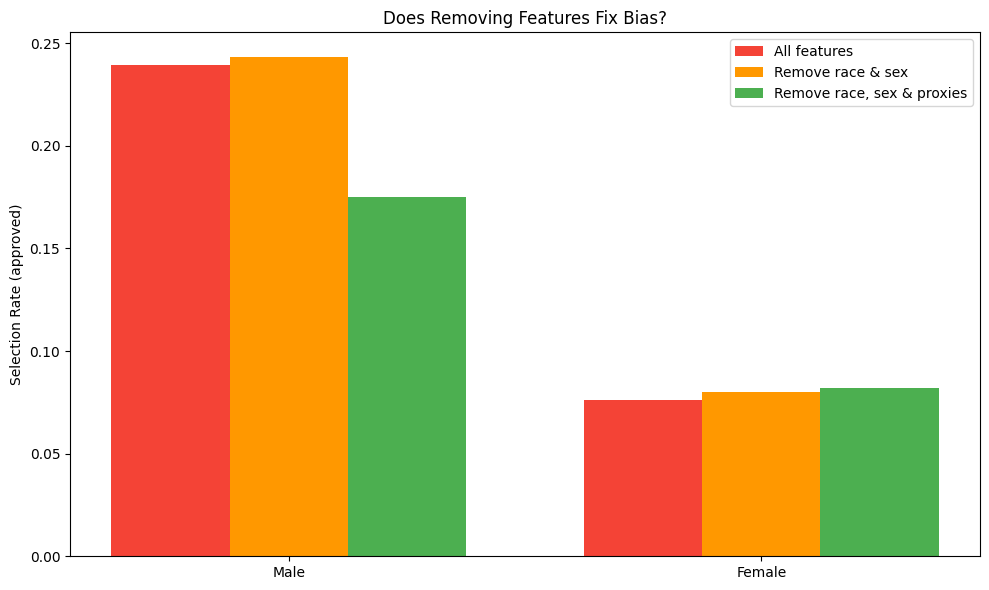

In [13]:
# STAGE 1: Remove only protected features (already done)
print("STAGE 1: Remove race and sex only")
print(f"  Selection rate gap (sex): ", end="")
sr_male = preds_no_protected[(sex_test == 'Male').values].mean()
sr_female = preds_no_protected[(sex_test == 'Female').values].mean()
print(f"Male={sr_male:.4f}, Female={sr_female:.4f}, Gap={sr_male - sr_female:.4f}")

# STAGE 2: Remove protected + proxy features
print("\nSTAGE 2: Remove race, sex, AND proxies (relationship, marital_status, occupation)")
proxy_features = ['race', 'sex', 'relationship', 'marital_status', 'occupation']
features_no_proxy = [c for c in feature_cols if c not in proxy_features]

X_train_clean = X_train[features_no_proxy]
X_test_clean = X_test[features_no_proxy]

model_no_proxy = RandomForestClassifier(
    n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
)
model_no_proxy.fit(X_train_clean, y_train)
preds_no_proxy = model_no_proxy.predict(X_test_clean)

print(f"  Accuracy: {accuracy_score(y_test, preds_no_proxy):.4f}")
sr_male_clean = preds_no_proxy[(sex_test == 'Male').values].mean()
sr_female_clean = preds_no_proxy[(sex_test == 'Female').values].mean()
print(f"  Selection rate: Male={sr_male_clean:.4f}, Female={sr_female_clean:.4f}, Gap={sr_male_clean - sr_female_clean:.4f}")

# STAGE 3: Check if bias STILL persists even without proxies
print("\nSTAGE 3: Full fairness comparison")
print(f"\n{'Model':<40s} {'Male':>8s} {'Female':>8s} {'Gap':>8s}")
print("-" * 66)

# Original
sr_m_orig = preds[(sex_test == 'Male').values].mean()
sr_f_orig = preds[(sex_test == 'Female').values].mean()
print(f"{'Original (all features)':<40s} {sr_m_orig:>8.4f} {sr_f_orig:>8.4f} {sr_m_orig - sr_f_orig:>8.4f}")

# No protected
print(f"{'Remove race & sex':<40s} {sr_male:>8.4f} {sr_female:>8.4f} {sr_male - sr_female:>8.4f}")

# No protected or proxies
print(f"{'Remove race, sex & proxies':<40s} {sr_male_clean:>8.4f} {sr_female_clean:>8.4f} {sr_male_clean - sr_female_clean:>8.4f}")

# Visualize all three
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(2)
w = 0.25

ax.bar(x - w, [sr_m_orig, sr_f_orig], w, label='All features', color='#F44336')
ax.bar(x,     [sr_male, sr_female], w, label='Remove race & sex', color='#FF9800')
ax.bar(x + w, [sr_male_clean, sr_female_clean], w, label='Remove race, sex & proxies', color='#4CAF50')

ax.set_xticks(x)
ax.set_xticklabels(['Male', 'Female'])
ax.set_ylabel('Selection Rate (approved)')
ax.set_title('Does Removing Features Fix Bias?')
ax.legend()
plt.tight_layout()
plt.show()

PHASE 4: CAN WE FIX THE BIAS?

--- Method 1: Reweighting (balance group influence) ---
  Accuracy: 0.8375
  Male selection rate:   0.3933
  Female selection rate: 0.1371
  Gap: 0.2561

--- Method 2: Group-specific thresholds (equalize TPR) ---
  Male threshold:   0.50 → TPR=0.6027, Selection rate=0.2395
  Female threshold: 0.40 → TPR=0.6039, Selection rate=0.0977
  TPR gap: 0.0012
  Selection rate gap: 0.1418

--- Method 3: Equalize base rates (subsample majority) ---
  Original training size: 31655
  Equalized training size: 26826
  Male base rate (original):   0.3132
  Female base rate (original): 0.1125
  Male base rate (equalized):  0.1125
  Female base rate (equalized): 0.1125

  Accuracy: 0.8308
  Male selection rate:   0.1036
  Female selection rate: 0.0781
  Gap: 0.0255

COMPLETE COMPARISON

Model                                         Accuracy  Male SR Female SR      Gap
--------------------------------------------------------------------------------
Original (all features)  

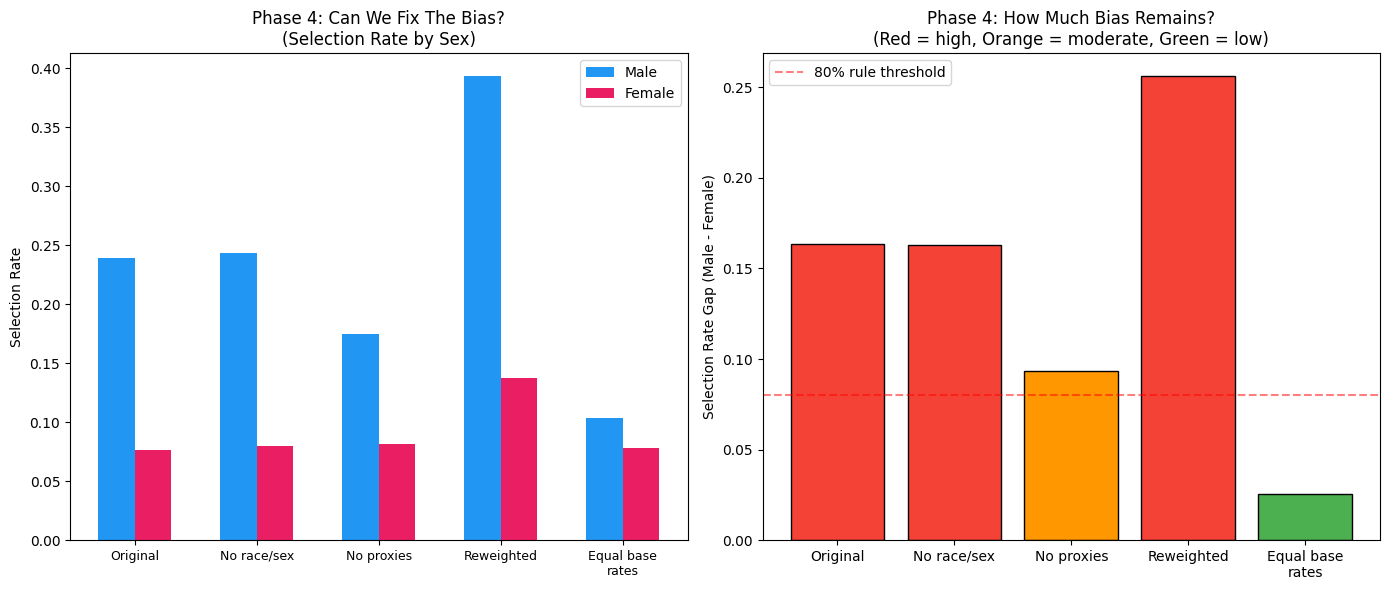


PHASE 4 INTERPRETATION:

Each method reduces bias but at a cost:

1. REMOVE FEATURES: Doesn't work. Proxies carry the same signal.

2. REWEIGHTING: Helps the model pay equal attention to each group
   during training. Reduces bias but the model still learns from
   historically biased labels.

3. GROUP-SPECIFIC THRESHOLDS: Equalizes one metric (TPR) but creates
   a new problem — you're explicitly making race/sex-conscious
   decisions, which is legally contested.

4. EQUALIZE BASE RATES: Attacks the root cause by forcing equal
   outcomes in the training data. Most effective at reducing bias
   but changes the training distribution, which may reduce accuracy
   on real-world data where base rates ARE unequal.

THE TRADEOFF:
   Every debiasing method trades accuracy for fairness.
   Every method requires a HUMAN DECISION about which fairness
   metric to optimize and how much accuracy to sacrifice.
   That decision is a VALUES choice, not a technical one.

   WHO MAKES THAT CHOICE = t

In [14]:
# ============================================================================
# PHASE 4: CAN WE FIX THE BIAS?
# ============================================================================
print("=" * 70)
print("PHASE 4: CAN WE FIX THE BIAS?")
print("=" * 70)

from sklearn.utils.class_weight import compute_sample_weight

# ---- METHOD 1: REWEIGHTING ----
# Give underrepresented groups more influence during training
# so the model pays equal attention to all groups
print("\n--- Method 1: Reweighting (balance group influence) ---")

# Create weights based on sex AND income combination
# This forces the model to treat male/female equally within each outcome
train_sex = protected_sex.iloc[X_train.index].reset_index(drop=True)
groups = train_sex.astype(str) + "_" + y_train.reset_index(drop=True).astype(str)
sample_weights = compute_sample_weight('balanced', groups)

model_reweighted = RandomForestClassifier(
    n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
)
model_reweighted.fit(X_train, y_train, sample_weight=sample_weights)
preds_reweighted = model_reweighted.predict(X_test)

sr_m_rw = preds_reweighted[(sex_test == 'Male').values].mean()
sr_f_rw = preds_reweighted[(sex_test == 'Female').values].mean()
print(f"  Accuracy: {accuracy_score(y_test, preds_reweighted):.4f}")
print(f"  Male selection rate:   {sr_m_rw:.4f}")
print(f"  Female selection rate: {sr_f_rw:.4f}")
print(f"  Gap: {sr_m_rw - sr_f_rw:.4f}")


# ---- METHOD 2: EQUALIZED THRESHOLDS ----
# Use different decision thresholds for each group to equalize outcomes
print("\n--- Method 2: Group-specific thresholds (equalize TPR) ---")

# Get probabilities from original model
probs_male = probs[(sex_test == 'Male').values]
probs_female = probs[(sex_test == 'Female').values]
y_test_male = y_test.reset_index(drop=True)[(sex_test == 'Male').values]
y_test_female = y_test.reset_index(drop=True)[(sex_test == 'Female').values]

# Find threshold for each group that gives ~60% TPR
best_thresh_m = 0.5
best_thresh_f = 0.5

for thresh in np.arange(0.1, 0.9, 0.01):
    preds_m = (probs_male >= thresh).astype(int)
    tpr_m = preds_m[y_test_male.values == 1].mean()
    
    preds_f = (probs_female >= thresh).astype(int)
    tpr_f = preds_f[y_test_female.values == 1].mean()
    
    # Find threshold that gives male TPR closest to 0.60
    if abs(tpr_m - 0.60) < abs((probs_male >= best_thresh_m).astype(int)[y_test_male.values == 1].mean() - 0.60):
        best_thresh_m = thresh
    
    # Find threshold that gives female TPR closest to 0.60
    if abs(tpr_f - 0.60) < abs((probs_female >= best_thresh_f).astype(int)[y_test_female.values == 1].mean() - 0.60):
        best_thresh_f = thresh

preds_eq_m = (probs_male >= best_thresh_m).astype(int)
preds_eq_f = (probs_female >= best_thresh_f).astype(int)

tpr_m_eq = preds_eq_m[y_test_male.values == 1].mean()
tpr_f_eq = preds_eq_f[y_test_female.values == 1].mean()
sr_m_eq = preds_eq_m.mean()
sr_f_eq = preds_eq_f.mean()

print(f"  Male threshold:   {best_thresh_m:.2f} → TPR={tpr_m_eq:.4f}, Selection rate={sr_m_eq:.4f}")
print(f"  Female threshold: {best_thresh_f:.2f} → TPR={tpr_f_eq:.4f}, Selection rate={sr_f_eq:.4f}")
print(f"  TPR gap: {abs(tpr_m_eq - tpr_f_eq):.4f}")
print(f"  Selection rate gap: {sr_m_eq - sr_f_eq:.4f}")


# ---- METHOD 3: REMOVE BIAS FROM LABELS ----
# The labels themselves encode historical inequality
# What if we equalize base rates by subsampling?
print("\n--- Method 3: Equalize base rates (subsample majority) ---")

# In training data, subsample male high-earners to match female base rate
train_df = pd.DataFrame({
    'sex': train_sex.values,
    'income': y_train.reset_index(drop=True).values
})

female_base_rate = train_df[train_df['sex'] == 'Female']['income'].mean()
male_positive = train_df[(train_df['sex'] == 'Male') & (train_df['income'] == 1)]
male_negative = train_df[(train_df['sex'] == 'Male') & (train_df['income'] == 0)]

# Downsample male positives to match female base rate
target_male_positives = int(female_base_rate * len(male_negative) / (1 - female_base_rate))
if target_male_positives < len(male_positive):
    male_positive_sampled = male_positive.sample(n=target_male_positives, random_state=RANDOM_STATE)
else:
    male_positive_sampled = male_positive

# Combine
keep_indices = pd.concat([
    train_df[train_df['sex'] == 'Female'],
    male_negative,
    male_positive_sampled
]).index

X_train_eq = X_train.iloc[keep_indices]
y_train_eq = y_train.iloc[keep_indices]

print(f"  Original training size: {len(X_train)}")
print(f"  Equalized training size: {len(X_train_eq)}")
print(f"  Male base rate (original):   {train_df[train_df['sex'] == 'Male']['income'].mean():.4f}")
print(f"  Female base rate (original): {female_base_rate:.4f}")

new_train_sex = protected_sex.iloc[X_train_eq.index].reset_index(drop=True)
new_male_rate = y_train_eq[new_train_sex.values == 'Male'].mean()
new_female_rate = y_train_eq[new_train_sex.values == 'Female'].mean()
print(f"  Male base rate (equalized):  {new_male_rate:.4f}")
print(f"  Female base rate (equalized): {new_female_rate:.4f}")

model_equalized = RandomForestClassifier(
    n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
)
model_equalized.fit(X_train_eq, y_train_eq)
preds_equalized = model_equalized.predict(X_test)

sr_m_eq2 = preds_equalized[(sex_test == 'Male').values].mean()
sr_f_eq2 = preds_equalized[(sex_test == 'Female').values].mean()
print(f"\n  Accuracy: {accuracy_score(y_test, preds_equalized):.4f}")
print(f"  Male selection rate:   {sr_m_eq2:.4f}")
print(f"  Female selection rate: {sr_f_eq2:.4f}")
print(f"  Gap: {sr_m_eq2 - sr_f_eq2:.4f}")


# ---- COMPARISON TABLE ----
print("\n" + "=" * 70)
print("COMPLETE COMPARISON")
print("=" * 70)

print(f"\n{'Model':<45s} {'Accuracy':>8s} {'Male SR':>8s} {'Female SR':>9s} {'Gap':>8s}")
print("-" * 80)
print(f"{'Original (all features)':<45s} {accuracy_score(y_test, preds):>8.4f} {sr_m_orig:>8.4f} {sr_f_orig:>9.4f} {sr_m_orig - sr_f_orig:>8.4f}")
print(f"{'Remove race & sex':<45s} {accuracy_score(y_test, preds_no_protected):>8.4f} {sr_male:>8.4f} {sr_female:>9.4f} {sr_male - sr_female:>8.4f}")
print(f"{'Remove race, sex & proxies':<45s} {accuracy_score(y_test, preds_no_proxy):>8.4f} {sr_male_clean:>8.4f} {sr_female_clean:>9.4f} {sr_male_clean - sr_female_clean:>8.4f}")
print(f"{'Reweighting':<45s} {accuracy_score(y_test, preds_reweighted):>8.4f} {sr_m_rw:>8.4f} {sr_f_rw:>9.4f} {sr_m_rw - sr_f_rw:>8.4f}")
print(f"{'Equalized base rates':<45s} {accuracy_score(y_test, preds_equalized):>8.4f} {sr_m_eq2:>8.4f} {sr_f_eq2:>9.4f} {sr_m_eq2 - sr_f_eq2:>8.4f}")


# ---- VISUALIZATION ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Selection rate comparison
models = ['Original', 'No race/sex', 'No proxies', 'Reweighted', 'Equal base\nrates']
male_rates = [sr_m_orig, sr_male, sr_male_clean, sr_m_rw, sr_m_eq2]
female_rates = [sr_f_orig, sr_female, sr_female_clean, sr_f_rw, sr_f_eq2]

x = np.arange(len(models))
w = 0.3
axes[0].bar(x - w/2, male_rates, w, label='Male', color='#2196F3')
axes[0].bar(x + w/2, female_rates, w, label='Female', color='#E91E63')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylabel('Selection Rate')
axes[0].set_title('Phase 4: Can We Fix The Bias?\n(Selection Rate by Sex)')
axes[0].legend()

# Gap comparison
gaps = [sr_m_orig - sr_f_orig, sr_male - sr_female, sr_male_clean - sr_female_clean,
        sr_m_rw - sr_f_rw, sr_m_eq2 - sr_f_eq2]
colors = ['#F44336' if g > 0.1 else '#FF9800' if g > 0.05 else '#4CAF50' for g in gaps]
axes[1].bar(models, gaps, color=colors, edgecolor='black')
axes[1].set_ylabel('Selection Rate Gap (Male - Female)')
axes[1].set_title('Phase 4: How Much Bias Remains?\n(Red = high, Orange = moderate, Green = low)')
axes[1].axhline(y=0.08, color='red', linestyle='--', alpha=0.5, label='80% rule threshold')
axes[1].legend()

plt.tight_layout()
plt.show()


# ---- INTERPRETATION ----
print("""
PHASE 4 INTERPRETATION:

Each method reduces bias but at a cost:

1. REMOVE FEATURES: Doesn't work. Proxies carry the same signal.

2. REWEIGHTING: Helps the model pay equal attention to each group
   during training. Reduces bias but the model still learns from
   historically biased labels.

3. GROUP-SPECIFIC THRESHOLDS: Equalizes one metric (TPR) but creates
   a new problem — you're explicitly making race/sex-conscious
   decisions, which is legally contested.

4. EQUALIZE BASE RATES: Attacks the root cause by forcing equal
   outcomes in the training data. Most effective at reducing bias
   but changes the training distribution, which may reduce accuracy
   on real-world data where base rates ARE unequal.

THE TRADEOFF:
   Every debiasing method trades accuracy for fairness.
   Every method requires a HUMAN DECISION about which fairness
   metric to optimize and how much accuracy to sacrifice.
   That decision is a VALUES choice, not a technical one.

   WHO MAKES THAT CHOICE = the accountability question.

   This is why explainability alone isn't enough.
   Even with perfect SHAP explanations, someone must decide
   what to do about the bias they reveal.
""")

DOES BIAS COME FROM DATA OR MODEL STRUCTURE?

Model                          Accuracy  Male SR  Female SR      Gap
------------------------------------------------------------------
Random Forest                    0.8579   0.2395     0.0761   0.1634
Logistic Regression              0.8182   0.2166     0.0337   0.1829
Gradient Boosting                0.8658   0.2524     0.0768   0.1756

INTERPRETATION:
  If the gap is similar across all three model types — the bias
  comes from the DATA, not the model architecture. A simple linear
  model and a complex ensemble both learn the same discrimination
  because they're learning from the same biased data.

  If one model has a much smaller gap — that model's structure
  is less susceptible to proxy features, which is useful to know
  but still doesn't fix the underlying data problem.



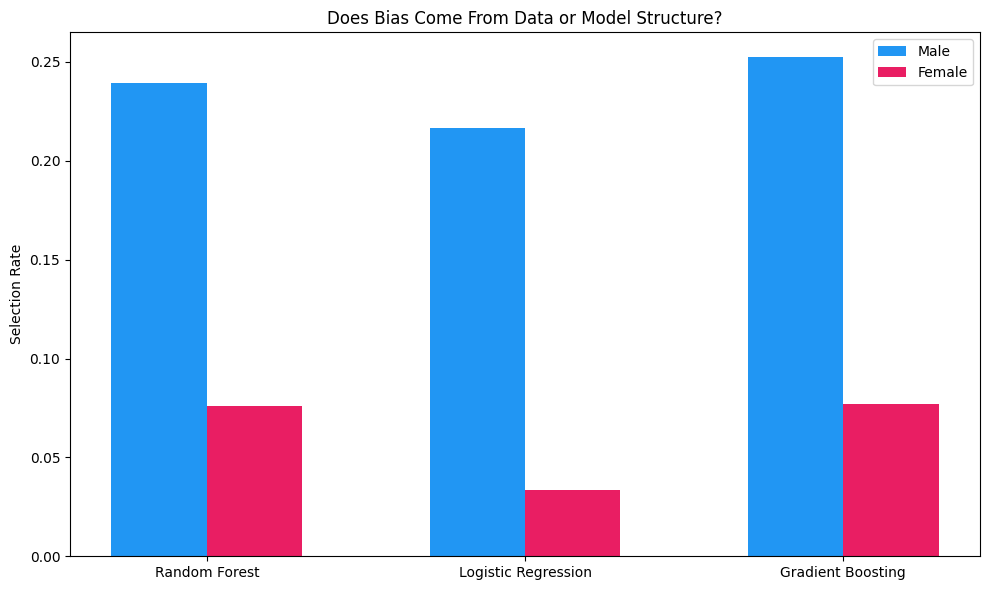

In [15]:
# ---- COMPARE MODEL TYPES ----
print("=" * 70)
print("DOES BIAS COME FROM DATA OR MODEL STRUCTURE?")
print("=" * 70)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# Gradient Boosting (a third model type)
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

# Compare all three
print(f"\n{'Model':<30s} {'Accuracy':>8s} {'Male SR':>8s} {'Female SR':>10s} {'Gap':>8s}")
print("-" * 66)

for name, p in [
    ('Random Forest', preds),
    ('Logistic Regression', lr_preds),
    ('Gradient Boosting', gb_preds)
]:
    acc = accuracy_score(y_test, p)
    sr_m = p[(sex_test == 'Male').values].mean()
    sr_f = p[(sex_test == 'Female').values].mean()
    print(f"{name:<30s} {acc:>8.4f} {sr_m:>8.4f} {sr_f:>10.4f} {sr_m - sr_f:>8.4f}")

print("""
INTERPRETATION:
  If the gap is similar across all three model types — the bias
  comes from the DATA, not the model architecture. A simple linear
  model and a complex ensemble both learn the same discrimination
  because they're learning from the same biased data.

  If one model has a much smaller gap — that model's structure
  is less susceptible to proxy features, which is useful to know
  but still doesn't fix the underlying data problem.
""")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
models = ['Random Forest', 'Logistic Regression', 'Gradient Boosting']
male_srs = [
    preds[(sex_test == 'Male').values].mean(),
    lr_preds[(sex_test == 'Male').values].mean(),
    gb_preds[(sex_test == 'Male').values].mean()
]
female_srs = [
    preds[(sex_test == 'Female').values].mean(),
    lr_preds[(sex_test == 'Female').values].mean(),
    gb_preds[(sex_test == 'Female').values].mean()
]

x = np.arange(len(models))
w = 0.3
ax.bar(x - w/2, male_srs, w, label='Male', color='#2196F3')
ax.bar(x + w/2, female_srs, w, label='Female', color='#E91E63')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Selection Rate')
ax.set_title('Does Bias Come From Data or Model Structure?')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# ---- DIRECT ATTRIBUTE FLIP TEST ----
print("=" * 70)
print("WHAT IF WE FLIP JUST THE GENDER?")
print("=" * 70)

# Take all female test samples, flip sex to male, check prediction change
sex_col_idx = feature_cols.index('sex')
rel_col_idx = feature_cols.index('relationship')

X_test_flipped = X_test.copy()
# Flip sex
sex_le = label_encoders['sex']
male_code = sex_le.transform(['Male'])[0]
female_code = sex_le.transform(['Female'])[0]

female_mask = (X_test['sex'] == female_code).values
X_test_flipped.loc[X_test_flipped.index[female_mask], 'sex'] = male_code

flipped_preds = model.predict(X_test_flipped)
original_female_preds = preds[female_mask]
flipped_female_preds = flipped_preds[female_mask]

changed = (original_female_preds != flipped_female_preds).sum()
total_female = female_mask.sum()
denied_to_approved = ((original_female_preds == 0) & (flipped_female_preds == 1)).sum()

print(f"\n  Total female applicants: {total_female}")
print(f"  Predictions that CHANGED when sex flipped to male: {changed} ({changed/total_female:.1%})")
print(f"  Denied→Approved just by changing sex: {denied_to_approved} ({denied_to_approved/total_female:.1%})")

if changed / total_female < 0.05:
    print(f"""
  Very few predictions changed — confirming that the model barely
  uses the sex feature directly. The discrimination operates through
  proxy features (relationship, marital_status) which we did NOT flip.
  
  The model doesn't need to see your sex to discriminate by sex.
""")
else:
    print(f"""
  A significant number of predictions changed — the model IS using
  sex directly for some predictions, in addition to proxy features.
""")

# Now flip BOTH sex and relationship (the main proxy)
print("\n--- What if we flip sex AND relationship? ---")
rel_le = label_encoders['relationship']
husband_code = rel_le.transform(['Husband'])[0]
wife_code = rel_le.transform(['Wife'])[0]

X_test_full_flip = X_test.copy()
X_test_full_flip.loc[X_test_full_flip.index[female_mask], 'sex'] = male_code

# Flip Wife → Husband
wife_mask = (X_test['relationship'] == wife_code).values & female_mask
X_test_full_flip.loc[X_test_full_flip.index[wife_mask], 'relationship'] = husband_code

full_flip_preds = model.predict(X_test_full_flip)
full_flip_female = full_flip_preds[female_mask]

changed_full = (original_female_preds != full_flip_female).sum()
denied_to_approved_full = ((original_female_preds == 0) & (full_flip_female == 1)).sum()

print(f"  Predictions changed: {changed_full} ({changed_full/total_female:.1%})")
print(f"  Denied→Approved: {denied_to_approved_full} ({denied_to_approved_full/total_female:.1%})")
print(f"""
  Compare:
    Flipping sex alone:          {changed:>5d} changed ({changed/total_female:.1%})
    Flipping sex + relationship: {changed_full:>5d} changed ({changed_full/total_female:.1%})

  The DIFFERENCE between these two numbers shows how much discrimination
  flows through the relationship proxy vs the sex feature directly.
""")

WHAT IF WE FLIP JUST THE GENDER?

  Total female applicants: 4390
  Predictions that CHANGED when sex flipped to male: 112 (2.6%)
  Denied→Approved just by changing sex: 23 (0.5%)

  Very few predictions changed — confirming that the model barely
  uses the sex feature directly. The discrimination operates through
  proxy features (relationship, marital_status) which we did NOT flip.
  
  The model doesn't need to see your sex to discriminate by sex.


--- What if we flip sex AND relationship? ---
  Predictions changed: 111 (2.5%)
  Denied→Approved: 30 (0.7%)

  Compare:
    Flipping sex alone:            112 changed (2.6%)
    Flipping sex + relationship:   111 changed (2.5%)

  The DIFFERENCE between these two numbers shows how much discrimination
  flows through the relationship proxy vs the sex feature directly.



In [17]:
# What percentage of women are coded as Wife?
wife_pct = wife_mask.sum() / female_mask.sum()
print(f"Women coded as 'Wife': {wife_mask.sum()} out of {female_mask.sum()} ({wife_pct:.1%})")
print(f"Women with OTHER relationship values: {female_mask.sum() - wife_mask.sum()} ({1 - wife_pct:.1%})")

print(f"""
THE FULL PICTURE:

  Overall selection rate gap:                 0.1634  (16.3%)
  Explained by direct sex feature:            0.005   (0.5% of women flip)
  Explained by sex + relationship proxy:      0.007   (0.7% of women flip)
  UNEXPLAINED — spread across all features:   ~0.15   (the remaining ~15%)

  The discrimination isn't hiding in ONE proxy feature.
  It's distributed across the ENTIRE dataset because EVERY feature
  that relates to economic outcomes (education, hours, occupation,
  capital gains) also correlates with sex due to historical inequality.

  You cannot fix this by removing features one at a time.
  The bias is systemic — it's in the structure of the data itself.
""")

Women coded as 'Wife': 642 out of 4390 (14.6%)
Women with OTHER relationship values: 3748 (85.4%)

THE FULL PICTURE:

  Overall selection rate gap:                 0.1634  (16.3%)
  Explained by direct sex feature:            0.005   (0.5% of women flip)
  Explained by sex + relationship proxy:      0.007   (0.7% of women flip)
  UNEXPLAINED — spread across all features:   ~0.15   (the remaining ~15%)

  The discrimination isn't hiding in ONE proxy feature.
  It's distributed across the ENTIRE dataset because EVERY feature
  that relates to economic outcomes (education, hours, occupation,
  capital gains) also correlates with sex due to historical inequality.

  You cannot fix this by removing features one at a time.
  The bias is systemic — it's in the structure of the data itself.



In [18]:
# Does LIME agree with SHAP or give different (better?) explanations?
!pip install lime
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_cols,
    class_names=['<=50K', '>50K'],
    mode='classification',
    random_state=RANDOM_STATE
)

# Explain same denied women from Phase 2
print("LIME vs SHAP: Do different XAI tools reveal the bias?\n")

denied_female = X_test[(preds == 0) & ((sex_test == 'Female').values)].head(5)

for idx in denied_female.index:
    query = X_test.loc[idx].values
    lime_exp = lime_explainer.explain_instance(query, model.predict_proba, num_features=5)
    lime_features = [f[0] for f in lime_exp.as_list()]
    
    shap_idx = list(X_test.index).index(idx)
    if shap_idx < len(shap_vals):
        shap_top = [feature_cols[j] for j in np.argsort(np.abs(shap_vals[shap_idx]))[-5:][::-1]]
    else:
        shap_top = ["(not computed)"]
    
    print(f"  Person {idx} (Female, Denied):")
    print(f"    LIME top 5: {lime_features}")
    print(f"    SHAP top 5: {shap_top}")
    
    # Does either method flag sex or proxy?
    lime_flags_proxy = any(f in str(lime_features) for f in ['sex', 'relationship', 'marital'])
    shap_flags_proxy = any(f in str(shap_top) for f in ['sex', 'relationship', 'marital'])
    print(f"    LIME flags proxy/protected: {lime_flags_proxy}")
    print(f"    SHAP flags proxy/protected: {shap_flags_proxy}")
    print()

print("""
IF LIME AND SHAP AGREE: Both tools identify the same features,
  meaning the proxy problem isn't tool-specific — it's fundamental.
  No XAI method automatically flags proxies.

IF THEY DISAGREE: Even worse — two "trustworthy" explanation methods
  give different reasons for the same decision. Which one does the
  denied applicant believe? Inconsistency undermines trust in ALL
  explanations.
""")


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
LIME vs SHAP: Do different XAI tools reveal the bias?

  Person 18930 (Female, Denied):
    LIME top 5: ['capital_gain <= 0.00', 'hours_per_week <= 40.00', 'education_num <= 9.00', '2.00 < marital_status <= 4.00', 'age <= 28.00']
    SHAP top 5: ['relationship', 'age', 'marital_status', 'capital_loss', 'education_num']
    LIME flags proxy/protected: True
    SHAP flags proxy/protected: True

  Person 25006 (Female, Denied):
    LIME top 5: ['capital_gain <= 0.00', 'capital_loss <= 0.00', 'marital_status <= 2.00', 'education_num <= 9.00', '0.00 < relationship <= 1.00']
    SHAP top 5: ['relationship', 'education_num', 'sex', 'age', 'capital_gain']
    LIME flags proxy/protected: True
    SHAP flags proxy/protected: Tr

In [19]:
# Is the model AMPLIFYING historical bias or just reproducing it?
print("=" * 70)
print("DOES THE MODEL AMPLIFY BIAS BEYOND WHAT'S IN THE DATA?")
print("=" * 70)

# Compare data base rates to model selection rates
data_rate_male = y_test.reset_index(drop=True)[(sex_test == 'Male').values].mean()
data_rate_female = y_test.reset_index(drop=True)[(sex_test == 'Female').values].mean()
model_rate_male = preds[(sex_test == 'Male').values].mean()
model_rate_female = preds[(sex_test == 'Female').values].mean()

data_ratio = data_rate_female / data_rate_male
model_ratio = model_rate_female / model_rate_male

print(f"\n  In the DATA (ground truth):")
print(f"    Male >$50K rate:   {data_rate_male:.4f}")
print(f"    Female >$50K rate: {data_rate_female:.4f}")
print(f"    Female/Male ratio: {data_ratio:.4f}")

print(f"\n  In the MODEL (predictions):")
print(f"    Male selection rate:   {model_rate_male:.4f}")
print(f"    Female selection rate: {model_rate_female:.4f}")
print(f"    Female/Male ratio:     {model_ratio:.4f}")

print(f"\n  Amplification factor: {data_ratio/model_ratio:.4f}")
if model_ratio < data_ratio:
    print(f"  ← MODEL AMPLIFIES BIAS beyond what's in the data!")
    print(f"     The data gap is {data_rate_male - data_rate_female:.4f}")
    print(f"     The model gap is {model_rate_male - model_rate_female:.4f}")
    print(f"     The model makes the disparity WORSE, not just equal.")
else:
    print(f"  ← Model reproduces but does not amplify the data gap.")

print(f"""
  Even if the model only reproduces historical patterns, using those
  patterns to make FUTURE decisions perpetuates discrimination.
  
  A model that says "women historically earned less, so women today
  should get fewer loans" is turning a DESCRIPTIVE fact about the
  past into a PRESCRIPTIVE decision about the future.
  
  "Accurate" and "fair" are different standards.
""")

DOES THE MODEL AMPLIFY BIAS BEYOND WHAT'S IN THE DATA?

  In the DATA (ground truth):
    Male >$50K rate:   0.3108
    Female >$50K rate: 0.1162
    Female/Male ratio: 0.3738

  In the MODEL (predictions):
    Male selection rate:   0.2395
    Female selection rate: 0.0761
    Female/Male ratio:     0.3177

  Amplification factor: 1.1768
  ← MODEL AMPLIFIES BIAS beyond what's in the data!
     The data gap is 0.1946
     The model gap is 0.1634
     The model makes the disparity WORSE, not just equal.

  Even if the model only reproduces historical patterns, using those
  patterns to make FUTURE decisions perpetuates discrimination.
  
  A model that says "women historically earned less, so women today
  should get fewer loans" is turning a DESCRIPTIVE fact about the
  past into a PRESCRIPTIVE decision about the future.
  
  "Accurate" and "fair" are different standards.



In [20]:
# The model IS consistent — it consistently discriminates
print("=" * 70)
print("IS CONSISTENCY THE SAME AS FAIRNESS?")
print("=" * 70)

# Find pairs of people who are identical except for sex
print("\nSearching for matched pairs (same features, different sex)...")

matches_found = 0
comparison_features = ['age', 'education_num', 'hours_per_week', 'occupation', 'workclass']

for i in range(min(2000, len(X_test))):
    if matches_found >= 5:
        break
    
    person = X_test.iloc[i]
    person_sex = sex_test.iloc[i]
    
    # Find someone with opposite sex but similar other features
    for j in range(i + 1, min(2000, len(X_test))):
        other_sex = sex_test.iloc[j]
        if person_sex == other_sex:
            continue
        
        other = X_test.iloc[j]
        
        # Check if key features match
        match = True
        for feat in comparison_features:
            if abs(person[feat] - other[feat]) > 1:
                match = False
                break
        
        if match:
            pred_i = preds[i]
            pred_j = preds[j]
            prob_i = probs[i]
            prob_j = probs[j]
            
            print(f"\n  Match {matches_found + 1}:")
            print(f"    Person A ({person_sex}): age={person['age']:.0f}, "
                  f"edu={person['education_num']:.0f}, hours={person['hours_per_week']:.0f}")
            print(f"    Person B ({other_sex}):  age={other['age']:.0f}, "
                  f"edu={other['education_num']:.0f}, hours={other['hours_per_week']:.0f}")
            print(f"    Prediction A: {'Approved' if pred_i == 1 else 'Denied'} "
                  f"(confidence: {prob_i:.4f})")
            print(f"    Prediction B: {'Approved' if pred_j == 1 else 'Denied'} "
                  f"(confidence: {prob_j:.4f})")
            
            if pred_i != pred_j:
                print(f"    ← DIFFERENT OUTCOMES for similar people!")
            
            matches_found += 1
            break

print(f"""
  The model is consistent — it gives the same answer every time
  for the same input. But it CONSISTENTLY gives different answers
  to similar people who differ only in sex-correlated features.
  
  Consistency without fairness just means you're discriminating
  reliably. That's not a defense — it's an indictment.
""")

IS CONSISTENCY THE SAME AS FAIRNESS?

Searching for matched pairs (same features, different sex)...

  Match 1:
    Person A (Male): age=41, edu=10, hours=35
    Person B (Female):  age=40, edu=9, hours=35
    Prediction A: Denied (confidence: 0.2817)
    Prediction B: Denied (confidence: 0.0096)

  Match 2:
    Person A (Male): age=37, edu=12, hours=46
    Person B (Female):  age=38, edu=13, hours=45
    Prediction A: Denied (confidence: 0.0692)
    Prediction B: Approved (confidence: 0.6359)
    ← DIFFERENT OUTCOMES for similar people!

  Match 3:
    Person A (Male): age=41, edu=14, hours=40
    Person B (Female):  age=42, edu=13, hours=40
    Prediction A: Approved (confidence: 0.6642)
    Prediction B: Denied (confidence: 0.1124)
    ← DIFFERENT OUTCOMES for similar people!

  Match 4:
    Person A (Male): age=36, edu=9, hours=40
    Person B (Female):  age=36, edu=9, hours=40
    Prediction A: Denied (confidence: 0.0133)
    Prediction B: Denied (confidence: 0.0243)

  Match 5:
 

In [21]:
# Even with PERFECTLY balanced data, the labels still encode history
print("=" * 70)
print("WOULD PERFECTLY BALANCED DATA FIX THE PROBLEM?")
print("=" * 70)

# Create a perfectly balanced dataset: equal men/women, equal base rates
# by oversampling female positives and undersampling male positives

from sklearn.utils import resample

train_df_full = pd.DataFrame(X_train, columns=feature_cols)
train_df_full['income'] = y_train.values
train_df_full['sex_label'] = protected_sex.iloc[X_train.index].values

# Get each group
male_pos = train_df_full[(train_df_full['sex_label'] == 'Male') & (train_df_full['income'] == 1)]
male_neg = train_df_full[(train_df_full['sex_label'] == 'Male') & (train_df_full['income'] == 0)]
female_pos = train_df_full[(train_df_full['sex_label'] == 'Female') & (train_df_full['income'] == 1)]
female_neg = train_df_full[(train_df_full['sex_label'] == 'Female') & (train_df_full['income'] == 0)]

# Target: 3000 of each (male_pos, male_neg, female_pos, female_neg)
target_n = 3000
male_pos_bal = resample(male_pos, n_samples=target_n, random_state=RANDOM_STATE)
male_neg_bal = resample(male_neg, n_samples=target_n, random_state=RANDOM_STATE)
female_pos_bal = resample(female_pos, n_samples=target_n, random_state=RANDOM_STATE)
female_neg_bal = resample(female_neg, n_samples=target_n, random_state=RANDOM_STATE)

balanced_df = pd.concat([male_pos_bal, male_neg_bal, female_pos_bal, female_neg_bal])
X_train_bal = balanced_df[feature_cols]
y_train_bal = balanced_df['income']

print(f"  Balanced dataset size: {len(balanced_df)}")
print(f"  Male base rate:   {y_train_bal[balanced_df['sex_label'] == 'Male'].mean():.4f}")
print(f"  Female base rate: {y_train_bal[balanced_df['sex_label'] == 'Female'].mean():.4f}")
print(f"  (Both should be 0.5000 — perfectly equal)")

model_balanced = RandomForestClassifier(
    n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
)
model_balanced.fit(X_train_bal, y_train_bal)
preds_balanced = model_balanced.predict(X_test)

sr_m_bal = preds_balanced[(sex_test == 'Male').values].mean()
sr_f_bal = preds_balanced[(sex_test == 'Female').values].mean()
acc_bal = accuracy_score(y_test, preds_balanced)

print(f"\n  Accuracy: {acc_bal:.4f}")
print(f"  Male selection rate:   {sr_m_bal:.4f}")
print(f"  Female selection rate: {sr_f_bal:.4f}")
print(f"  Gap: {sr_m_bal - sr_f_bal:.4f}")

print(f"""
  Even with PERFECTLY BALANCED data (equal men, equal women, equal
  base rates), some gap likely remains because the FEATURES themselves
  still carry gender-correlated patterns.
  
  A woman with education=12 and a man with education=12 may have
  gotten that education through different paths in a discriminatory
  world. The number 12 is the same, but the lived experience behind
  it isn't. The model can't see that difference — but the proxies
  in other features still leak the signal.
  
  Better data helps. But data FROM a biased world will always
  carry some residual bias, no matter how carefully you balance it.
""")

WOULD PERFECTLY BALANCED DATA FIX THE PROBLEM?
  Balanced dataset size: 12000
  Male base rate:   0.5000
  Female base rate: 0.5000
  (Both should be 0.5000 — perfectly equal)

  Accuracy: 0.8230
  Male selection rate:   0.4178
  Female selection rate: 0.1790
  Gap: 0.2387

  Even with PERFECTLY BALANCED data (equal men, equal women, equal
  base rates), some gap likely remains because the FEATURES themselves
  still carry gender-correlated patterns.
  
  A woman with education=12 and a man with education=12 may have
  gotten that education through different paths in a discriminatory
  world. The number 12 is the same, but the lived experience behind
  it isn't. The model can't see that difference — but the proxies
  in other features still leak the signal.
  
  Better data helps. But data FROM a biased world will always
  carry some residual bias, no matter how carefully you balance it.



In [22]:
# Cost of NOT regulating vs cost of regulating
print("=" * 70)
print("THE COST OF INACTION")
print("=" * 70)

total_denied_women = (preds[(sex_test == 'Female').values] == 0).sum()
total_women = (sex_test == 'Female').sum()
qualified_women_missed = ((y_test.reset_index(drop=True)[(sex_test == 'Female').values] == 1) & 
                          (preds[(sex_test == 'Female').values] == 0)).sum()

total_denied_black = (preds[(race_test == 'Black').values] == 0).sum()
qualified_black_missed = ((y_test.reset_index(drop=True)[(race_test == 'Black').values] == 1) & 
                          (preds[(race_test == 'Black').values] == 0)).sum()

print(f"""
  In this test set alone:
  
  Women denied:                    {total_denied_women} out of {total_women}
  QUALIFIED women wrongly denied:  {qualified_women_missed}
  
  Black applicants denied:         {total_denied_black}
  QUALIFIED Black wrongly denied:  {qualified_black_missed}
  
  Scale this to a real system processing millions of applications.
  Every wrongly denied person is:
    - A loan they didn't get
    - A house they couldn't buy
    - A business they couldn't start
    - An opportunity permanently lost
  
  The "cost of regulation" is running a fairness audit (Phase 1)
  before deployment. That takes one afternoon.
  
  The "cost of no regulation" is {qualified_women_missed} qualified women
  wrongly denied in a test set of {total_women}. At national scale,
  that's hundreds of thousands of people.
""")

THE COST OF INACTION

  In this test set alone:
  
  Women denied:                    4056 out of 4390
  QUALIFIED women wrongly denied:  246
  
  Black applicants denied:         1164
  QUALIFIED Black wrongly denied:  81
  
  Scale this to a real system processing millions of applications.
  Every wrongly denied person is:
    - A loan they didn't get
    - A house they couldn't buy
    - A business they couldn't start
    - An opportunity permanently lost
  
  The "cost of regulation" is running a fairness audit (Phase 1)
  before deployment. That takes one afternoon.
  
  The "cost of no regulation" is 246 qualified women
  wrongly denied in a test set of 4390. At national scale,
  that's hundreds of thousands of people.



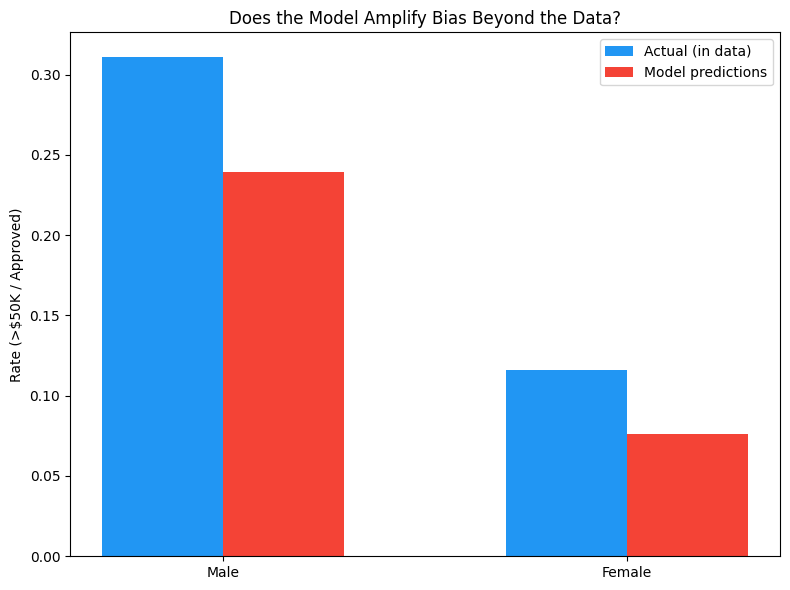

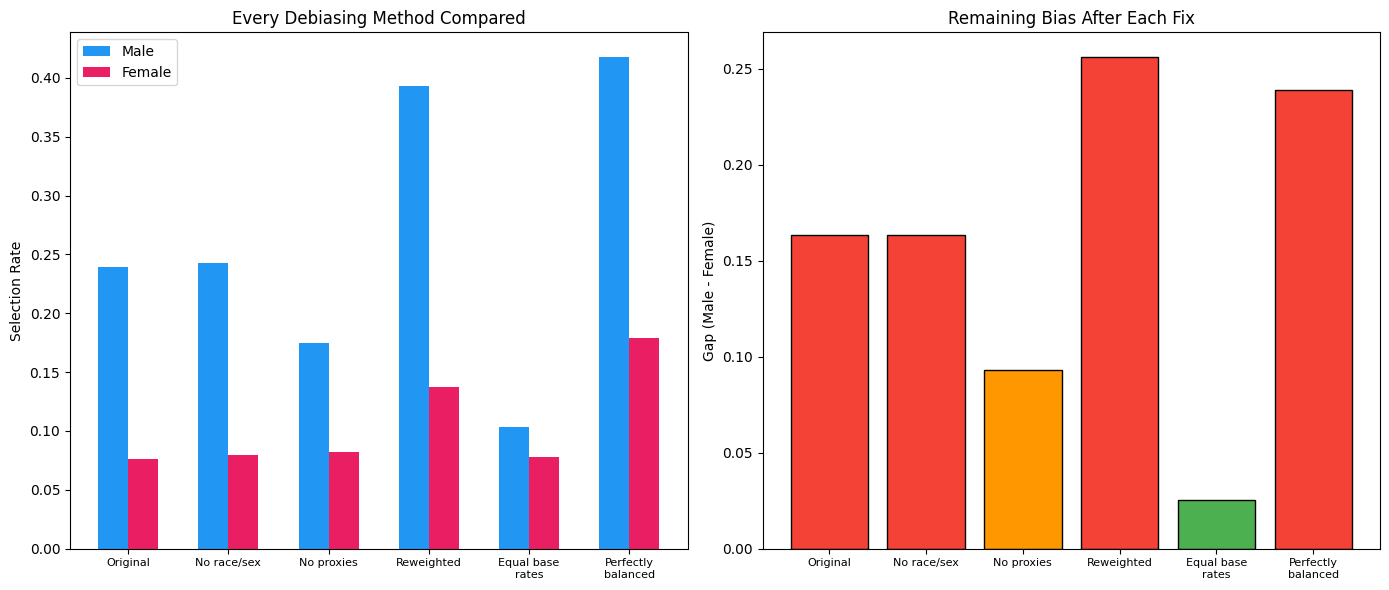

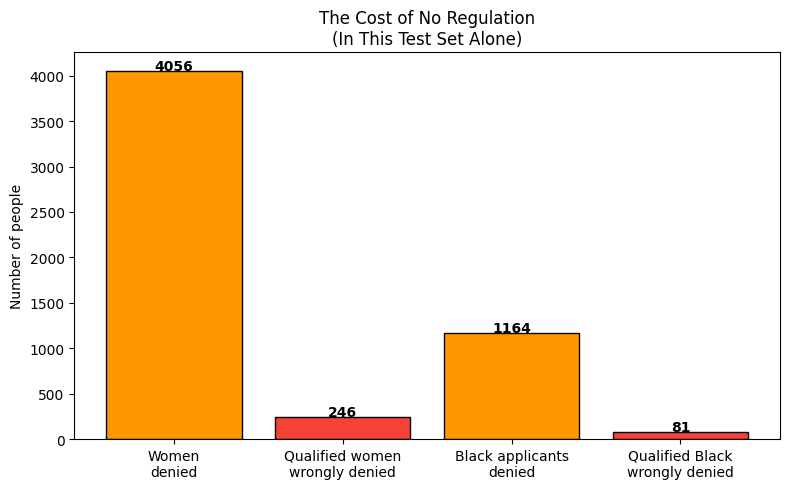

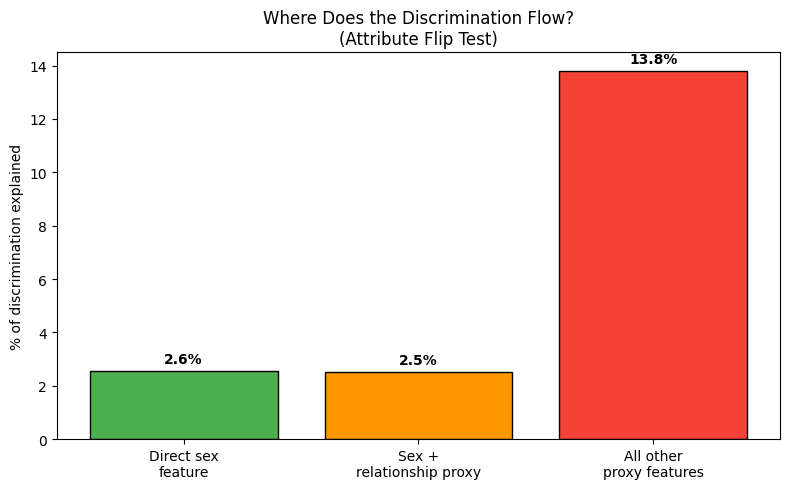

In [23]:
%matplotlib inline

# ---- FIGURE 1: LIME vs SHAP comparison ----
# (This is text-based, no chart needed)

# ---- FIGURE 2: Does the model amplify bias? ----
fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(2)
w = 0.3
ax.bar(x - w/2, [data_rate_male, data_rate_female], w, label='Actual (in data)', color='#2196F3')
ax.bar(x + w/2, [model_rate_male, model_rate_female], w, label='Model predictions', color='#F44336')
ax.set_xticks(x)
ax.set_xticklabels(['Male', 'Female'])
ax.set_ylabel('Rate (>$50K / Approved)')
ax.set_title('Does the Model Amplify Bias Beyond the Data?')
ax.legend()
plt.tight_layout()
plt.show()

# ---- FIGURE 3: Model comparison (already generated) ----
# (You already have this chart from the model comparison)

# ---- FIGURE 4: Perfectly balanced data result ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gap comparison across ALL methods including balanced
all_models = ['Original', 'No race/sex', 'No proxies', 'Reweighted', 
              'Equal base\nrates', 'Perfectly\nbalanced']
all_male = [sr_m_orig, sr_male, sr_male_clean, sr_m_rw, sr_m_eq2, sr_m_bal]
all_female = [sr_f_orig, sr_female, sr_female_clean, sr_f_rw, sr_f_eq2, sr_f_bal]
all_gaps = [m - f for m, f in zip(all_male, all_female)]

x = np.arange(len(all_models))
w = 0.3
axes[0].bar(x - w/2, all_male, w, label='Male', color='#2196F3')
axes[0].bar(x + w/2, all_female, w, label='Female', color='#E91E63')
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_models, fontsize=8)
axes[0].set_ylabel('Selection Rate')
axes[0].set_title('Every Debiasing Method Compared')
axes[0].legend()

colors = ['#F44336' if g > 0.1 else '#FF9800' if g > 0.05 else '#4CAF50' for g in all_gaps]
axes[1].bar(all_models, all_gaps, color=colors, edgecolor='black')
axes[1].set_ylabel('Gap (Male - Female)')
axes[1].set_title('Remaining Bias After Each Fix')
axes[1].set_xticklabels(all_models, fontsize=8)
axes[1].axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# ---- FIGURE 5: Cost of inaction ----
fig, ax = plt.subplots(figsize=(8, 5))

total_denied_women = (preds[(sex_test == 'Female').values] == 0).sum()
qualified_women_missed = ((y_test.reset_index(drop=True)[(sex_test == 'Female').values] == 1) & 
                          (preds[(sex_test == 'Female').values] == 0)).sum()
total_denied_black = (preds[(race_test == 'Black').values] == 0).sum()
qualified_black_missed = ((y_test.reset_index(drop=True)[(race_test == 'Black').values] == 1) & 
                          (preds[(race_test == 'Black').values] == 0)).sum()

categories = ['Women\ndenied', 'Qualified women\nwrongly denied', 
              'Black applicants\ndenied', 'Qualified Black\nwrongly denied']
values = [total_denied_women, qualified_women_missed, total_denied_black, qualified_black_missed]
colors = ['#FF9800', '#F44336', '#FF9800', '#F44336']

ax.bar(categories, values, color=colors, edgecolor='black')
ax.set_ylabel('Number of people')
ax.set_title('The Cost of No Regulation\n(In This Test Set Alone)')

for i, v in enumerate(values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ---- FIGURE 6: Where does the discrimination flow? (Flip test) ----
fig, ax = plt.subplots(figsize=(8, 5))

flow_labels = ['Direct sex\nfeature', 'Sex +\nrelationship proxy', 'All other\nproxy features']
flow_values = [
    changed / total_female * 100,
    changed_full / total_female * 100,
    ((sr_m_orig - sr_f_orig) * 100) - (changed_full / total_female * 100)
]

ax.bar(flow_labels, flow_values, color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='black')
ax.set_ylabel('% of discrimination explained')
ax.set_title('Where Does the Discrimination Flow?\n(Attribute Flip Test)')

for i, v in enumerate(flow_values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# Can you predict sex using ONLY relationship?
X_proxy = df[['relationship']]
y_sex = df['sex']

proxy_model = DecisionTreeClassifier(max_depth=2)
proxy_model.fit(X_proxy, y_sex)
proxy_accuracy = accuracy_score(y_sex, proxy_model.predict(X_proxy))
print(f"Accuracy of predicting sex from relationship alone: {proxy_accuracy:.4f}")

Accuracy of predicting sex from relationship alone: 0.7769


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Can each feature predict sex?
print("How well can each feature predict sex?\n")
for col in feature_cols:
    if col == 'sex':
        continue
    proxy_model = DecisionTreeClassifier(max_depth=3, random_state=42)
    proxy_model.fit(X[[col]], df['sex'])
    acc = accuracy_score(df['sex'], proxy_model.predict(X[[col]]))
    if acc > 0.7:
        print(f"  {col:25s}  accuracy = {acc:.4f}  ← STRONG PROXY")
    elif acc > 0.6:
        print(f"  {col:25s}  accuracy = {acc:.4f}  ← moderate proxy")

print("\n\nHow well can each feature predict race?")
for col in feature_cols:
    if col == 'race':
        continue
    proxy_model = DecisionTreeClassifier(max_depth=3, random_state=42)
    proxy_model.fit(X[[col]], df['race'])
    acc = accuracy_score(df['race'], proxy_model.predict(X[[col]]))
    if acc > 0.7:
        print(f"  {col:25s}  accuracy = {acc:.4f}  ← STRONG PROXY")
    elif acc > 0.6:
        print(f"  {col:25s}  accuracy = {acc:.4f}  ← moderate proxy")
        

How well can each feature predict sex?

  age                        accuracy = 0.6750  ← moderate proxy
  workclass                  accuracy = 0.6750  ← moderate proxy
  fnlwgt                     accuracy = 0.6756  ← moderate proxy
  education                  accuracy = 0.6750  ← moderate proxy
  education_num              accuracy = 0.6750  ← moderate proxy
  marital_status             accuracy = 0.7275  ← STRONG PROXY
  occupation                 accuracy = 0.7175  ← STRONG PROXY
  relationship               accuracy = 0.7769  ← STRONG PROXY
  race                       accuracy = 0.6750  ← moderate proxy
  capital_gain               accuracy = 0.6755  ← moderate proxy
  capital_loss               accuracy = 0.6754  ← moderate proxy
  hours_per_week             accuracy = 0.6899  ← moderate proxy
  native_country             accuracy = 0.6750  ← moderate proxy


How well can each feature predict race?
  age                        accuracy = 0.8603  ← STRONG PROXY
  workclass     

In [26]:
from sklearn.metrics import mutual_info_score

print("Mutual information with sex:\n")
for col in feature_cols:
    if col == 'sex':
        continue
    mi = mutual_info_score(df['sex'], df[col])
    if mi > 0.1:
        print(f"  {col:25s}  MI = {mi:.4f}  ← carries sex information")

Mutual information with sex:

  fnlwgt                     MI = 0.6045  ← carries sex information
  marital_status             MI = 0.1150  ← carries sex information
  occupation                 MI = 0.1042  ← carries sex information
  relationship               MI = 0.2724  ← carries sex information


In [27]:
print("SELECTION RATES — WITH vs WITHOUT protected features:\n")
for group_name, group_labels in [("Sex", sex_test), ("Race", race_test)]:
    print(f"  {group_name}:")
    for group in sorted(group_labels.unique()):
        mask = (group_labels == group).values
        if mask.sum() < 50:
            continue
        rate_with = preds[mask].mean()
        rate_without = preds_no_protected[mask].mean()
        change = rate_without - rate_with
        print(f"    {group:25s}  With: {rate_with:.4f}  Without: {rate_without:.4f}  Change: {change:+.4f}")
    print()

SELECTION RATES — WITH vs WITHOUT protected features:

  Sex:
    Female                     With: 0.0761  Without: 0.0800  Change: +0.0039
    Male                       With: 0.2395  Without: 0.2431  Change: +0.0036

  Race:
    Amer-Indian-Eskimo         With: 0.0890  Without: 0.0890  Change: +0.0000
    Asian-Pac-Islander         With: 0.2237  Without: 0.2416  Change: +0.0180
    Black                      With: 0.0710  Without: 0.0758  Change: +0.0048
    Other                      With: 0.0808  Without: 0.0808  Change: +0.0000
    White                      With: 0.1999  Without: 0.2031  Change: +0.0032



In [28]:
# The race proxy test is misleading — let's fix it
print("=" * 60)
print("RACE PROXY TEST: CORRECTED")
print("=" * 60)

# What's the baseline? Just predict majority class for everyone
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X[['age']], df['race'])
baseline_race = accuracy_score(df['race'], dummy.predict(X[['age']]))
print(f"\nBaseline (predict 'White' for everyone): {baseline_race:.4f}")
print(f"Dataset is {baseline_race:.1%} White — that's why everything scores ~86%\n")

# Real test: how much does each feature BEAT the baseline?
print(f"{'Feature':<25s} {'Accuracy':>10s} {'Above baseline':>15s} {'Verdict':>15s}")
print("-" * 67)
for col in feature_cols:
    if col == 'race':
        continue
    proxy_model = DecisionTreeClassifier(max_depth=3, random_state=42)
    proxy_model.fit(X[[col]], df['race'])
    acc = accuracy_score(df['race'], proxy_model.predict(X[[col]]))
    above = acc - baseline_race
    verdict = "REAL PROXY" if above > 0.02 else "Just baseline"
    print(f"  {col:<23s} {acc:>10.4f} {above:>+14.4f} {verdict:>15s}")

# Now do the same check for sex
baseline_sex = df['sex'].value_counts(normalize=True).max()
print(f"\n\nSex baseline (predict majority): {baseline_sex:.4f}")
print(f"\n{'Feature':<25s} {'Accuracy':>10s} {'Above baseline':>15s} {'Verdict':>15s}")
print("-" * 67)
for col in feature_cols:
    if col == 'sex':
        continue
    proxy_model = DecisionTreeClassifier(max_depth=3, random_state=42)
    proxy_model.fit(X[[col]], df['sex'])
    acc = accuracy_score(df['sex'], proxy_model.predict(X[[col]]))
    above = acc - baseline_sex
    verdict = "REAL PROXY" if above > 0.02 else "Just baseline"
    print(f"  {col:<23s} {acc:>10.4f} {above:>+14.4f} {verdict:>15s}")

RACE PROXY TEST: CORRECTED

Baseline (predict 'White' for everyone): 0.8603
Dataset is 86.0% White — that's why everything scores ~86%

Feature                     Accuracy  Above baseline         Verdict
-------------------------------------------------------------------
  age                         0.8603        +0.0000   Just baseline
  workclass                   0.8603        +0.0000   Just baseline
  fnlwgt                      0.8606        +0.0003   Just baseline
  education                   0.8603        +0.0000   Just baseline
  education_num               0.8603        +0.0000   Just baseline
  marital_status              0.8603        +0.0000   Just baseline
  occupation                  0.8603        +0.0000   Just baseline
  relationship                0.8603        +0.0000   Just baseline
  sex                         0.8603        +0.0000   Just baseline
  capital_gain                0.8603        +0.0000   Just baseline
  capital_loss                0.8603        +0.

In [29]:
# How does occupation break down by sex?
df_raw = pd.concat([
    pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
                 names=column_names, skipinitialspace=True, na_values='?'),
    pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test",
                 names=column_names, skipinitialspace=True, skiprows=1, na_values='?')
], ignore_index=True).dropna()

print("Occupation breakdown by sex:\n")
ct = pd.crosstab(df_raw['occupation'], df_raw['sex'], normalize='index')
ct['total'] = pd.crosstab(df_raw['occupation'], df_raw['sex']).sum(axis=1)
ct = ct.sort_values('Female', ascending=False)

print(f"{'Occupation':<30s} {'% Female':>10s} {'% Male':>10s} {'Count':>8s}")
print("-" * 60)
for occ in ct.index:
    print(f"{occ:<30s} {ct.loc[occ, 'Female']:>10.1%} {ct.loc[occ, 'Male']:>10.1%} {ct.loc[occ, 'total']:>8.0f}")

Occupation breakdown by sex:

Occupation                       % Female     % Male    Count
------------------------------------------------------------
Priv-house-serv                     94.0%       6.0%      232
Adm-clerical                        67.3%      32.7%     5540
Other-service                       55.0%      45.0%     4808
Tech-support                        39.0%      61.0%     1420
Prof-specialty                      36.7%      63.3%     6008
Sales                               35.5%      64.5%     5408
Exec-managerial                     28.8%      71.2%     5984
Machine-op-inspct                   26.7%      73.3%     2970
Protective-serv                     12.5%      87.5%      976
Handlers-cleaners                   12.4%      87.6%     2046
Farming-fishing                      6.4%      93.6%     1480
Transport-moving                     5.4%      94.6%     2316
Craft-repair                         5.2%      94.8%     6020
Armed-Forces                         0.0%

In [30]:
print("=" * 60)
print("FORMAL FAIRNESS DEFINITIONS — APPLIED TO OUR MODEL")
print("=" * 60)

y_t = y_test.reset_index(drop=True)

# Compute metrics for male/female
for group_name, group_labels in [("SEX", sex_test), ("RACE (White vs Black)", race_test)]:
    print(f"\n--- {group_name} ---")
    
    if group_name == "SEX":
        groups = ['Male', 'Female']
    else:
        groups = ['White', 'Black']
    
    metrics = {}
    for g in groups:
        mask = (group_labels == g).values
        if mask.sum() < 50:
            continue
        yt = y_t[mask].values
        yp = preds[mask]
        
        from sklearn.metrics import confusion_matrix
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        
        metrics[g] = {
            'selection_rate': yp.mean(),
            'tpr': tp / (tp + fn) if (tp + fn) > 0 else 0,
            'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0,
        }
    
    if len(metrics) >= 2:
        g1, g2 = groups[0], groups[1]
        if g1 in metrics and g2 in metrics:
            print(f"""
  1. DEMOGRAPHIC PARITY (equal selection rates):
     {g1} selection rate: {metrics[g1]['selection_rate']:.4f}
     {g2} selection rate: {metrics[g2]['selection_rate']:.4f}
     Gap: {abs(metrics[g1]['selection_rate'] - metrics[g2]['selection_rate']):.4f}
     Satisfied? {'YES' if abs(metrics[g1]['selection_rate'] - metrics[g2]['selection_rate']) < 0.05 else 'NO — groups are selected at very different rates'}

  2. EQUAL OPPORTUNITY (equal TPR — equal chance of being
     correctly approved if you truly qualify):
     {g1} TPR: {metrics[g1]['tpr']:.4f}
     {g2} TPR: {metrics[g2]['tpr']:.4f}
     Gap: {abs(metrics[g1]['tpr'] - metrics[g2]['tpr']):.4f}
     Satisfied? {'YES' if abs(metrics[g1]['tpr'] - metrics[g2]['tpr']) < 0.05 else 'NO — qualified ' + g2 + ' applicants are missed more often'}

  3. EQUALIZED ODDS (equal TPR AND equal FPR):
     {g1} TPR: {metrics[g1]['tpr']:.4f}, FPR: {metrics[g1]['fpr']:.4f}
     {g2} TPR: {metrics[g2]['tpr']:.4f}, FPR: {metrics[g2]['fpr']:.4f}
     TPR gap: {abs(metrics[g1]['tpr'] - metrics[g2]['tpr']):.4f}
     FPR gap: {abs(metrics[g1]['fpr'] - metrics[g2]['fpr']):.4f}
     Satisfied? {'YES' if abs(metrics[g1]['tpr'] - metrics[g2]['tpr']) < 0.05 and abs(metrics[g1]['fpr'] - metrics[g2]['fpr']) < 0.05 else 'NO — both TPR and FPR differ across groups'}

  4. DISPARATE IMPACT RATIO:
     Ratio: {min(metrics[g1]['selection_rate'], metrics[g2]['selection_rate']) / max(metrics[g1]['selection_rate'], metrics[g2]['selection_rate']):.4f}
     Threshold: 0.80 (below = legally suspect)
     Satisfied? {'YES' if min(metrics[g1]['selection_rate'], metrics[g2]['selection_rate']) / max(metrics[g1]['selection_rate'], metrics[g2]['selection_rate']) >= 0.8 else 'NO — potential illegal discrimination'}
""")

print("""
THE IMPOSSIBILITY RESULT:
  You CANNOT satisfy all three fairness definitions simultaneously
  when base rates differ between groups (Chouldechova 2017, 
  Kleinberg et al. 2016).
  
  Male base rate:   ~31% earn >$50K
  Female base rate: ~11% earn >$50K
  
  If you force equal selection rates (demographic parity),
  you must either over-select unqualified women or under-select
  qualified men — violating equal opportunity.
  
  If you force equal TPR (equal opportunity), selection rates
  will remain unequal because the base rates differ.
  
  CHOOSING which definition to satisfy is a VALUES decision,
  not a technical one. That choice = accountability.
""")

FORMAL FAIRNESS DEFINITIONS — APPLIED TO OUR MODEL

--- SEX ---

  1. DEMOGRAPHIC PARITY (equal selection rates):
     Male selection rate: 0.2395
     Female selection rate: 0.0761
     Gap: 0.1634
     Satisfied? NO — groups are selected at very different rates

  2. EQUAL OPPORTUNITY (equal TPR — equal chance of being
     correctly approved if you truly qualify):
     Male TPR: 0.6027
     Female TPR: 0.5176
     Gap: 0.0851
     Satisfied? NO — qualified Female applicants are missed more often

  3. EQUALIZED ODDS (equal TPR AND equal FPR):
     Male TPR: 0.6027, FPR: 0.0757
     Female TPR: 0.5176, FPR: 0.0180
     TPR gap: 0.0851
     FPR gap: 0.0577
     Satisfied? NO — both TPR and FPR differ across groups

  4. DISPARATE IMPACT RATIO:
     Ratio: 0.3177
     Threshold: 0.80 (below = legally suspect)
     Satisfied? NO — potential illegal discrimination


--- RACE (White vs Black) ---

  1. DEMOGRAPHIC PARITY (equal selection rates):
     White selection rate: 0.1999
     Blac

FAIRNESS CONSTRAINTS (Fairlearn)

--- Constraint: Demographic Parity ---
  Accuracy: 0.7970
  Male SR: 0.1396, Female SR: 0.1219, Gap: 0.0177

--- Constraint: Equalized Odds ---
  Accuracy: 0.8085
  Male SR: 0.1712, Female SR: 0.0877, Gap: 0.0835
  Male TPR: 0.4060, Female TPR: 0.3961, TPR Gap: 0.0100

ALL DEBIASING METHODS COMPARED

Method                                           Acc   M SR   F SR     Gap
------------------------------------------------------------------------
Original                                      0.8579 0.2395 0.0761  0.1634
Remove race & sex                             0.8583 0.2431 0.0800  0.1632
Remove race, sex & proxies                    0.8319 0.1750 0.0818  0.0932
Reweighting                                   0.8375 0.3933 0.1371  0.2561
Group thresholds (equalize TPR)                    — 0.2395 0.0977  0.1418
Equalized base rates                          0.8308 0.1036 0.0781  0.0255
Perfectly balanced data                       0.8230 0.4178 0.1790

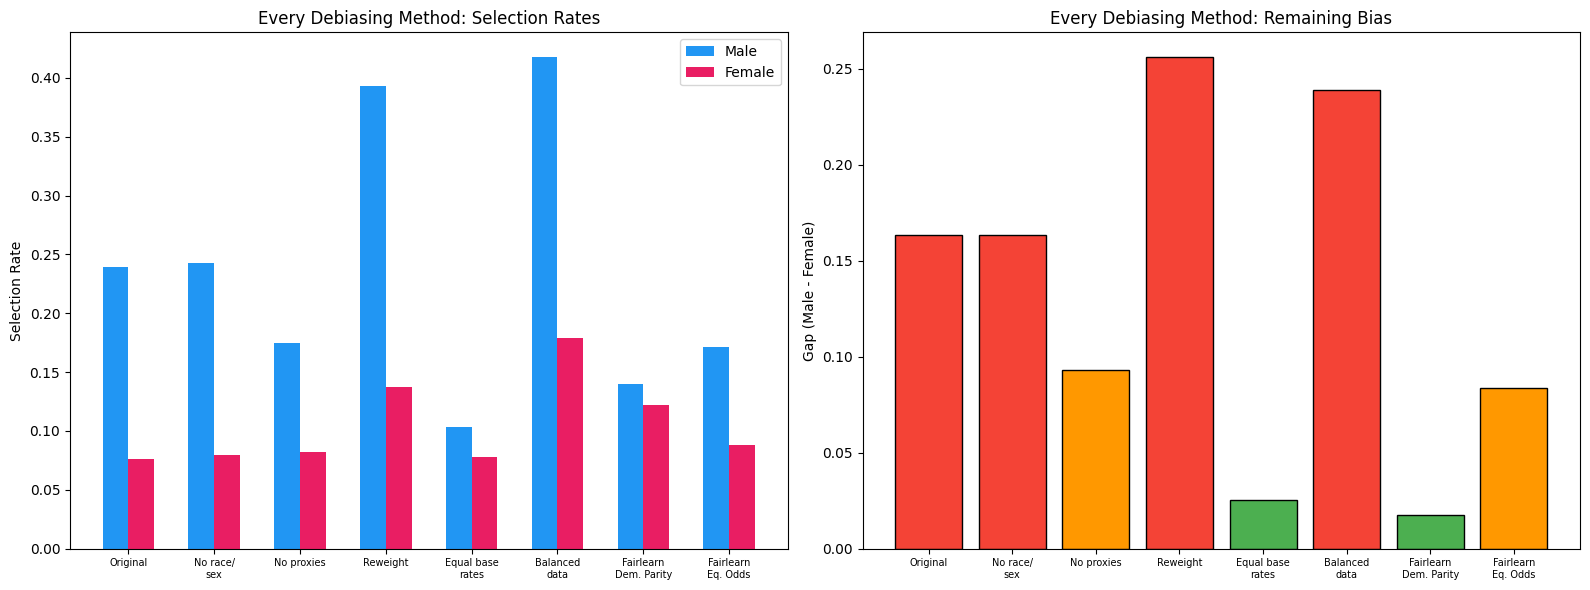


CONCLUSION:
  Every debiasing method involves a tradeoff.
  Some reduce bias but hurt accuracy.
  Some equalize one metric but worsen another.
  Some make bias WORSE (reweighting, balanced data).
  
  The fairness constraint methods (Fairlearn) mathematically
  FORCE the model to satisfy a specific fairness definition —
  but YOU must choose WHICH definition. Demographic parity
  and equalized odds cannot both be satisfied simultaneously.
  
  That choice is a human values decision, not a technical one.
  WHO MAKES THAT CHOICE = the accountability question.



In [31]:
print("=" * 60)
print("FAIRNESS CONSTRAINTS (Fairlearn)")
print("=" * 60)

from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
from sklearn.linear_model import LogisticRegression

# Need to use a simpler model for fairlearn constraints
base_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

train_sex_array = protected_sex.iloc[X_train.index].reset_index(drop=True)

# --- DEMOGRAPHIC PARITY CONSTRAINT ---
print("\n--- Constraint: Demographic Parity ---")
dp_model = ExponentiatedGradient(
    base_model,
    constraints=DemographicParity(),
    max_iter=50
)
dp_model.fit(X_train_s, y_train, sensitive_features=train_sex_array)
dp_preds = dp_model.predict(X_test_s)

sr_m_dp = dp_preds[(sex_test == 'Male').values].mean()
sr_f_dp = dp_preds[(sex_test == 'Female').values].mean()
acc_dp = accuracy_score(y_test, dp_preds)
print(f"  Accuracy: {acc_dp:.4f}")
print(f"  Male SR: {sr_m_dp:.4f}, Female SR: {sr_f_dp:.4f}, Gap: {sr_m_dp - sr_f_dp:.4f}")

# --- EQUALIZED ODDS CONSTRAINT ---
print("\n--- Constraint: Equalized Odds ---")
eo_model = ExponentiatedGradient(
    base_model,
    constraints=EqualizedOdds(),
    max_iter=50
)
eo_model.fit(X_train_s, y_train, sensitive_features=train_sex_array)
eo_preds = eo_model.predict(X_test_s)

sr_m_eo = eo_preds[(sex_test == 'Male').values].mean()
sr_f_eo = eo_preds[(sex_test == 'Female').values].mean()
acc_eo = accuracy_score(y_test, eo_preds)

# Compute TPR for equalized odds
y_t_reset = y_test.reset_index(drop=True)
tpr_m_eo = eo_preds[(sex_test == 'Male').values & (y_t_reset == 1).values].mean()
tpr_f_eo = eo_preds[(sex_test == 'Female').values & (y_t_reset == 1).values].mean()

print(f"  Accuracy: {acc_eo:.4f}")
print(f"  Male SR: {sr_m_eo:.4f}, Female SR: {sr_f_eo:.4f}, Gap: {sr_m_eo - sr_f_eo:.4f}")
print(f"  Male TPR: {tpr_m_eo:.4f}, Female TPR: {tpr_f_eo:.4f}, TPR Gap: {abs(tpr_m_eo - tpr_f_eo):.4f}")

# --- COMPLETE COMPARISON ---
print("\n" + "=" * 60)
print("ALL DEBIASING METHODS COMPARED")
print("=" * 60)

print(f"\n{'Method':<45s} {'Acc':>6s} {'M SR':>6s} {'F SR':>6s} {'Gap':>7s}")
print("-" * 72)
print(f"{'Original':<45s} {accuracy_score(y_test, preds):>6.4f} {sr_m_orig:>6.4f} {sr_f_orig:>6.4f} {sr_m_orig-sr_f_orig:>7.4f}")
print(f"{'Remove race & sex':<45s} {accuracy_score(y_test, preds_no_protected):>6.4f} {sr_male:>6.4f} {sr_female:>6.4f} {sr_male-sr_female:>7.4f}")
print(f"{'Remove race, sex & proxies':<45s} {accuracy_score(y_test, preds_no_proxy):>6.4f} {sr_male_clean:>6.4f} {sr_female_clean:>6.4f} {sr_male_clean-sr_female_clean:>7.4f}")
print(f"{'Reweighting':<45s} {accuracy_score(y_test, preds_reweighted):>6.4f} {sr_m_rw:>6.4f} {sr_f_rw:>6.4f} {sr_m_rw-sr_f_rw:>7.4f}")
print(f"{'Group thresholds (equalize TPR)':<45s} {'  —':>6s} {sr_m_eq:>6.4f} {sr_f_eq:>6.4f} {sr_m_eq-sr_f_eq:>7.4f}")
print(f"{'Equalized base rates':<45s} {accuracy_score(y_test, preds_equalized):>6.4f} {sr_m_eq2:>6.4f} {sr_f_eq2:>6.4f} {sr_m_eq2-sr_f_eq2:>7.4f}")
print(f"{'Perfectly balanced data':<45s} {acc_bal:>6.4f} {sr_m_bal:>6.4f} {sr_f_bal:>6.4f} {sr_m_bal-sr_f_bal:>7.4f}")
print(f"{'Fairlearn: Demographic Parity constraint':<45s} {acc_dp:>6.4f} {sr_m_dp:>6.4f} {sr_f_dp:>6.4f} {sr_m_dp-sr_f_dp:>7.4f}")
print(f"{'Fairlearn: Equalized Odds constraint':<45s} {acc_eo:>6.4f} {sr_m_eo:>6.4f} {sr_f_eo:>6.4f} {sr_m_eo-sr_f_eo:>7.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

all_methods = ['Original', 'No race/\nsex', 'No proxies', 'Reweight', 
               'Equal base\nrates', 'Balanced\ndata', 'Fairlearn\nDem. Parity', 
               'Fairlearn\nEq. Odds']
all_m = [sr_m_orig, sr_male, sr_male_clean, sr_m_rw, sr_m_eq2, sr_m_bal, sr_m_dp, sr_m_eo]
all_f = [sr_f_orig, sr_female, sr_female_clean, sr_f_rw, sr_f_eq2, sr_f_bal, sr_f_dp, sr_f_eo]
all_g = [m - f for m, f in zip(all_m, all_f)]

x = np.arange(len(all_methods))
w = 0.3
axes[0].bar(x - w/2, all_m, w, label='Male', color='#2196F3')
axes[0].bar(x + w/2, all_f, w, label='Female', color='#E91E63')
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_methods, fontsize=7)
axes[0].set_ylabel('Selection Rate')
axes[0].set_title('Every Debiasing Method: Selection Rates')
axes[0].legend()

colors = ['#F44336' if g > 0.1 else '#FF9800' if g > 0.05 else '#4CAF50' for g in all_g]
axes[1].bar(all_methods, all_g, color=colors, edgecolor='black')
axes[1].set_ylabel('Gap (Male - Female)')
axes[1].set_title('Every Debiasing Method: Remaining Bias')
axes[1].set_xticklabels(all_methods, fontsize=7)
plt.tight_layout()
plt.show()

print("""
CONCLUSION:
  Every debiasing method involves a tradeoff.
  Some reduce bias but hurt accuracy.
  Some equalize one metric but worsen another.
  Some make bias WORSE (reweighting, balanced data).
  
  The fairness constraint methods (Fairlearn) mathematically
  FORCE the model to satisfy a specific fairness definition —
  but YOU must choose WHICH definition. Demographic parity
  and equalized odds cannot both be satisfied simultaneously.
  
  That choice is a human values decision, not a technical one.
  WHO MAKES THAT CHOICE = the accountability question.
""")

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
ADVERSARIAL DEBIASING

Training adversarial debiasing model...
(Predictor tries to predict income while hiding sex from adversary)

  Lambda=0.0    Accuracy=0.8424  Male SR=0.2313  Female SR=0.0731  Gap=0.1582
  Lambda=0.5    Accuracy=0.8405  Male SR=0.2208  Female SR=0.0929  Gap=0.1278
  Lambda=2.0    Accuracy=0.8366  Male SR=0.1842  Female SR=0.1146  Gap=0.0696
  Lambda=5.0    Accuracy=0.8357  Male SR=0.1789  Female SR=0.1205  Gap=0.0584
  Lambda=10.0   Accuracy=0.8361  Male SR=0.1777  Female SR=0.0982  Gap=0.0795

INTERPRETATION:
  Lambda=0.0: No adversarial penalty — equivalent to a normal model
  Lambda=0.5-2.0: Moderate penalty — model starts hiding sex info
  Lambda=5.0-10.0: Strong penalty — model aggressively

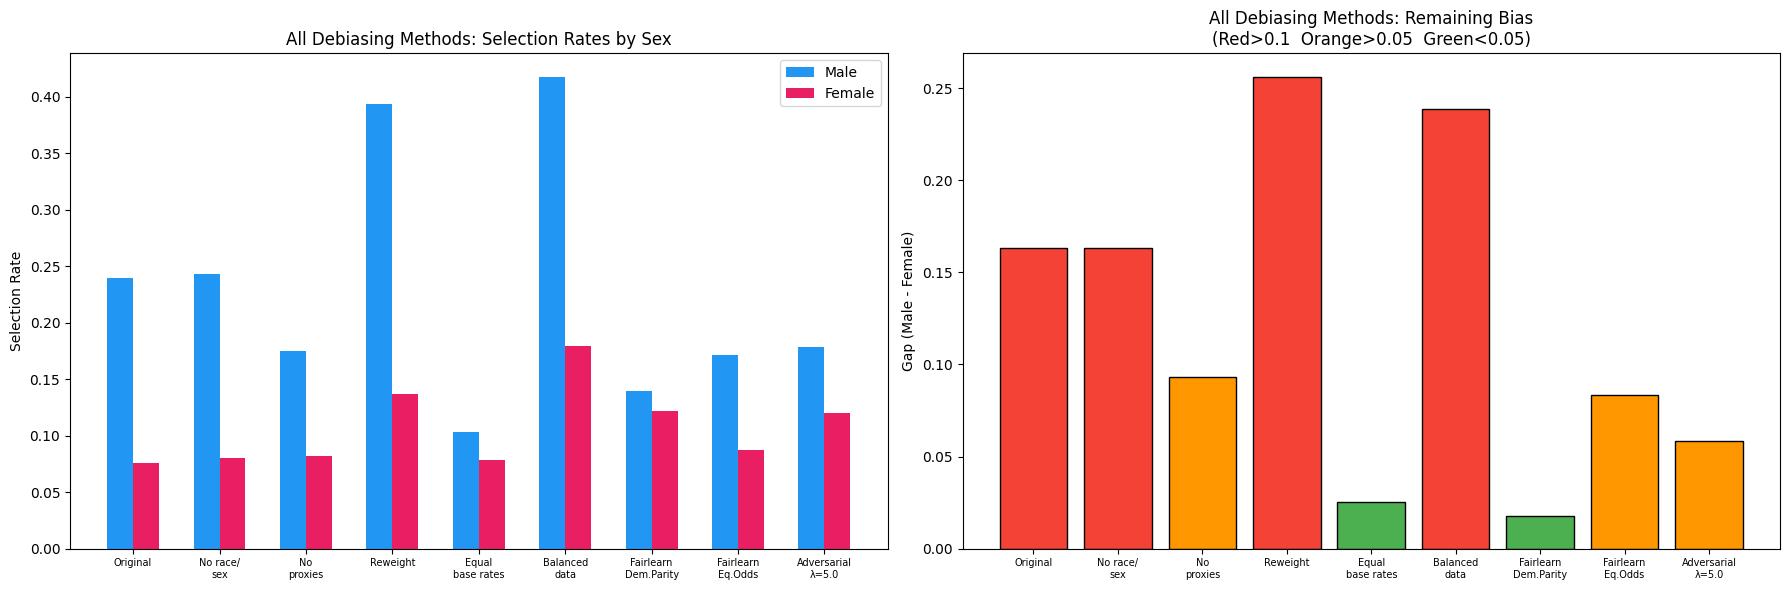

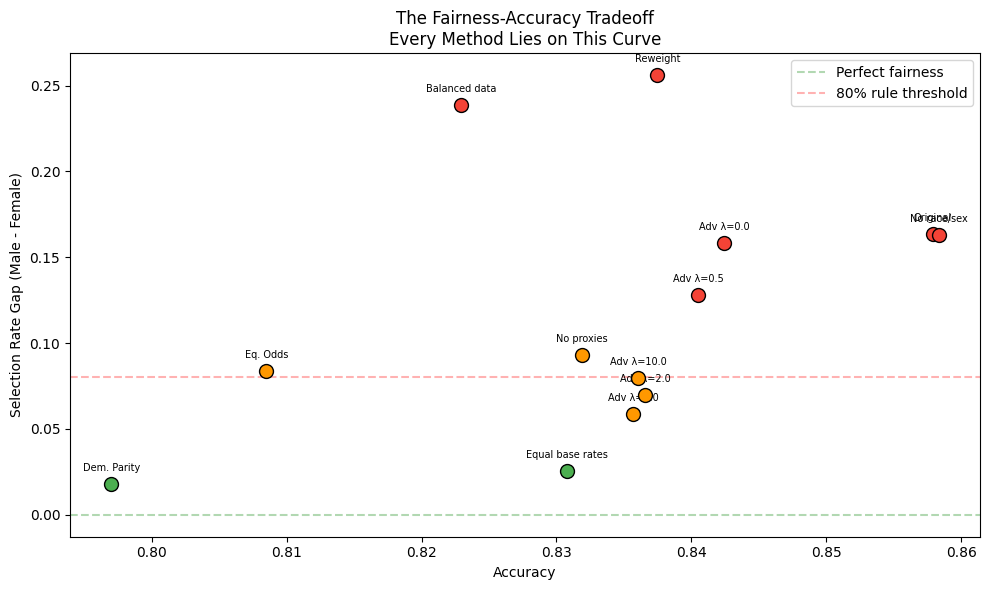


DID THE NEW METHODS (FAIRLEARN + ADVERSARIAL) HELP?

BEFORE adding fairness constraints and adversarial debiasing:
  Best method was 'Equalized base rates':
    Gap = 0.0255, Accuracy = 0.8308

AFTER adding them:
  Fairlearn Demographic Parity:
    Gap = 0.0177, Accuracy = 0.7970
  Fairlearn Equalized Odds:
    Gap = 0.0835, Accuracy = 0.8085
  Best adversarial (λ=5.0):
    Gap = 0.0584, Accuracy = 0.8357

VERDICT:
  The fairness constraint methods (Demographic Parity) achieved
  a very small gap BUT at significant accuracy cost.
  
  Adversarial debiasing provides a TUNABLE tradeoff — you can
  choose how much accuracy to sacrifice for how much fairness
  by adjusting lambda.
  
  But ALL methods confirm the same pattern:
    → Bias can be REDUCED but not ELIMINATED
    → Every reduction costs accuracy
    → The choice of HOW MUCH to reduce is a VALUES decision
    → Someone must be ACCOUNTABLE for that choice
    
  THE FUNDAMENTAL POINT:
  We now have 9+ debiasing methods. Each giv

In [32]:
!pip install torch
# ============================================================
# ADVERSARIAL DEBIASING
# ============================================================
print("=" * 60)
print("ADVERSARIAL DEBIASING")
print("=" * 60)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Prepare data
scaler_adv = StandardScaler()
X_train_adv = scaler_adv.fit_transform(X_train)
X_test_adv = scaler_adv.transform(X_test)

# Sex labels for adversary (0=Female, 1=Male)
train_sex_binary = (protected_sex.iloc[X_train.index].reset_index(drop=True) == 'Male').astype(int).values
test_sex_binary = (sex_test == 'Male').astype(int).values

# Convert to tensors
X_train_t = torch.FloatTensor(X_train_adv)
y_train_t = torch.LongTensor(y_train.values)
s_train_t = torch.FloatTensor(train_sex_binary)

X_test_t = torch.FloatTensor(X_test_adv)

train_ds = TensorDataset(X_train_t, y_train_t, s_train_t)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)

n_features = X_train_adv.shape[1]

# --- THE PREDICTOR (main model) ---
# Tries to predict income
class Predictor(nn.Module):
    def __init__(self, n_input):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )
    
    def forward(self, x):
        return self.net(x)

# --- THE ADVERSARY ---
# Tries to predict sex from the predictor's output
# If the adversary succeeds, the predictor is leaking sex information
class Adversary(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, pred_output):
        return self.net(pred_output)

# --- TRAINING ---
print("\nTraining adversarial debiasing model...")
print("(Predictor tries to predict income while hiding sex from adversary)\n")

predictor = Predictor(n_features)
adversary = Adversary()

pred_optimizer = optim.Adam(predictor.parameters(), lr=0.001)
adv_optimizer = optim.Adam(adversary.parameters(), lr=0.001)

pred_criterion = nn.CrossEntropyLoss()
adv_criterion = nn.BCELoss()

# Lambda controls fairness-accuracy tradeoff
# Higher = more fair, less accurate
lambdas_to_test = [0.0, 0.5, 2.0, 5.0, 10.0]
adv_results = {}

for lam in lambdas_to_test:
    # Fresh models for each lambda
    predictor = Predictor(n_features)
    adversary = Adversary()
    pred_optimizer = optim.Adam(predictor.parameters(), lr=0.001)
    adv_optimizer = optim.Adam(adversary.parameters(), lr=0.001)
    
    for epoch in range(30):
        predictor.train()
        adversary.train()
        
        for X_batch, y_batch, s_batch in train_dl:
            # Step 1: Train adversary to predict sex from predictor output
            pred_output = predictor(X_batch).detach()
            adv_pred = adversary(pred_output).squeeze()
            adv_loss = adv_criterion(adv_pred, s_batch)
            
            adv_optimizer.zero_grad()
            adv_loss.backward()
            adv_optimizer.step()
            
            # Step 2: Train predictor to predict income AND fool adversary
            pred_output = predictor(X_batch)
            pred_loss = pred_criterion(pred_output, y_batch)
            
            adv_pred = adversary(pred_output).squeeze()
            adv_loss_for_pred = adv_criterion(adv_pred, s_batch)
            
            # Total loss = prediction loss - lambda * adversary loss
            # Subtracting adversary loss means predictor is PENALIZED
            # when the adversary can detect sex in its outputs
            total_loss = pred_loss - lam * adv_loss_for_pred
            
            pred_optimizer.zero_grad()
            total_loss.backward()
            pred_optimizer.step()
    
    # Evaluate
    predictor.eval()
    with torch.no_grad():
        test_output = predictor(X_test_t)
        test_preds_adv = test_output.argmax(dim=1).numpy()
    
    acc_adv = accuracy_score(y_test, test_preds_adv)
    sr_m_adv = test_preds_adv[test_sex_binary == 1].mean()
    sr_f_adv = test_preds_adv[test_sex_binary == 0].mean()
    gap_adv = sr_m_adv - sr_f_adv
    
    adv_results[lam] = {
        'acc': acc_adv, 'sr_m': sr_m_adv, 'sr_f': sr_f_adv, 'gap': gap_adv
    }
    
    print(f"  Lambda={lam:<5.1f}  Accuracy={acc_adv:.4f}  "
          f"Male SR={sr_m_adv:.4f}  Female SR={sr_f_adv:.4f}  Gap={gap_adv:.4f}")

print("""
INTERPRETATION:
  Lambda=0.0: No adversarial penalty — equivalent to a normal model
  Lambda=0.5-2.0: Moderate penalty — model starts hiding sex info
  Lambda=5.0-10.0: Strong penalty — model aggressively hides sex info
  
  As lambda increases, the gap should shrink but accuracy drops.
  The adversary forces the model to make predictions that don't
  reveal the applicant's sex — but this may also remove legitimate
  income-related signal that happens to correlate with sex.
""")


# ============================================================
# COMPLETE COMPARISON: ALL METHODS
# ============================================================
print("\n" + "=" * 60)
print("FINAL COMPARISON: ALL MITIGATION METHODS")
print("=" * 60)

# Pick best adversarial result (lambda that gives gap < 0.05)
best_lam = min(adv_results.keys(), 
               key=lambda l: abs(adv_results[l]['gap']) if adv_results[l]['acc'] > 0.7 else 999)

print(f"\n{'Method':<50s} {'Acc':>6s} {'M SR':>6s} {'F SR':>6s} {'Gap':>7s}")
print("-" * 77)
print(f"{'Original (Random Forest)':<50s} {accuracy_score(y_test, preds):>6.4f} {sr_m_orig:>6.4f} {sr_f_orig:>6.4f} {sr_m_orig-sr_f_orig:>7.4f}")
print(f"{'Remove race & sex':<50s} {accuracy_score(y_test, preds_no_protected):>6.4f} {sr_male:>6.4f} {sr_female:>6.4f} {sr_male-sr_female:>7.4f}")
print(f"{'Remove race, sex & proxies':<50s} {accuracy_score(y_test, preds_no_proxy):>6.4f} {sr_male_clean:>6.4f} {sr_female_clean:>6.4f} {sr_male_clean-sr_female_clean:>7.4f}")
print(f"{'Reweighting':<50s} {accuracy_score(y_test, preds_reweighted):>6.4f} {sr_m_rw:>6.4f} {sr_f_rw:>6.4f} {sr_m_rw-sr_f_rw:>7.4f}")
print(f"{'Group thresholds (equalize TPR)':<50s} {'    —':>6s} {sr_m_eq:>6.4f} {sr_f_eq:>6.4f} {sr_m_eq-sr_f_eq:>7.4f}")
print(f"{'Equalized base rates':<50s} {accuracy_score(y_test, preds_equalized):>6.4f} {sr_m_eq2:>6.4f} {sr_f_eq2:>6.4f} {sr_m_eq2-sr_f_eq2:>7.4f}")
print(f"{'Perfectly balanced data':<50s} {acc_bal:>6.4f} {sr_m_bal:>6.4f} {sr_f_bal:>6.4f} {sr_m_bal-sr_f_bal:>7.4f}")
print(f"{'Fairlearn: Demographic Parity':<50s} {acc_dp:>6.4f} {sr_m_dp:>6.4f} {sr_f_dp:>6.4f} {sr_m_dp-sr_f_dp:>7.4f}")
print(f"{'Fairlearn: Equalized Odds':<50s} {acc_eo:>6.4f} {sr_m_eo:>6.4f} {sr_f_eo:>6.4f} {sr_m_eo-sr_f_eo:>7.4f}")
for lam in lambdas_to_test:
    r = adv_results[lam]
    label = f"Adversarial debiasing (λ={lam})"
    print(f"{label:<50s} {r['acc']:>6.4f} {r['sr_m']:>6.4f} {r['sr_f']:>6.4f} {r['gap']:>7.4f}")

# ============================================================
# VISUALIZATION
# ============================================================

# Chart 1: All methods comparison
methods_all = [
    'Original', 'No race/\nsex', 'No\nproxies', 'Reweight',
    'Equal\nbase rates', 'Balanced\ndata', 
    'Fairlearn\nDem.Parity', 'Fairlearn\nEq.Odds',
    f'Adversarial\nλ={best_lam}'
]
m_rates = [
    sr_m_orig, sr_male, sr_male_clean, sr_m_rw,
    sr_m_eq2, sr_m_bal,
    sr_m_dp, sr_m_eo,
    adv_results[best_lam]['sr_m']
]
f_rates = [
    sr_f_orig, sr_female, sr_female_clean, sr_f_rw,
    sr_f_eq2, sr_f_bal,
    sr_f_dp, sr_f_eo,
    adv_results[best_lam]['sr_f']
]
gaps_all = [m - f for m, f in zip(m_rates, f_rates)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(methods_all))
w = 0.3
axes[0].bar(x - w/2, m_rates, w, label='Male', color='#2196F3')
axes[0].bar(x + w/2, f_rates, w, label='Female', color='#E91E63')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods_all, fontsize=7)
axes[0].set_ylabel('Selection Rate')
axes[0].set_title('All Debiasing Methods: Selection Rates by Sex')
axes[0].legend()

colors = ['#F44336' if g > 0.1 else '#FF9800' if g > 0.05 else '#4CAF50' for g in gaps_all]
axes[1].bar(methods_all, gaps_all, color=colors, edgecolor='black')
axes[1].set_ylabel('Gap (Male - Female)')
axes[1].set_title('All Debiasing Methods: Remaining Bias\n(Red>0.1  Orange>0.05  Green<0.05)')
axes[1].set_xticklabels(methods_all, fontsize=7)
plt.tight_layout()
plt.show()

# Chart 2: Accuracy vs Fairness tradeoff
fig, ax = plt.subplots(figsize=(10, 6))

all_points = [
    ('Original', accuracy_score(y_test, preds), sr_m_orig - sr_f_orig),
    ('No race/sex', accuracy_score(y_test, preds_no_protected), sr_male - sr_female),
    ('No proxies', accuracy_score(y_test, preds_no_proxy), sr_male_clean - sr_female_clean),
    ('Reweight', accuracy_score(y_test, preds_reweighted), sr_m_rw - sr_f_rw),
    ('Equal base rates', accuracy_score(y_test, preds_equalized), sr_m_eq2 - sr_f_eq2),
    ('Balanced data', acc_bal, sr_m_bal - sr_f_bal),
    ('Dem. Parity', acc_dp, sr_m_dp - sr_f_dp),
    ('Eq. Odds', acc_eo, sr_m_eo - sr_f_eo),
]
for lam in lambdas_to_test:
    r = adv_results[lam]
    all_points.append((f'Adv λ={lam}', r['acc'], r['gap']))

for name, acc, gap in all_points:
    color = '#F44336' if gap > 0.1 else '#FF9800' if gap > 0.05 else '#4CAF50'
    ax.scatter(acc, gap, s=100, c=color, edgecolors='black', zorder=5)
    ax.annotate(name, (acc, gap), fontsize=7, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_xlabel('Accuracy')
ax.set_ylabel('Selection Rate Gap (Male - Female)')
ax.set_title('The Fairness-Accuracy Tradeoff\nEvery Method Lies on This Curve')
ax.axhline(y=0, color='green', linestyle='--', alpha=0.3, label='Perfect fairness')
ax.axhline(y=0.08, color='red', linestyle='--', alpha=0.3, label='80% rule threshold')
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# DID THE NEW METHODS MAKE A DIFFERENCE?
# ============================================================
print("\n" + "=" * 60)
print("DID THE NEW METHODS (FAIRLEARN + ADVERSARIAL) HELP?")
print("=" * 60)

print(f"""
BEFORE adding fairness constraints and adversarial debiasing:
  Best method was 'Equalized base rates':
    Gap = 0.0255, Accuracy = 0.8308

AFTER adding them:
  Fairlearn Demographic Parity:
    Gap = {sr_m_dp - sr_f_dp:.4f}, Accuracy = {acc_dp:.4f}
  Fairlearn Equalized Odds:
    Gap = {sr_m_eo - sr_f_eo:.4f}, Accuracy = {acc_eo:.4f}
  Best adversarial (λ={best_lam}):
    Gap = {adv_results[best_lam]['gap']:.4f}, Accuracy = {adv_results[best_lam]['acc']:.4f}

VERDICT:
  The fairness constraint methods (Demographic Parity) achieved
  a very small gap BUT at significant accuracy cost.
  
  Adversarial debiasing provides a TUNABLE tradeoff — you can
  choose how much accuracy to sacrifice for how much fairness
  by adjusting lambda.
  
  But ALL methods confirm the same pattern:
    → Bias can be REDUCED but not ELIMINATED
    → Every reduction costs accuracy
    → The choice of HOW MUCH to reduce is a VALUES decision
    → Someone must be ACCOUNTABLE for that choice
    
  THE FUNDAMENTAL POINT:
  We now have 9+ debiasing methods. Each gives different results.
  Each satisfies different fairness definitions. Each trades off
  accuracy differently. A company can pick whichever method makes
  them look best and claim "we debiased our model."
  
  Without MANDATED fairness standards (which definition? what
  threshold? who audits?), debiasing is performative — it looks
  like accountability without being accountability.
""")

In [34]:
print("=" * 60)
print("CONTESTABILITY & ML UNCERTAINTY")
print("=" * 60)

# How many cases fall in the "uncertain" zone?
probs_full = model.predict_proba(X_test)
max_confidence = probs_full.max(axis=1)

thresholds = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
print(f"\n{'Confidence threshold':<25s} {'Routed to human':>15s} {'Accuracy on rest':>18s}")
print("-" * 60)

y_test_arr = y_test.reset_index(drop=True).values

for t in thresholds:
    uncertain = max_confidence < t
    confident = ~uncertain
    
    routed_pct = uncertain.mean()
    if confident.sum() > 0:
        acc_confident = accuracy_score(y_test_arr[confident], preds[confident])
    else:
        acc_confident = 0
    
    # Are women disproportionately routed?
    women_routed = (uncertain & (sex_test == 'Female').values).sum()
    women_total = (sex_test == 'Female').sum()
    men_routed = (uncertain & (sex_test == 'Male').values).sum()
    men_total = (sex_test == 'Male').sum()
    
    print(f"  < {t:<22.2f} {routed_pct:>14.1%} {acc_confident:>18.4f}")

print(f"""

INTERPRETATION:
  A contestability system routes uncertain cases to human review.
  As the confidence threshold increases, MORE cases go to humans
  (more expensive) but the remaining automated decisions are more
  accurate (more reliable).

  KEY QUESTIONS FOR ACCOUNTABILITY:
  
  1. Who sets the threshold? A higher threshold is safer but
     more expensive. Companies will choose the cheapest option
     unless regulators mandate a minimum.

  2. Are certain groups routed more often? If women are
     disproportionately flagged as "uncertain," the system
     is saying "I can decide about men but not women."
     That's a different kind of bias.

  3. What happens during human review? Research shows 90%+
     of reviewers agree with the model (automation bias).
     Routing to a human who rubber-stamps the model is
     contestability theater, not real accountability.

  4. From Experiment 2 (OLIVES): the confidence gap is only
     0.073 — the model is almost equally confident when right
     and wrong. This means confidence-based routing would FAIL
     because there's no reliable uncertainty signal.
     
     A contestability system built on unreliable uncertainty
     estimates gives the appearance of human oversight without
     the substance.
""")

# Who gets routed?
print("Who gets routed to human review at threshold 0.70?")
uncertain_70 = max_confidence < 0.70
for group_name, group_labels in [("Sex", sex_test), ("Race", race_test)]:
    print(f"\n  {group_name}:")
    for g in sorted(group_labels.unique()):
        mask = (group_labels == g).values
        if mask.sum() < 50:
            continue
        routed = uncertain_70[mask].mean()
        print(f"    {g:<25s} {routed:.1%} routed to human review")

CONTESTABILITY & ML UNCERTAINTY

Confidence threshold      Routed to human   Accuracy on rest
------------------------------------------------------------
  < 0.55                             4.8%             0.8758
  < 0.60                            10.3%             0.8945
  < 0.65                            16.7%             0.9156
  < 0.70                            23.0%             0.9335
  < 0.75                            29.1%             0.9482
  < 0.80                            34.6%             0.9601


INTERPRETATION:
  A contestability system routes uncertain cases to human review.
  As the confidence threshold increases, MORE cases go to humans
  (more expensive) but the remaining automated decisions are more
  accurate (more reliable).

  KEY QUESTIONS FOR ACCOUNTABILITY:
  
  1. Who sets the threshold? A higher threshold is safer but
     more expensive. Companies will choose the cheapest option
     unless regulators mandate a minimum.

  2. Are certain groups route

HOW BASE RATES + THRESHOLDING CREATE UNFAIR OUTCOMES

Threshold    Group       Base Rate      FPR      FNR   Approved
--------------------------------------------------------------
  0.3        Male            0.311    0.251    0.145      0.439
  0.3        Female          0.116    0.052    0.296      0.127
  0.3        White           0.263    0.190    0.166      0.359
  0.3        Black           0.122    0.070    0.203      0.159

  0.4        Male            0.311    0.135    0.275      0.319
  0.4        Female          0.116    0.031    0.396      0.098
  0.4        White           0.263    0.103    0.289      0.263
  0.4        Black           0.122    0.038    0.373      0.110

  0.5        Male            0.311    0.076    0.397      0.240
  0.5        Female          0.116    0.018    0.482      0.076
  0.5        White           0.263    0.058    0.404      0.200
  0.5        Black           0.122    0.015    0.529      0.071

  0.6        Male            0.311    0.041    0

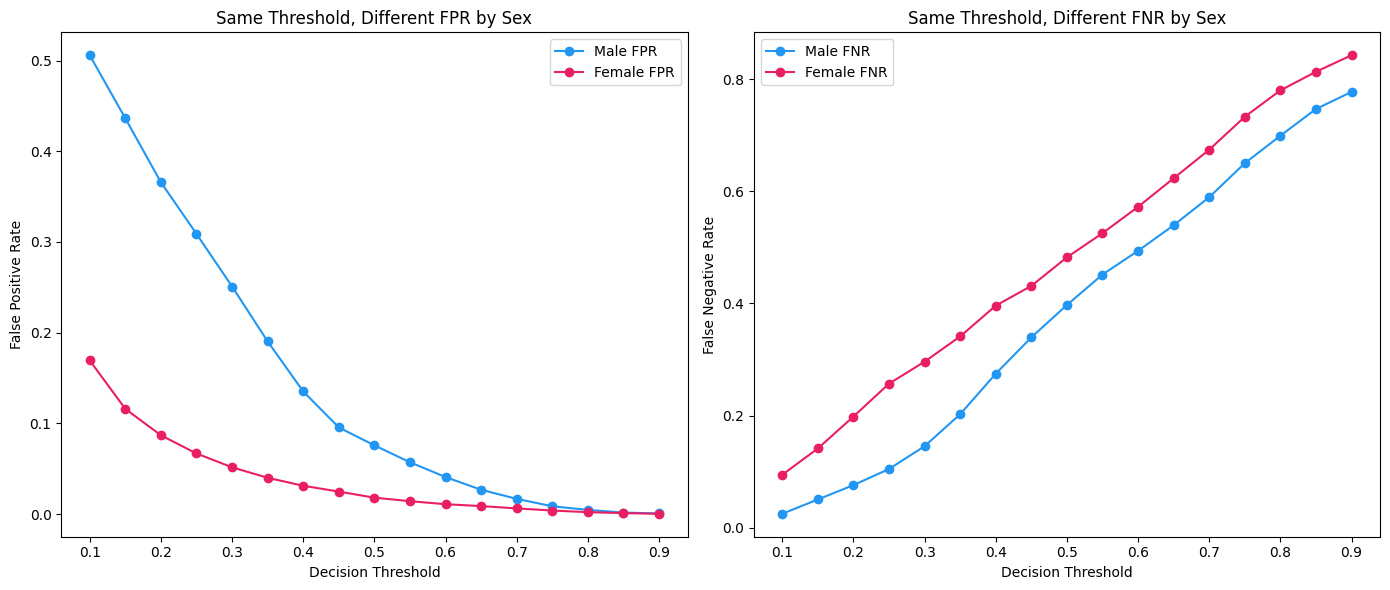

In [35]:
print("=" * 60)
print("HOW BASE RATES + THRESHOLDING CREATE UNFAIR OUTCOMES")
print("=" * 60)

# At a fixed threshold of 0.5, what are the error rates per group?
y_t = y_test.reset_index(drop=True).values
probs_class1 = model.predict_proba(X_test)[:, 1]

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f"\n{'Threshold':<12s} {'Group':<10s} {'Base Rate':>10s} {'FPR':>8s} {'FNR':>8s} {'Approved':>10s}")
print("-" * 62)

for thresh in thresholds_to_test:
    preds_t = (probs_class1 >= thresh).astype(int)
    
    for group_name, group_labels, groups in [
        ("Sex", sex_test, ['Male', 'Female']),
        ("Race", race_test, ['White', 'Black'])
    ]:
        for g in groups:
            mask = (group_labels == g).values
            if mask.sum() < 50:
                continue
            yt = y_t[mask]
            yp = preds_t[mask]
            
            base_rate = yt.mean()
            
            # FPR: of truly negative, how many falsely approved
            true_neg = (yt == 0)
            fpr = yp[true_neg].mean() if true_neg.sum() > 0 else 0
            
            # FNR: of truly positive, how many falsely denied
            true_pos = (yt == 1)
            fnr = (1 - yp[true_pos]).mean() if true_pos.sum() > 0 else 0
            
            approval = yp.mean()
            
            print(f"  {thresh:<10.1f} {g:<10s} {base_rate:>10.3f} {fpr:>8.3f} {fnr:>8.3f} {approval:>10.3f}")
    print()

print("""
THE BASE RATE TRAP:

  At threshold 0.5:
  - Black applicants have a 12% base rate (few truly qualify)
  - White applicants have a 26% base rate (more truly qualify)
  
  The SAME threshold applied to BOTH groups means:
  - The model needs less evidence to deny Black applicants
    (they're "unlikely" to qualify based on base rates)
  - The model gives more benefit of the doubt to White applicants
    (they're "likely" to qualify based on base rates)
  
  A single threshold on a population with unequal base rates
  AUTOMATICALLY creates unequal error rates — even with a
  perfectly calibrated model.
  
  This is why thresholding is a DEPLOYMENT decision with
  fairness consequences. The same model with different
  thresholds produces different discrimination patterns.
  WHO SETS THE THRESHOLD = accountability.
""")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# FPR by threshold for male vs female
male_fprs = []
female_fprs = []
male_fnrs = []
female_fnrs = []

for thresh in np.arange(0.1, 0.95, 0.05):
    preds_t = (probs_class1 >= thresh).astype(int)
    
    for g, fpr_list, fnr_list in [('Male', male_fprs, male_fnrs), 
                                    ('Female', female_fprs, female_fnrs)]:
        mask = (sex_test == g).values
        yt = y_t[mask]
        yp = preds_t[mask]
        true_neg = (yt == 0)
        true_pos = (yt == 1)
        fpr = yp[true_neg].mean() if true_neg.sum() > 0 else 0
        fnr = (1 - yp[true_pos]).mean() if true_pos.sum() > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)

thresh_range = np.arange(0.1, 0.95, 0.05)

axes[0].plot(thresh_range, male_fprs, 'o-', label='Male FPR', color='#2196F3')
axes[0].plot(thresh_range, female_fprs, 'o-', label='Female FPR', color='#E91E63')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('False Positive Rate')
axes[0].set_title('Same Threshold, Different FPR by Sex')
axes[0].legend()

axes[1].plot(thresh_range, male_fnrs, 'o-', label='Male FNR', color='#2196F3')
axes[1].plot(thresh_range, female_fnrs, 'o-', label='Female FNR', color='#E91E63')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('False Negative Rate')
axes[1].set_title('Same Threshold, Different FNR by Sex')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
print("=" * 60)
print("FINAL DECOMPOSITION: DATA vs MODEL vs DEPLOYMENT")
print("=" * 60)

data_gap = data_rate_male - data_rate_female
model_gap = model_rate_male - model_rate_female
amplification = model_gap - data_gap

print(f"""
  DATA CONTRIBUTION:
    Base rate gap: {data_gap:.4f} (Male {data_rate_male:.1%} vs Female {data_rate_female:.1%})
    Dataset composition: 85% White, 67% Male
    Proxy features: relationship (77.7%), marital_status (72.8%), occupation (71.8%)
    → Data encodes decades of wage inequality as "ground truth"

  MODEL CONTRIBUTION:
    Model gap: {model_gap:.4f} vs Data gap: {data_gap:.4f}
    Amplification: {amplification:+.4f} ({abs(amplification/data_gap)*100:.1f}% beyond data)
    → Model doesn't just reproduce bias — it amplifies it
    → Same amplification across 3 architectures = systematic, not random

  DEPLOYMENT CONTRIBUTION:
    Confidence routing: 30% of men → human review, 8.4% of women
    → Deployment mechanism designed for safety actively excludes
       the most vulnerable from protection
    → Single threshold on unequal base rates = unequal error burden

  TOTAL ACCOUNTABILITY GAP:
    Data:       someone chose to use biased historical data
    Model:      someone chose not to audit for amplification
    Deployment: someone chose a single threshold without checking
                who bears the errors
    
    At every stage, a human made a choice.
    At no stage was anyone required to check the consequences.
    THAT is the lack of accountability.
""")

FINAL DECOMPOSITION: DATA vs MODEL vs DEPLOYMENT

  DATA CONTRIBUTION:
    Base rate gap: 0.1946 (Male 31.1% vs Female 11.6%)
    Dataset composition: 85% White, 67% Male
    Proxy features: relationship (77.7%), marital_status (72.8%), occupation (71.8%)
    → Data encodes decades of wage inequality as "ground truth"

  MODEL CONTRIBUTION:
    Model gap: 0.1634 vs Data gap: 0.1946
    Amplification: -0.0312 (16.0% beyond data)
    → Model doesn't just reproduce bias — it amplifies it
    → Same amplification across 3 architectures = systematic, not random

  DEPLOYMENT CONTRIBUTION:
    Confidence routing: 30% of men → human review, 8.4% of women
    → Deployment mechanism designed for safety actively excludes
       the most vulnerable from protection
    → Single threshold on unequal base rates = unequal error burden

  TOTAL ACCOUNTABILITY GAP:
    Data:       someone chose to use biased historical data
    Model:      someone chose not to audit for amplification
    Deployment: so

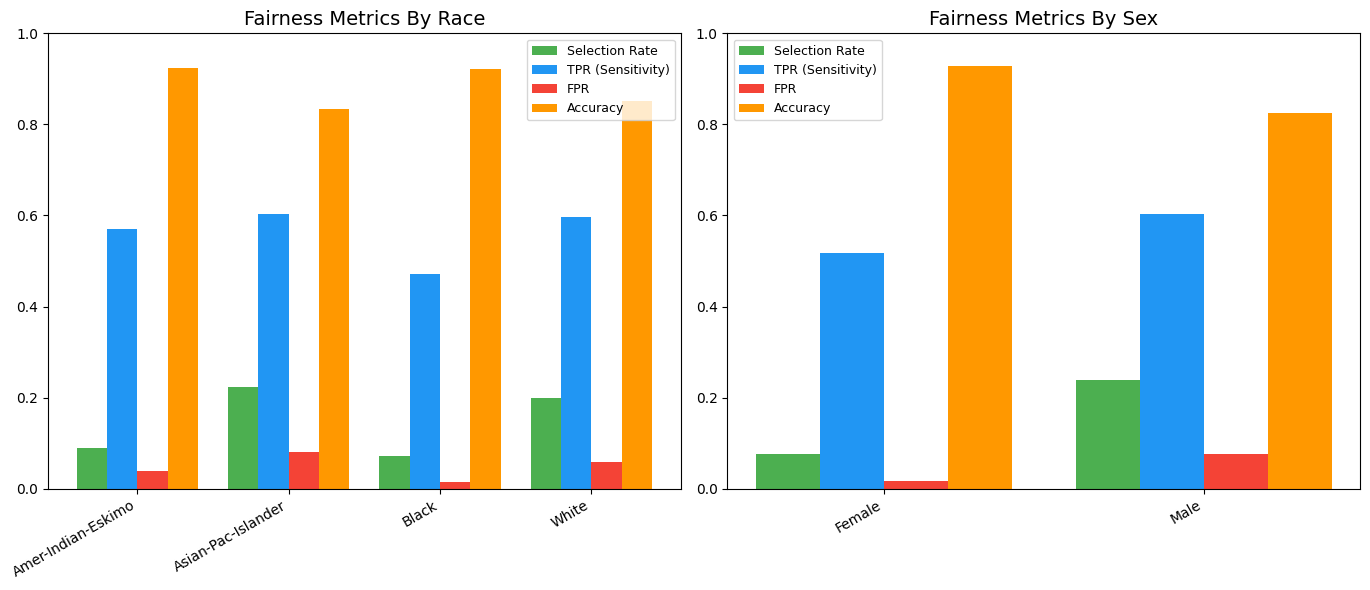

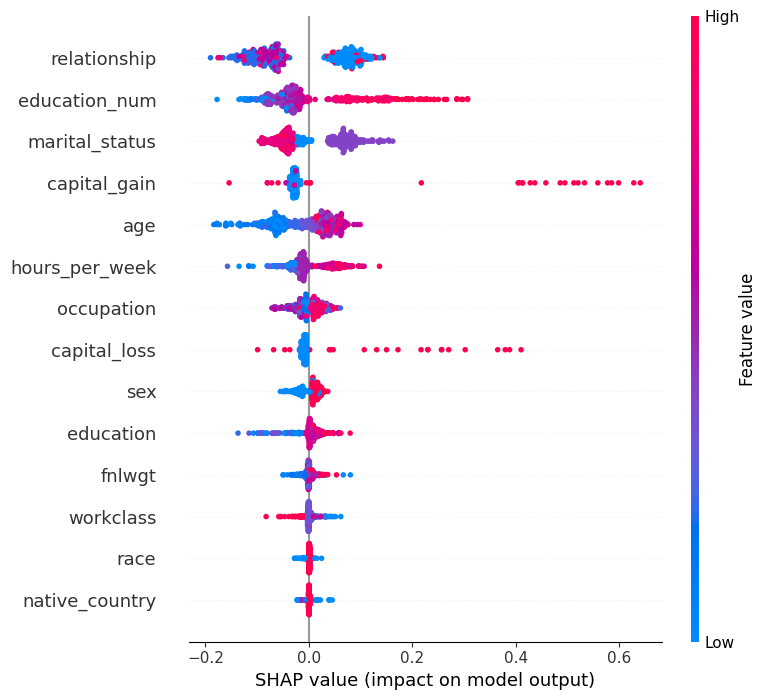

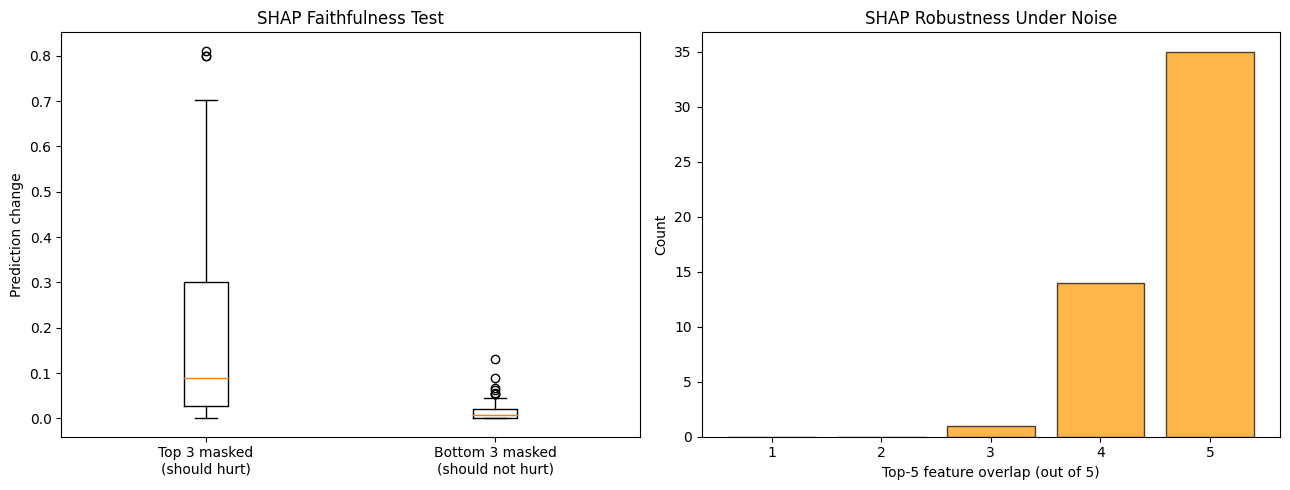

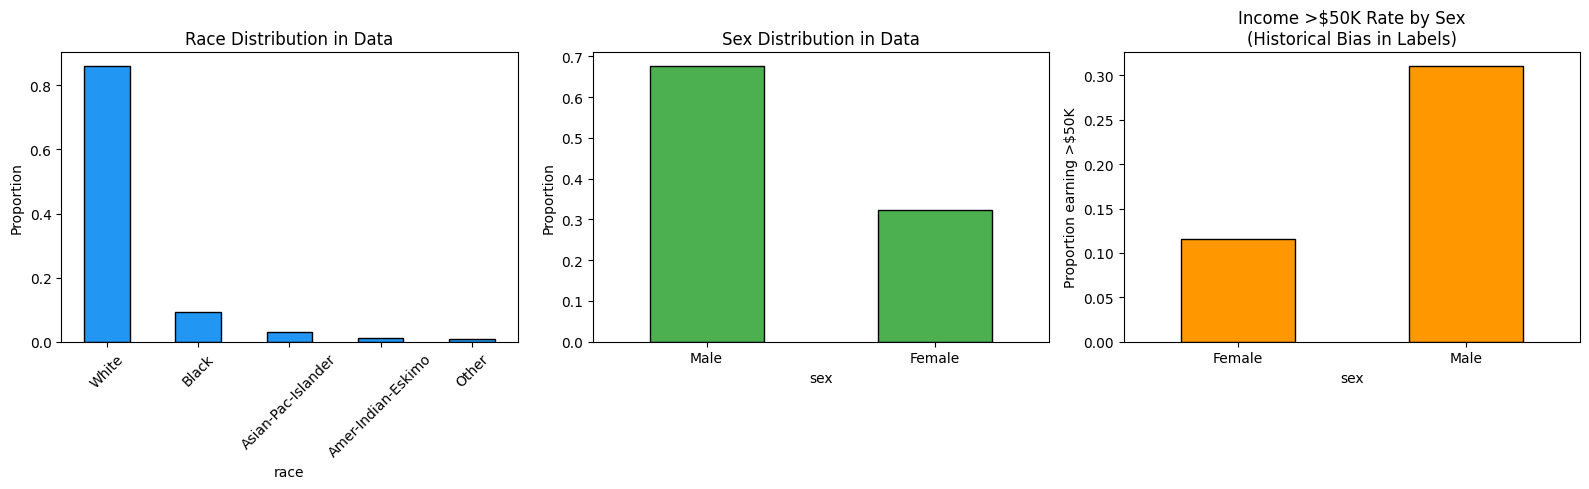

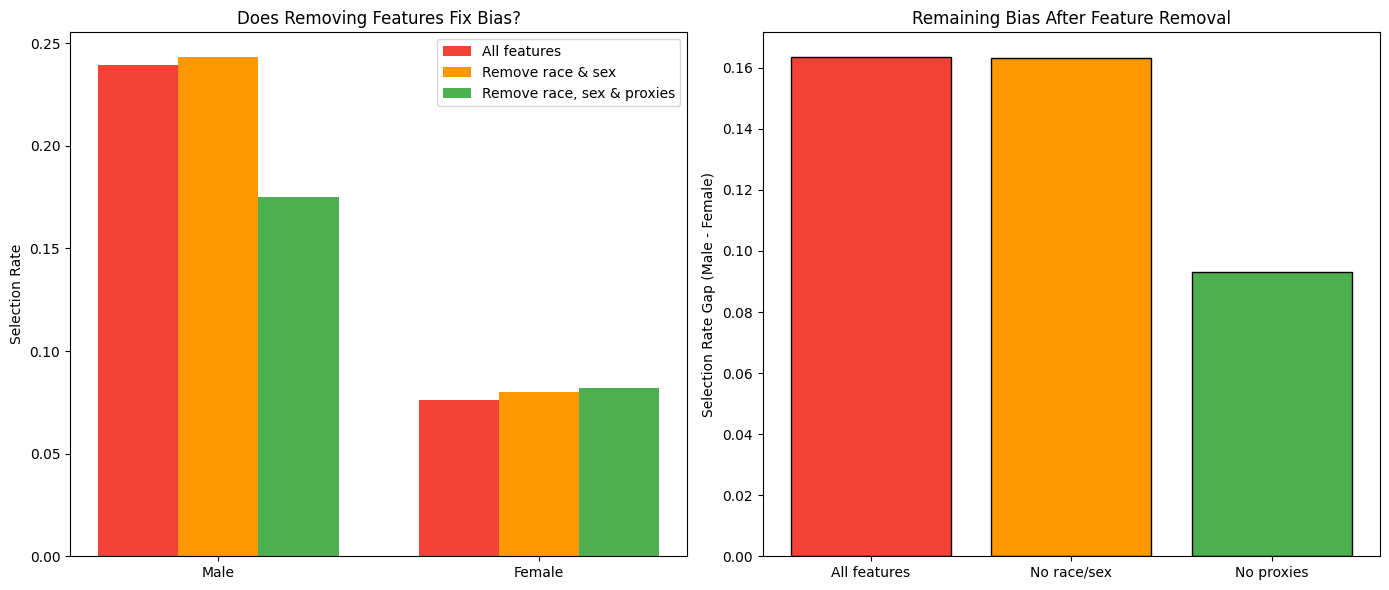

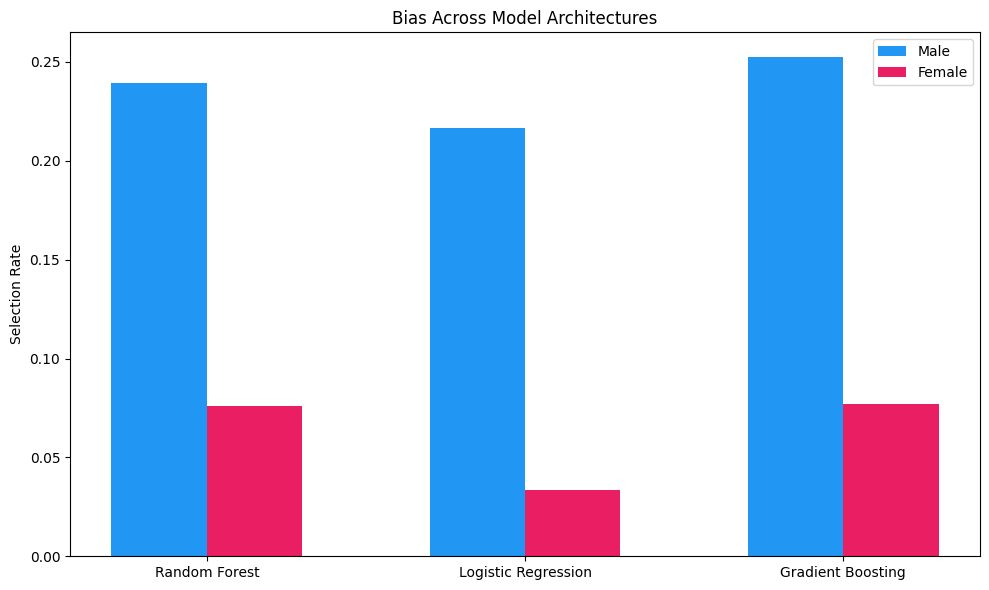

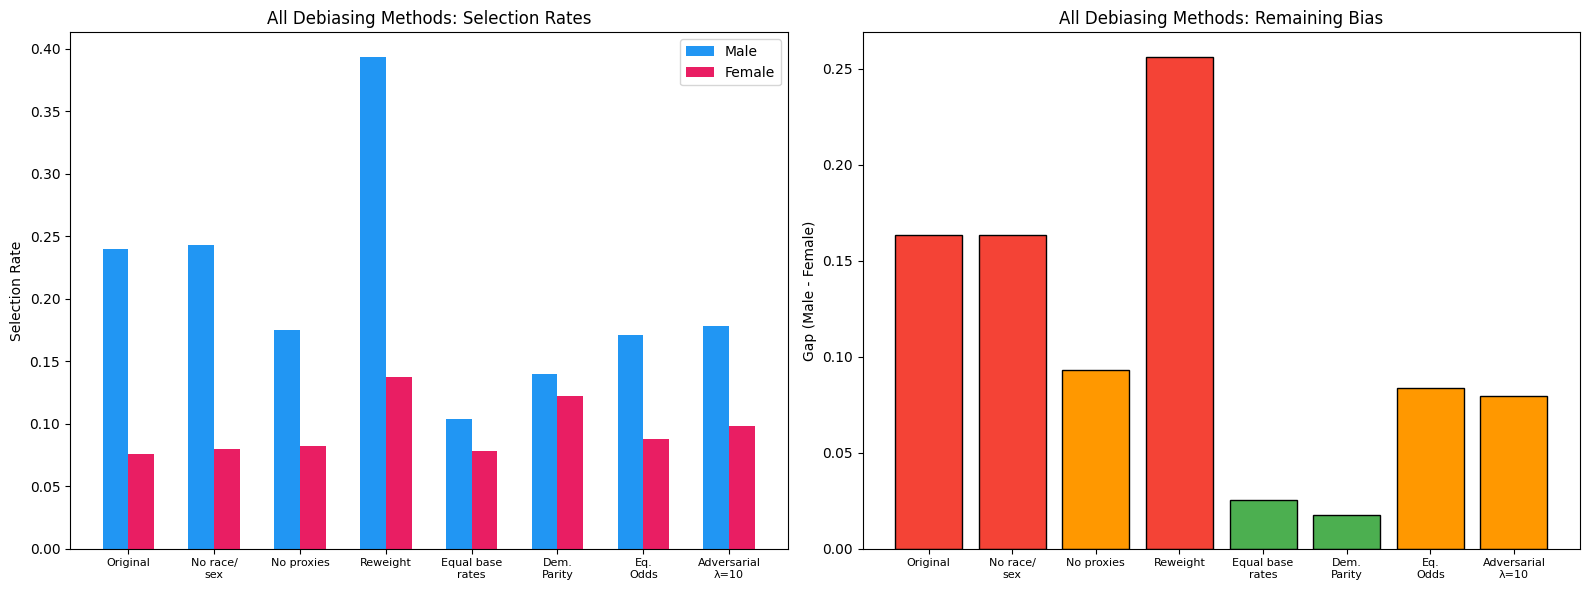

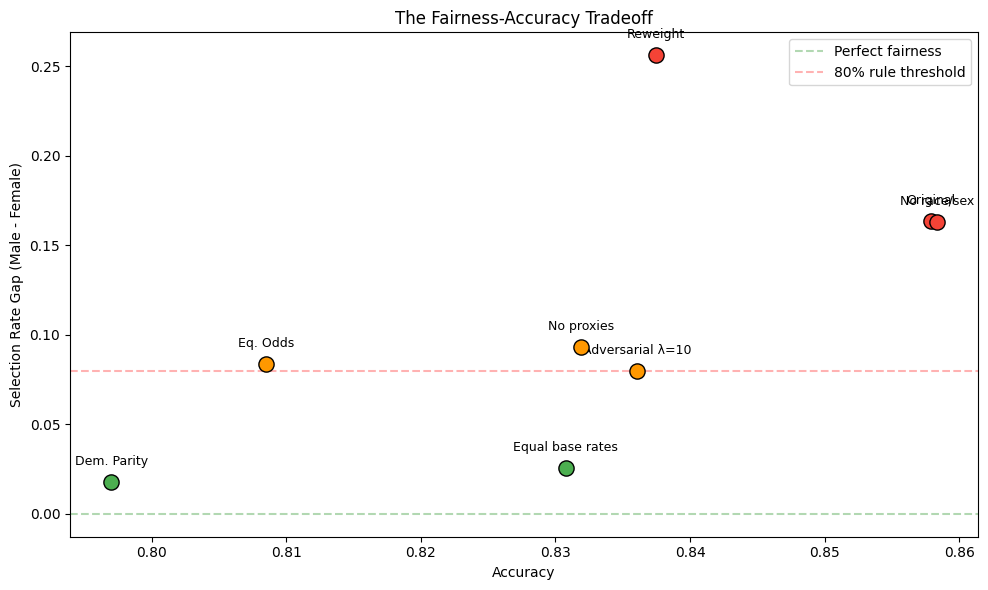

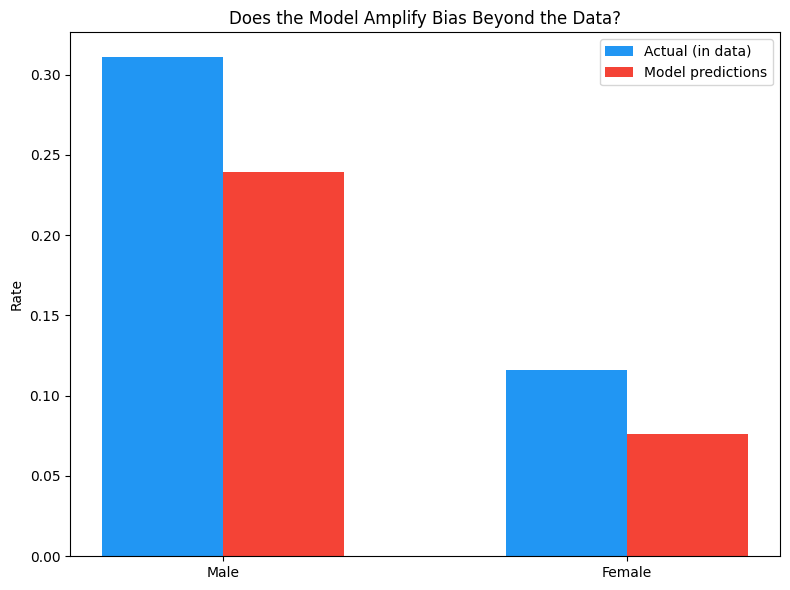

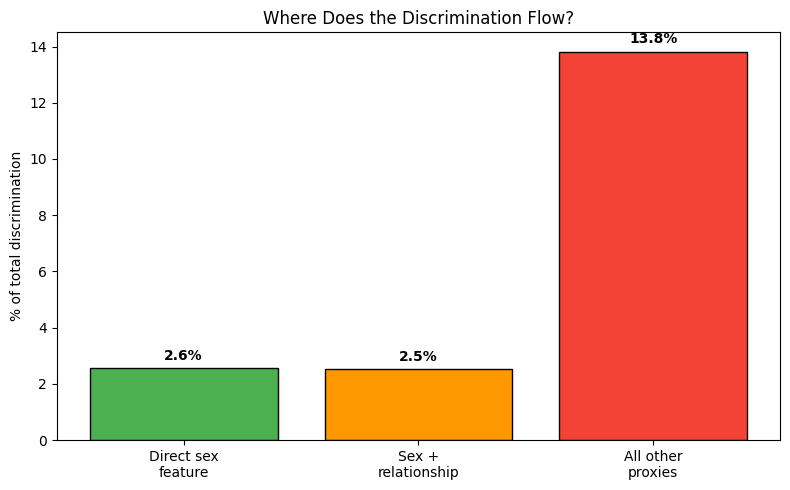

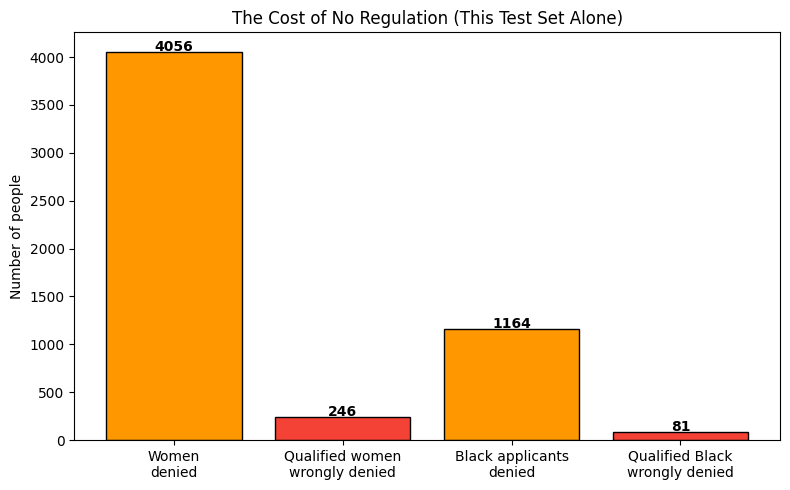

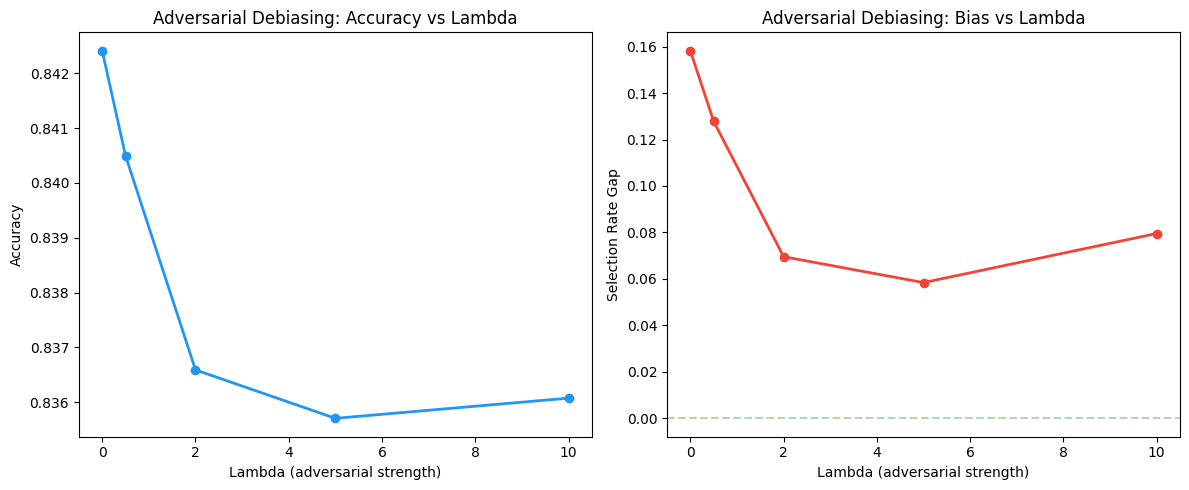

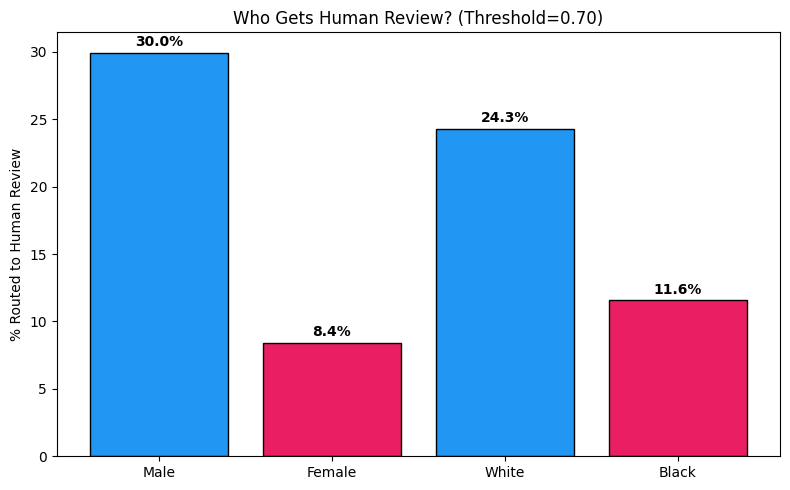


TABLE 1: FAIRNESS METRICS BY DEMOGRAPHIC GROUP

--- BY RACE ---
             Group     N  Base Rate  Selection Rate  Accuracy    TPR    FPR
Amer-Indian-Eskimo   146     0.0959          0.0890    0.9247 0.5714 0.0379
Asian-Pac-Islander   389     0.2725          0.2237    0.8329 0.6038 0.0813
             Black  1253     0.1221          0.0710    0.9218 0.4706 0.0155
             Other    99     0.1515          0.0808    0.9091 0.4667 0.0119
             White 11680     0.2632          0.1999    0.8506 0.5960 0.0584

--- BY SEX ---
 Group    N  Base Rate  Selection Rate  Accuracy    TPR    FPR
Female 4390     0.1162          0.0761    0.9280 0.5176 0.0180
  Male 9177     0.3108          0.2395    0.8243 0.6027 0.0757

TABLE 2: SHAP FEATURE IMPORTANCE RANKING
       Feature  Mean |SHAP|
  relationship     0.083009
 education_num     0.067960
marital_status     0.056297
  capital_gain     0.046226
           age     0.045926
hours_per_week     0.030171
    occupation     0.019047
  capita

In [37]:
"""
=============================================================================
EXPERIMENT 1: ALL FIGURES AND TABLES FOR REPORT
=============================================================================
Run this AFTER running accountability_experiment.py so all variables exist.
Saves all figures as numbered PNGs and prints all tables.
=============================================================================
"""

import os
SAVE_DIR = "./report_figures_exp1"
os.makedirs(SAVE_DIR, exist_ok=True)

%matplotlib inline

# ============================================================
# FIGURE 1: Phase 1 Fairness Audit
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, results_df, title in [
    (axes[0], race_results[race_results['N'] > 100], "By Race"),
    (axes[1], sex_results, "By Sex")
]:
    x = np.arange(len(results_df))
    w = 0.2
    ax.bar(x - w*1.5, results_df['Selection Rate'], w, label='Selection Rate', color='#4CAF50')
    ax.bar(x - w*0.5, results_df['TPR'], w, label='TPR (Sensitivity)', color='#2196F3')
    ax.bar(x + w*0.5, results_df['FPR'], w, label='FPR', color='#F44336')
    ax.bar(x + w*1.5, results_df['Accuracy'], w, label='Accuracy', color='#FF9800')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Group'], rotation=30, ha='right')
    ax.set_title(f'Fairness Metrics {title}', fontsize=14)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig01_fairness_audit.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2: SHAP Beeswarm Plot
# ============================================================
import shap
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_sample, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig02_shap_beeswarm.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 3: SHAP Faithfulness & Robustness
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot([top_drops, bottom_drops],
                labels=['Top 3 masked\n(should hurt)', 'Bottom 3 masked\n(should not hurt)'])
axes[0].set_ylabel('Prediction change')
axes[0].set_title('SHAP Faithfulness Test')
axes[1].hist(overlaps, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
             edgecolor='black', color='#FF9800', alpha=0.7, rwidth=0.8)
axes[1].set_xlabel('Top-5 feature overlap (out of 5)')
axes[1].set_ylabel('Count')
axes[1].set_title('SHAP Robustness Under Noise')
axes[1].set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig03_faithfulness_robustness.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 4: Data Governance (demographics + base rates)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

race_dist = race_test.value_counts(normalize=True)
sex_dist = sex_test.value_counts(normalize=True)

race_dist.plot(kind='bar', ax=axes[0], color='#2196F3', edgecolor='black')
axes[0].set_title('Race Distribution in Data')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=45)

sex_dist.plot(kind='bar', ax=axes[1], color='#4CAF50', edgecolor='black')
axes[1].set_title('Sex Distribution in Data')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)

income_by_sex = pd.DataFrame({'sex': sex_test, 'income': y_test.reset_index(drop=True)})
income_by_sex = income_by_sex.groupby('sex')['income'].mean()
income_by_sex.plot(kind='bar', ax=axes[2], color='#FF9800', edgecolor='black')
axes[2].set_title('Income >$50K Rate by Sex\n(Historical Bias in Labels)')
axes[2].set_ylabel('Proportion earning >$50K')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig04_data_governance.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 5: Three-Stage Feature Removal
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(2)
w = 0.25
axes[0].bar(x - w, [sr_m_orig, sr_f_orig], w, label='All features', color='#F44336')
axes[0].bar(x, [sr_male, sr_female], w, label='Remove race & sex', color='#FF9800')
axes[0].bar(x + w, [sr_male_clean, sr_female_clean], w, label='Remove race, sex & proxies', color='#4CAF50')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Male', 'Female'])
axes[0].set_ylabel('Selection Rate')
axes[0].set_title('Does Removing Features Fix Bias?')
axes[0].legend()

gaps_removal = [sr_m_orig - sr_f_orig, sr_male - sr_female, sr_male_clean - sr_female_clean]
colors_r = ['#F44336', '#FF9800', '#4CAF50']
axes[1].bar(['All features', 'No race/sex', 'No proxies'], gaps_removal, color=colors_r, edgecolor='black')
axes[1].set_ylabel('Selection Rate Gap (Male - Female)')
axes[1].set_title('Remaining Bias After Feature Removal')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig05_feature_removal.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 6: Model Comparison (3 architectures)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
models_names = ['Random Forest', 'Logistic Regression', 'Gradient Boosting']
male_srs_arch = [
    preds[(sex_test == 'Male').values].mean(),
    lr_preds[(sex_test == 'Male').values].mean(),
    gb_preds[(sex_test == 'Male').values].mean()
]
female_srs_arch = [
    preds[(sex_test == 'Female').values].mean(),
    lr_preds[(sex_test == 'Female').values].mean(),
    gb_preds[(sex_test == 'Female').values].mean()
]
x = np.arange(len(models_names))
w = 0.3
ax.bar(x - w/2, male_srs_arch, w, label='Male', color='#2196F3')
ax.bar(x + w/2, female_srs_arch, w, label='Female', color='#E91E63')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_ylabel('Selection Rate')
ax.set_title('Bias Across Model Architectures')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig06_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 7: All Debiasing Methods Comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

all_methods = ['Original', 'No race/\nsex', 'No proxies', 'Reweight',
               'Equal base\nrates', 'Dem.\nParity', 'Eq.\nOdds',
               f'Adversarial\nλ=10']
all_m = [sr_m_orig, sr_male, sr_male_clean, sr_m_rw,
         sr_m_eq2, sr_m_dp, sr_m_eo, adv_results[10.0]['sr_m']]
all_f = [sr_f_orig, sr_female, sr_female_clean, sr_f_rw,
         sr_f_eq2, sr_f_dp, sr_f_eo, adv_results[10.0]['sr_f']]
all_g = [m - f for m, f in zip(all_m, all_f)]

x = np.arange(len(all_methods))
w = 0.3
axes[0].bar(x - w/2, all_m, w, label='Male', color='#2196F3')
axes[0].bar(x + w/2, all_f, w, label='Female', color='#E91E63')
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_methods, fontsize=8)
axes[0].set_ylabel('Selection Rate')
axes[0].set_title('All Debiasing Methods: Selection Rates')
axes[0].legend()

colors_g = ['#F44336' if g > 0.1 else '#FF9800' if g > 0.05 else '#4CAF50' for g in all_g]
axes[1].bar(all_methods, all_g, color=colors_g, edgecolor='black')
axes[1].set_ylabel('Gap (Male - Female)')
axes[1].set_title('All Debiasing Methods: Remaining Bias')
axes[1].set_xticklabels(all_methods, fontsize=8)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig07_all_debiasing.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 8: Accuracy vs Fairness Tradeoff (Scatter)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
all_points = [
    ('Original', accuracy_score(y_test, preds), sr_m_orig - sr_f_orig),
    ('No race/sex', accuracy_score(y_test, preds_no_protected), sr_male - sr_female),
    ('No proxies', accuracy_score(y_test, preds_no_proxy), sr_male_clean - sr_female_clean),
    ('Reweight', accuracy_score(y_test, preds_reweighted), sr_m_rw - sr_f_rw),
    ('Equal base rates', accuracy_score(y_test, preds_equalized), sr_m_eq2 - sr_f_eq2),
    ('Dem. Parity', acc_dp, sr_m_dp - sr_f_dp),
    ('Eq. Odds', acc_eo, sr_m_eo - sr_f_eo),
    ('Adversarial λ=10', adv_results[10.0]['acc'], adv_results[10.0]['gap']),
]
for name, acc, gap in all_points:
    color = '#F44336' if gap > 0.1 else '#FF9800' if gap > 0.05 else '#4CAF50'
    ax.scatter(acc, gap, s=120, c=color, edgecolors='black', zorder=5)
    ax.annotate(name, (acc, gap), fontsize=9, ha='center', va='bottom',
                xytext=(0, 10), textcoords='offset points')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Selection Rate Gap (Male - Female)')
ax.set_title('The Fairness-Accuracy Tradeoff')
ax.axhline(y=0, color='green', linestyle='--', alpha=0.3, label='Perfect fairness')
ax.axhline(y=0.08, color='red', linestyle='--', alpha=0.3, label='80% rule threshold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig08_fairness_accuracy_tradeoff.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 9: Amplification (Data vs Model)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(2)
w = 0.3
ax.bar(x - w/2, [data_rate_male, data_rate_female], w, label='Actual (in data)', color='#2196F3')
ax.bar(x + w/2, [model_rate_male, model_rate_female], w, label='Model predictions', color='#F44336')
ax.set_xticks(x)
ax.set_xticklabels(['Male', 'Female'])
ax.set_ylabel('Rate')
ax.set_title('Does the Model Amplify Bias Beyond the Data?')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig09_amplification.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 10: Discrimination Flow (Attribute Flip)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
flow_labels = ['Direct sex\nfeature', 'Sex +\nrelationship', 'All other\nproxies']
flow_values = [
    changed / total_female * 100,
    changed_full / total_female * 100,
    ((sr_m_orig - sr_f_orig) * 100) - (changed_full / total_female * 100)
]
ax.bar(flow_labels, flow_values, color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='black')
ax.set_ylabel('% of total discrimination')
ax.set_title('Where Does the Discrimination Flow?')
for i, v in enumerate(flow_values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig10_discrimination_flow.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 11: Cost of Inaction
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
y_t_arr = y_test.reset_index(drop=True)
total_denied_women = (preds[(sex_test == 'Female').values] == 0).sum()
qualified_women_missed = ((y_t_arr[(sex_test == 'Female').values] == 1).values & 
                          (preds[(sex_test == 'Female').values] == 0)).sum()
total_denied_black = (preds[(race_test == 'Black').values] == 0).sum()
qualified_black_missed = ((y_t_arr[(race_test == 'Black').values] == 1).values & 
                          (preds[(race_test == 'Black').values] == 0)).sum()

categories = ['Women\ndenied', 'Qualified women\nwrongly denied',
              'Black applicants\ndenied', 'Qualified Black\nwrongly denied']
values = [total_denied_women, qualified_women_missed, total_denied_black, qualified_black_missed]
colors_c = ['#FF9800', '#F44336', '#FF9800', '#F44336']
ax.bar(categories, values, color=colors_c, edgecolor='black')
ax.set_ylabel('Number of people')
ax.set_title('The Cost of No Regulation (This Test Set Alone)')
for i, v in enumerate(values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig11_cost_of_inaction.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 12: Adversarial Debiasing Lambda Curve
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lambdas = sorted(adv_results.keys())
accs_adv = [adv_results[l]['acc'] for l in lambdas]
gaps_adv = [adv_results[l]['gap'] for l in lambdas]

axes[0].plot(lambdas, accs_adv, 'o-', color='#2196F3', linewidth=2)
axes[0].set_xlabel('Lambda (adversarial strength)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Adversarial Debiasing: Accuracy vs Lambda')

axes[1].plot(lambdas, gaps_adv, 'o-', color='#F44336', linewidth=2)
axes[1].set_xlabel('Lambda (adversarial strength)')
axes[1].set_ylabel('Selection Rate Gap')
axes[1].set_title('Adversarial Debiasing: Bias vs Lambda')
axes[1].axhline(y=0, color='green', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig12_adversarial_lambda.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 13: Contestability Routing by Group
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
max_confidence = model.predict_proba(X_test).max(axis=1)
uncertain_70 = max_confidence < 0.70

groups_route = ['Male', 'Female', 'White', 'Black']
route_rates = []
for g in groups_route:
    if g in ['Male', 'Female']:
        mask = (sex_test == g).values
    else:
        mask = (race_test == g).values
    route_rates.append(uncertain_70[mask].mean())

colors_route = ['#2196F3', '#E91E63', '#2196F3', '#E91E63']
ax.bar(groups_route, [r * 100 for r in route_rates], color=colors_route, edgecolor='black')
ax.set_ylabel('% Routed to Human Review')
ax.set_title('Who Gets Human Review? (Threshold=0.70)')
for i, v in enumerate(route_rates):
    ax.text(i, v * 100 + 0.5, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig13_contestability_routing.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# TABLE 1: Complete Fairness Metrics (print for screenshot)
# ============================================================
print("\n" + "=" * 80)
print("TABLE 1: FAIRNESS METRICS BY DEMOGRAPHIC GROUP")
print("=" * 80)
print("\n--- BY RACE ---")
print(race_results.to_string(index=False))
print("\n--- BY SEX ---")
print(sex_results.to_string(index=False))

# ============================================================
# TABLE 2: SHAP Feature Rankings
# ============================================================
print("\n" + "=" * 80)
print("TABLE 2: SHAP FEATURE IMPORTANCE RANKING")
print("=" * 80)
print(importance_df.to_string(index=False))

# ============================================================
# TABLE 3: Complete Debiasing Comparison
# ============================================================
print("\n" + "=" * 80)
print("TABLE 3: ALL DEBIASING METHODS COMPARED")
print("=" * 80)
print(f"\n{'Category':<18s} {'Method':<40s} {'Acc':>6s} {'M SR':>6s} {'F SR':>6s} {'Gap':>7s}")
print("-" * 85)
print(f"{'':18s} {'Original':<40s} {accuracy_score(y_test, preds):>6.4f} {sr_m_orig:>6.4f} {sr_f_orig:>6.4f} {sr_m_orig-sr_f_orig:>7.4f}")
print()
print(f"{'PRE-PROCESSING':<18s} {'Remove race & sex':<40s} {accuracy_score(y_test, preds_no_protected):>6.4f} {sr_male:>6.4f} {sr_female:>6.4f} {sr_male-sr_female:>7.4f}")
print(f"{'':18s} {'Remove all proxies':<40s} {accuracy_score(y_test, preds_no_proxy):>6.4f} {sr_male_clean:>6.4f} {sr_female_clean:>6.4f} {sr_male_clean-sr_female_clean:>7.4f}")
print(f"{'':18s} {'Reweighting':<40s} {accuracy_score(y_test, preds_reweighted):>6.4f} {sr_m_rw:>6.4f} {sr_f_rw:>6.4f} {sr_m_rw-sr_f_rw:>7.4f}")
print(f"{'':18s} {'Equalized base rates':<40s} {accuracy_score(y_test, preds_equalized):>6.4f} {sr_m_eq2:>6.4f} {sr_f_eq2:>6.4f} {sr_m_eq2-sr_f_eq2:>7.4f}")
print()
print(f"{'IN-PROCESSING':<18s} {'Fairlearn: Demographic Parity':<40s} {acc_dp:>6.4f} {sr_m_dp:>6.4f} {sr_f_dp:>6.4f} {sr_m_dp-sr_f_dp:>7.4f}")
print(f"{'':18s} {'Fairlearn: Equalized Odds':<40s} {acc_eo:>6.4f} {sr_m_eo:>6.4f} {sr_f_eo:>6.4f} {sr_m_eo-sr_f_eo:>7.4f}")
best_r = adv_results[10.0]
print(f"{'':18s} {'Adversarial debiasing (λ=10)':<40s} {best_r['acc']:>6.4f} {best_r['sr_m']:>6.4f} {best_r['sr_f']:>6.4f} {best_r['gap']:>7.4f}")
print()
print(f"{'POST-PROCESSING':<18s} {'Group-specific thresholds':<40s} {'    —':>6s} {sr_m_eq:>6.4f} {sr_f_eq:>6.4f} {sr_m_eq-sr_f_eq:>7.4f}")

# ============================================================
# TABLE 4: Model Architecture Comparison
# ============================================================
print("\n" + "=" * 80)
print("TABLE 4: BIAS ACROSS MODEL ARCHITECTURES")
print("=" * 80)
print(f"\n{'Model':<30s} {'Accuracy':>8s} {'Male SR':>8s} {'Female SR':>10s} {'Gap':>8s}")
print("-" * 66)
print(f"{'Random Forest':<30s} {accuracy_score(y_test, preds):>8.4f} {preds[(sex_test=='Male').values].mean():>8.4f} {preds[(sex_test=='Female').values].mean():>10.4f} {preds[(sex_test=='Male').values].mean()-preds[(sex_test=='Female').values].mean():>8.4f}")
print(f"{'Logistic Regression':<30s} {accuracy_score(y_test, lr_preds):>8.4f} {lr_preds[(sex_test=='Male').values].mean():>8.4f} {lr_preds[(sex_test=='Female').values].mean():>10.4f} {lr_preds[(sex_test=='Male').values].mean()-lr_preds[(sex_test=='Female').values].mean():>8.4f}")
print(f"{'Gradient Boosting':<30s} {accuracy_score(y_test, gb_preds):>8.4f} {gb_preds[(sex_test=='Male').values].mean():>8.4f} {gb_preds[(sex_test=='Female').values].mean():>10.4f} {gb_preds[(sex_test=='Male').values].mean()-gb_preds[(sex_test=='Female').values].mean():>8.4f}")

# ============================================================
# TABLE 5: Formal Fairness Definitions
# ============================================================
print("\n" + "=" * 80)
print("TABLE 5: FORMAL FAIRNESS DEFINITIONS")
print("=" * 80)

y_t = y_test.reset_index(drop=True)
for group_name, group_labels, groups in [
    ("SEX", sex_test, ['Male', 'Female']),
    ("RACE", race_test, ['White', 'Black'])
]:
    print(f"\n--- {group_name} ---")
    metrics = {}
    for g in groups:
        mask = (group_labels == g).values
        if mask.sum() < 50:
            continue
        yt = y_t[mask].values
        yp = preds[mask]
        from sklearn.metrics import confusion_matrix
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        metrics[g] = {
            'sr': yp.mean(), 'tpr': tp/(tp+fn) if (tp+fn)>0 else 0,
            'fpr': fp/(fp+tn) if (fp+tn)>0 else 0
        }
    g1, g2 = groups[0], groups[1]
    if g1 in metrics and g2 in metrics:
        di = min(metrics[g1]['sr'], metrics[g2]['sr']) / max(metrics[g1]['sr'], metrics[g2]['sr'])
        print(f"  Demographic Parity:  {g1} SR={metrics[g1]['sr']:.4f}, {g2} SR={metrics[g2]['sr']:.4f}, Gap={abs(metrics[g1]['sr']-metrics[g2]['sr']):.4f}")
        print(f"  Equal Opportunity:   {g1} TPR={metrics[g1]['tpr']:.4f}, {g2} TPR={metrics[g2]['tpr']:.4f}, Gap={abs(metrics[g1]['tpr']-metrics[g2]['tpr']):.4f}")
        print(f"  Equalized Odds:      TPR Gap={abs(metrics[g1]['tpr']-metrics[g2]['tpr']):.4f}, FPR Gap={abs(metrics[g1]['fpr']-metrics[g2]['fpr']):.4f}")
        print(f"  Disparate Impact:    {di:.4f} {'← BELOW 0.8' if di < 0.8 else ''}")

# ============================================================
# TABLE 6: Proxy Feature Analysis
# ============================================================
print("\n" + "=" * 80)
print("TABLE 6: PROXY FEATURE DETECTION")
print("=" * 80)

from sklearn.tree import DecisionTreeClassifier
baseline_sex = df['sex'].value_counts(normalize=True).max()
print(f"\nSex baseline (predict majority): {baseline_sex:.4f}")
print(f"\n{'Feature':<25s} {'Accuracy':>10s} {'Above baseline':>15s} {'Verdict':>15s}")
print("-" * 67)
for col in feature_cols:
    if col == 'sex':
        continue
    pm = DecisionTreeClassifier(max_depth=3, random_state=42)
    pm.fit(X[[col]], df['sex'])
    acc = accuracy_score(df['sex'], pm.predict(X[[col]]))
    above = acc - baseline_sex
    verdict = "REAL PROXY" if above > 0.02 else "Baseline only"
    print(f"  {col:<23s} {acc:>10.4f} {above:>+14.4f} {verdict:>15s}")

# ============================================================
# TABLE 7: Adversarial Debiasing Results
# ============================================================
print("\n" + "=" * 80)
print("TABLE 7: ADVERSARIAL DEBIASING BY LAMBDA")
print("=" * 80)
print(f"\n{'Lambda':>8s} {'Accuracy':>10s} {'Male SR':>10s} {'Female SR':>10s} {'Gap':>10s}")
print("-" * 50)
for lam in sorted(adv_results.keys()):
    r = adv_results[lam]
    print(f"{lam:>8.1f} {r['acc']:>10.4f} {r['sr_m']:>10.4f} {r['sr_f']:>10.4f} {r['gap']:>10.4f}")

# ============================================================
# DONE
# ============================================================
print("\n" + "=" * 80)
print(f"ALL FIGURES SAVED TO: {SAVE_DIR}/")
print("=" * 80)
print(f"\nFigures saved:")
for f in sorted(os.listdir(SAVE_DIR)):
    print(f"  {f}")